<a href="https://colab.research.google.com/github/gabrielniculaesei/lendingclub-dataset/blob/colab/FAD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisi del Rischio Creditizio - Dataset LendingClub


Il dataset proviene da LendingClub, una piattaforma americana di prestiti. Contiene informazioni su migliaia di prestiti erogati: le caratteristiche dei richiedenti, le condizioni applicate e, soprattutto, se il prestito è stato ripagato o meno.

Il nostro obiettivo non è semplicemente descrivere i dati, ma interrogarli. Ogni analisi parte da una domanda concreta e cerca una risposta nei numeri.

---

## Indice

### Parte 1 - Preparazione dei Dati
1. [Caricamento del dataset](#caricamento)
2. [Rinomina delle variabili](#rinomina)
3. [Descrizione delle variabili](#descrizione)
4. [Gestione valori mancanti](#valori-mancanti)
5. [Conversione tipi di dato](#conversione)

### Parte 2 - Analisi Esplorativa
6. [Panoramica delle distribuzioni](#distribuzioni-generali)
7. [Sbilanciamento delle classi](#sbilanciamento-classi)
8. [Analisi Interest Rate](#interest-rate-dist)
9. [Analisi Installment](#installment-analisi)
10. [Analisi Credit History](#credit_history_days)
11. [Analisi FICO Score](#fico-score)
12. [Analisi Purpose](#purpose-analisi)
13. [Analisi Annual Income](#annual-income)
14. [Analisi DTI](#dti-analisi)
15. [Analisi Revolving Utilization](#revolving-util)
16. [Analisi Credit Policy](#credit-policy)
17. [Analisi Inquiries](#inquiries)
18. [Analisi Public Records](#public-records)
19. [Analisi Delinquencies](#delinquencies)

### Parte 3 - Verifica Statistica
20. [Test di normalita](#test-normalita)
21. [Confronto tra gruppi (t-test)](#test-t)
22. [Associazioni categoriche (chi-quadrato)](#test-chi2)

### Parte 4 - Analisi Multivariata
23. [Correlazioni e covarianze](#correlazioni)
24. [Regressione lineare](#regressione)
25. [Diagnostica del modello](#diagnostica)

### Parte 5 - Descrizione dei dati
26. [Clustering dei clienti (K-Means)](#clustering)
27. [Riduzione dimensionalita (PCA)](#pca)

### Parte 6 - Modelli Predittivi
28. [Regressione logistica](#logistica)
29. [Valutazione del modello (ROC, Confusion Matrix)](#valutazione)
30. [Strategia di pricing del rischio](#strategia)
31. [Confronto con K-Nearest Neighbors](#knn)
32. [Feature Importance](#feature-importance)
33. [Gaussian Naive Bayes](#naive-bayes)
34. [Confronto finale dei modelli](#confronto-modelli)

### Parte 7 - Conclusioni
35. [Sintesi dei risultati](#conclusioni)

---

## Struttura del notebook

**Parte 1 - Preparazione dei dati**
Prima di analizzare qualsiasi cosa, dobbiamo conoscere i dati: cosa rappresentano, se sono completi, se contengono errori.

**Parte 2 - Analisi esplorativa**
Osserviamo le distribuzioni delle variabili chiave. Ci chiediamo: quali valori sono tipici? Quali sono anomali? Esistono pattern evidenti?

**Parte 3 - Verifica statistica**
Le differenze che osserviamo sono reali o dovute al caso? Applichiamo test statistici per validare le nostre intuizioni.

**Parte 4 - Analisi multivariata**
Le variabili non agiscono in isolamento. Studiamo correlazioni e costruiamo modelli per capire quali fattori influenzano davvero il rischio.

**Parte 5 - Descrizione dei dati**
Segmentiamo i clienti con il clustering e riduciamo la complessità con la PCA.

**Parte 6 - Modello predittivo e strategia**
Costruiamo un modello per prevedere il default e lo traduciamo in una strategia decisionale concreta per la banca. Confrontiamo diversi approcci (Logistic Regression, KNN, Naive Bayes) per trovare la soluzione migliore.

**Parte 7 - Conclusioni**
Sintetizziamo i risultati principali, le implicazioni pratiche e i possibili sviluppi futuri.

<a id="caricamento"></a>
# Parte 1 - Preparazione dei Dati

## Caricamento del Dataset

Iniziamo caricando il dataset e guardando la sua struttura.

In [2]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
url = "https://raw.githubusercontent.com/gabrielniculaesei/lendingclub-dataset/refs/heads/main/loans.csv"
data = pd.read_csv(url)

data.columns

Index(['customer.id', 'credit.policy', 'purpose', 'int.rate', 'installment',
       'log.annual.inc', 'dti', 'fico', 'days.with.cr.line', 'revol.bal',
       'revol.util', 'inq.last.6mths', 'delinq.2yrs', 'pub.rec',
       'not.fully.paid'],
      dtype='object')

<a id="rinomina"></a>
## Rinomina delle Variabili

I nomi originali usano punti e abbreviazioni poco leggibili. Li redominiamo per avere una maggiore leggibilità

In [3]:
new_columns = {
    'customer.id': 'customer_id',
    'credit.policy': 'credit_policy',
    'purpose': 'purpose',
    'int.rate': 'interest_rate',
    'installment': 'installment',
    'log.annual.inc': 'log_annual_income',
    'dti': 'dti',
    'fico': 'fico_score',
    'days.with.cr.line': 'credit_history_days',
    'revol.bal': 'revolving_balance',
    'revol.util': 'revolving_util',
    'inq.last.6mths': 'inquiries_last_6m',
    'delinq.2yrs': 'delinquencies_2y',
    'pub.rec': 'public_records',
    'not.fully.paid': 'not_fully_paid'
}

data = data.rename(columns=new_columns)


print(data.columns.tolist())

print(data[data["credit_policy"]==0])

['customer_id', 'credit_policy', 'purpose', 'interest_rate', 'installment', 'log_annual_income', 'dti', 'fico_score', 'credit_history_days', 'revolving_balance', 'revolving_util', 'inquiries_last_6m', 'delinquencies_2y', 'public_records', 'not_fully_paid']
Empty DataFrame
Columns: [customer_id, credit_policy, purpose, interest_rate, installment, log_annual_income, dti, fico_score, credit_history_days, revolving_balance, revolving_util, inquiries_last_6m, delinquencies_2y, public_records, not_fully_paid]
Index: []


<a id="descrizione"></a>
## Che informazioni abbiamo su ogni cliente?

Prima di analizzare i dati, dobbiamo capire cosa rappresenta ogni variabile. Ecco un dizionario delle colonne:

**Identificazione**
- `customer_id`: codice univoco del cliente

**Profilo creditizio**
- `credit_policy`: indica se il cliente rispetta i criteri di credito della piattaforma (1 = si, 0 = no)
- `fico_score`: punteggio creditizio americano, scala da 300 a 850. E il numero che sintetizza l'affidabilita creditizia di una persona
- `credit_history_days`: anzianità della storia creditizia in giorni
- `delinquencies_2y`: numero di pagamenti in ritardo negli ultimi 2 anni
- `public_records`: eventi negativi pubblici come fallimenti o pignoramenti
- `inquiries_last_6m`: quante volte negli ultimi 6 mesi qualcuno ha richiesto il report creditizio del cliente

**Situazione debitoria**
- `dti` (Debt-to-Income): percentuale del reddito mensile destinata al pagamento di debiti
- `revolving_balance`: saldo attuale su linee di credito rotativo (carte di credito e simili)
- `revolving_util`: percentuale del credito disponibile effettivamente utilizzata
- `not_fully_paid`: 1 = il cliente non ha ripagato completamente, 0 = ha ripagato regolarmente

**Dettagli del prestito**
- `purpose`: motivazione dichiarata del prestito
- `interest_rate`: tasso di interesse applicato
- `installment`: importo della rata mensile

**Reddito**
- `log_annual_income`: logaritmo naturale del reddito annuale


Questa e la variabile che vogliamo prevedere.

In [4]:
data.head(10)

,customer_id,credit_policy,purpose,interest_rate,installment,log_annual_income,dti,fico_score,credit_history_days,revolving_balance,revolving_util,inquiries_last_6m,delinquencies_2y,public_records,not_fully_paid
0,10001,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854.0,52.1,0.0,0,0,0
1,10002,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623.0,76.7,0.0,0,0,0
2,10003,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511.0,25.6,1.0,0,0,0
3,10004,1,debt_consolidation,0.1008,162.34,11.350407,8.1,712,2699.958333,33667.0,73.2,1.0,0,0,0
4,10005,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740.0,39.5,0.0,1,0,0
5,10006,1,credit_card,0.0788,125.13,11.904968,16.98,727,6120.041667,50807.0,51,0.0,0,0,0
6,10007,1,debt_consolidation,0.1496,194.02,10.714418,4,667,3180.041667,3839.0,76.8,0.0,0,1,1
7,10008,1,all_other,0.1114,131.22,11.002100,11.08,722,5116.000000,24220.0,68.6,0.0,0,0,1
8,10009,1,home_improvement,0.1134,87.19,11.407565,17.25,682,3989.000000,69909.0,51.1,1.0,0,0,0
9,10010,1,debt_consolidation,0.1221,84.12,10.203592,10,707,2730.041667,5630.0,23,1.0,0,0,0


In [5]:
print(len(data))

9578


### Una precisazione sui valori zero

Prima di cercare valori mancanti, chiariamo un punto importante: in questo dataset vi sono variabili dove zero non significa "dato mancante". Per esempio:
- `delinquencies_2y = 0` significa che il cliente non ha mai pagato in ritardo negli ultimi 2 anni
- `public_records = 0` significa nessun fallimento o pignoramento

Questi zeri contengono informazione utile e non vanno trattati come dati assenti.

In [6]:
data.loc[30]

customer_id                         10031
credit_policy                           1
purpose                debt_consolidation
interest_rate                      0.0807
installment                        156.84
log_annual_income               11.512925
dti                                   2.3
fico_score                            742
credit_history_days           3148.958333
revolving_balance                  9698.0
revolving_util                       19.4
inquiries_last_6m                     0.0
delinquencies_2y                        0
public_records                          0
not_fully_paid                          0
Name: 30, dtype: object

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          9578 non-null   int64  
 1   credit_policy        9578 non-null   object 
 2   purpose              9578 non-null   object 
 3   interest_rate        9578 non-null   float64
 4   installment          9578 non-null   float64
 5   log_annual_income    9573 non-null   float64
 6   dti                  9578 non-null   object 
 7   fico_score           9578 non-null   int64  
 8   credit_history_days  9549 non-null   float64
 9   revolving_balance    9577 non-null   float64
 10  revolving_util       9516 non-null   object 
 11  inquiries_last_6m    9548 non-null   float64
 12  delinquencies_2y     9549 non-null   object 
 13  public_records       9549 non-null   object 
 14  not_fully_paid       9578 non-null   int64  
dtypes: float64(6), int64(3), object(6)
mem

In [8]:
data.describe()

,customer_id,interest_rate,installment,log_annual_income,fico_score,credit_history_days,revolving_balance,inquiries_last_6m,not_fully_paid
count,9578.000000,9578.000000,9578.000000,9573.000000,9578.000000,9549.000000,9.577000e+03,9548.000000,9578.000000
mean,14789.500000,0.125529,319.089413,10.931892,711.159532,4562.026085,1.691529e+04,1.571743,0.160054
std,2765.074773,0.202225,207.071301,0.614766,42.024737,2497.985733,3.375770e+04,2.198151,0.366676
min,10001.000000,0.060000,15.670000,7.547502,612.000000,178.958333,0.000000e+00,0.000000,0.000000
25%,12395.250000,0.103900,163.770000,10.558414,682.000000,2820.000000,3.187000e+03,0.000000,0.000000
50%,14789.500000,0.122100,268.950000,10.928238,707.000000,4139.958333,8.596000e+03,1.000000,0.000000
75%,17183.750000,0.140700,432.762500,11.289832,737.000000,5730.000000,1.825200e+04,2.000000,0.000000
max,19578.000000,14.700000,940.140000,14.528354,1812.000000,17639.958330,1.207359e+06,33.000000,1.000000


<a id="conversione"></a>
## Conversione dei tipi di dato e valori mancanti

Ci sono valori mancanti? Come li gestiamo? Di che tipo sono?

Con un dataset di questa dimensione possiamo permetterci di eliminare le righe incomplete senza perdere troppa informazione.
Inoltre dopo aver verificato la presenza di valori mancanti, verifichiamo se le variabili hanno coerenza nel tipo di dato

In [9]:

print(f"Valori mancanti per colonna:")
percent_missing = data.isnull().mean() * 100

for col, pct in percent_missing.items():
    print(f"{col}: {pct:.2f}%")

data['credit_policy'] = pd.to_numeric(data['credit_policy'], errors='coerce').astype('Int64')

data['dti'] = pd.to_numeric(data['dti'], errors='coerce')

data['revolving_util'] = pd.to_numeric(data['revolving_util'], errors='coerce')

data['delinquencies_2y'] = pd.to_numeric(data['delinquencies_2y'], errors='coerce').astype('Int64')

data['public_records'] = pd.to_numeric(data['public_records'], errors='coerce').astype('Int64')

Valori mancanti per colonna:
customer_id: 0.00%
credit_policy: 0.00%
purpose: 0.00%
interest_rate: 0.00%
installment: 0.00%
log_annual_income: 0.05%
dti: 0.00%
fico_score: 0.00%
credit_history_days: 0.30%
revolving_balance: 0.01%
revolving_util: 0.65%
inquiries_last_6m: 0.31%
delinquencies_2y: 0.30%
public_records: 0.30%
not_fully_paid: 0.00%


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          9578 non-null   int64  
 1   credit_policy        9576 non-null   Int64  
 2   purpose              9578 non-null   object 
 3   interest_rate        9578 non-null   float64
 4   installment          9578 non-null   float64
 5   log_annual_income    9573 non-null   float64
 6   dti                  9577 non-null   float64
 7   fico_score           9578 non-null   int64  
 8   credit_history_days  9549 non-null   float64
 9   revolving_balance    9577 non-null   float64
 10  revolving_util       9515 non-null   float64
 11  inquiries_last_6m    9548 non-null   float64
 12  delinquencies_2y     9548 non-null   Int64  
 13  public_records       9548 non-null   Int64  
 14  not_fully_paid       9578 non-null   int64  
dtypes: Int64(3), float64(8), int64(3), obj

In [11]:

data = data.dropna()

print(f"Dimensione dataset dopo rimozione NaN: {len(data)} righe")
print(f"\nVerifica valori mancanti per colonna:")
print(data.isnull().sum())
duplicati = data.duplicated().sum()
print(f"\nVerifica duplicati:")
print(f"   Righe duplicate trovate: {duplicati}")

if duplicati > 0:
    print(f"   Rimozione di {duplicati} righe duplicate...")
    data = data.drop_duplicates()
    print(f"   Dimensione dataset dopo rimozione duplicati: {len(data)} righe")
else:
    print("   Nessun duplicato presente nel dataset")

Dimensione dataset dopo rimozione NaN: 9508 righe

Verifica valori mancanti per colonna:
customer_id            0
credit_policy          0
purpose                0
interest_rate          0
installment            0
log_annual_income      0
dti                    0
fico_score             0
credit_history_days    0
revolving_balance      0
revolving_util         0
inquiries_last_6m      0
delinquencies_2y       0
public_records         0
not_fully_paid         0
dtype: int64

Verifica duplicati:
   Righe duplicate trovate: 0
   Nessun duplicato presente nel dataset


<a id="distribuzioni-generali"></a>
# Parte 2 - Analisi Esplorativa

## Come sono distribuiti i dati?

Prima di tutto, dobbiamo conoscere i dati. Guardiamo le distribuzioni per capire:
- Dove si concentrano la maggior parte delle osservazioni
- Se esistono outlier e se sono signigicativi
- La forma delle distribuzioni

Dividiamo le variabili in due gruppi:
- **Continue**: possono assumere qualsiasi valore in un intervallo (interest_rate, installment, dti, fico_score)
- **Discrete**: assumono solo valori interi o categorie limitate (credit_policy, delinquencies_2y, not_fully_paid)

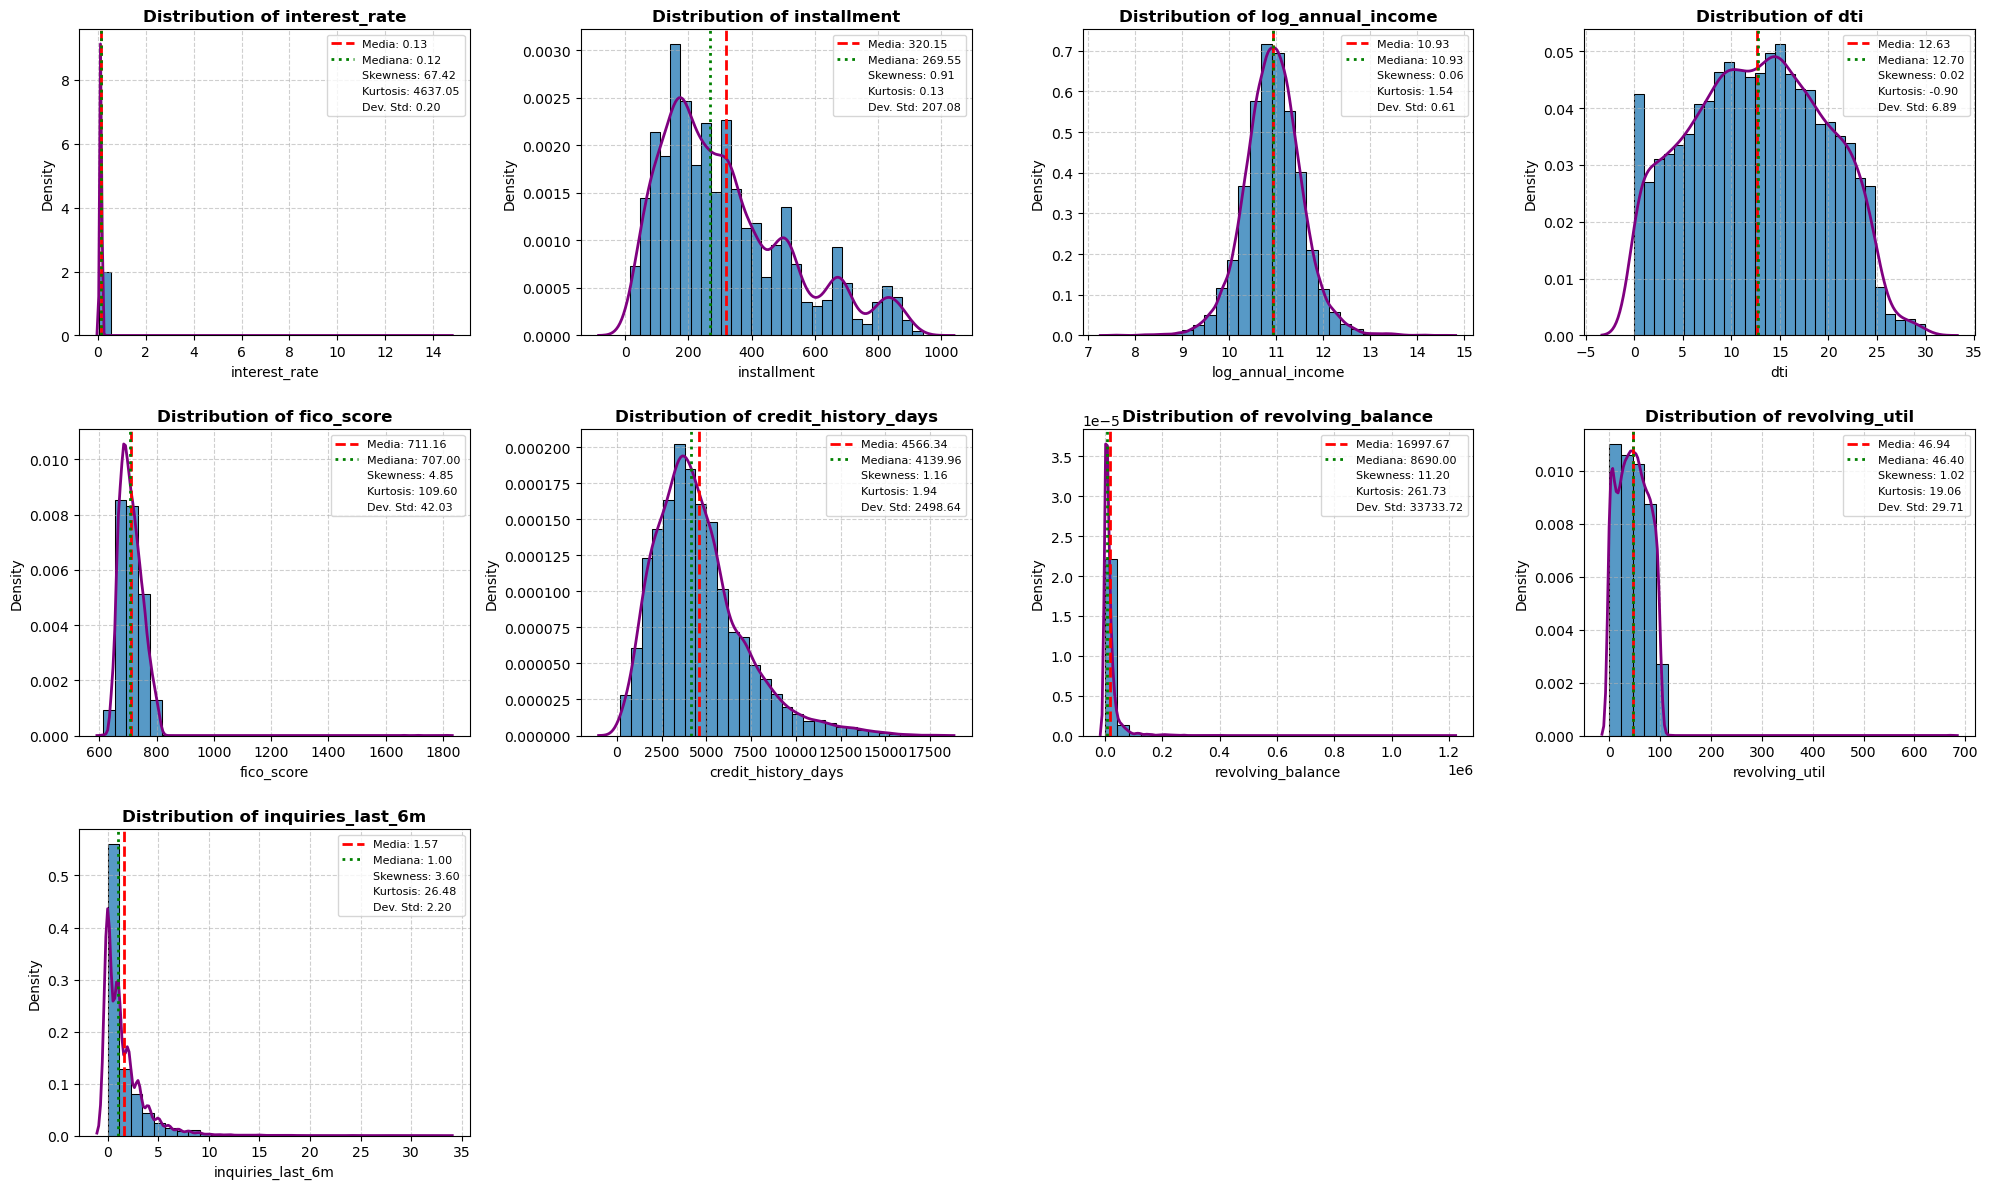

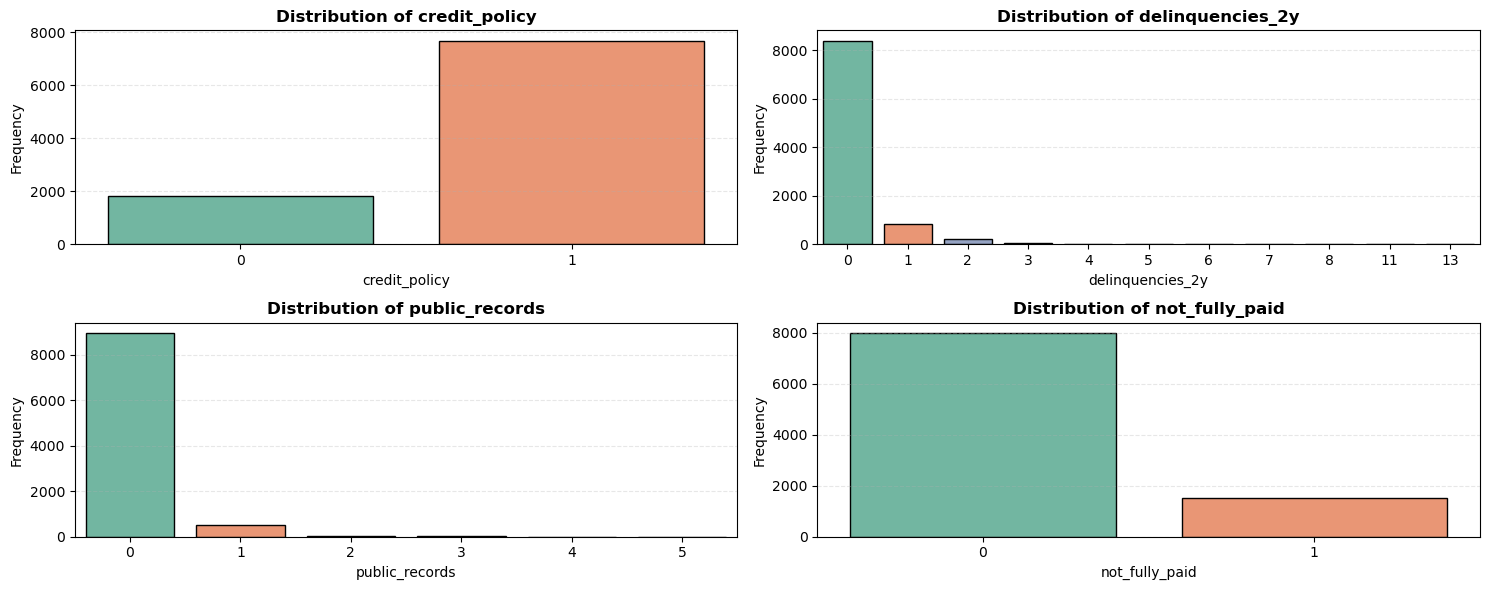

In [12]:

# Separiamo colonne continue e discrete
numeric_cols = data.select_dtypes(include=[np.number]).columns.drop('customer_id')
discrete_cols = ['credit_policy', 'delinquencies_2y', 'public_records', 'not_fully_paid']
continuous_cols = [col for col in numeric_cols if col not in discrete_cols]

# Griglia per variabili continue
n_cols_cont = len(continuous_cols)
n_rows_cont = int(np.ceil(n_cols_cont / 4))

plt.figure(figsize=(20, n_rows_cont * 4))

for i, col in enumerate(continuous_cols):
    plt.subplot(n_rows_cont, 4, i+1)
    vals = data[col].dropna()
    bins = np.linspace(vals.min(), vals.max(), 30)

    ax = sns.histplot(vals, bins=bins, edgecolor="black", stat='density', kde=False)
    sns.kdeplot(vals, color='purple', lw=2, ax=ax)

    plt.title(f"Distribution of {col}", fontsize=12, fontweight='bold')

    # Calcoliamo le statistiche
    mean_val = vals.mean()
    median_val = vals.median()
    skew_val = vals.skew()
    kurt_val = vals.kurt()
    std_val = vals.std()

    # Linee verticali per media e mediana
    plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Media: {mean_val:.2f}')
    plt.axvline(median_val, color='green', linestyle=':', linewidth=2, label=f'Mediana: {median_val:.2f}')

    # Statistiche nella legenda
    plt.plot([], [], ' ', label=f'Skewness: {skew_val:.2f}')
    plt.plot([], [], ' ', label=f'Kurtosis: {kurt_val:.2f}')
    plt.plot([], [], ' ', label=f'Dev. Std: {std_val:.2f}')

    plt.legend(fontsize=8, loc='best')
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.xlabel(col, fontsize=10)
    plt.ylabel('Density', fontsize=10)

plt.tight_layout()
plt.show()

# Griglia per variabili DISCRETE (bar plot)
n_cols_disc = len(discrete_cols)
n_rows_disc = int(np.ceil(n_cols_disc / 2))

plt.figure(figsize=(15, n_rows_disc * 3))

for i, col in enumerate(discrete_cols):
    plt.subplot(n_rows_disc, 2, i+1)
    sns.countplot(data=data, x=col, hue=col, palette='Set2', legend=False, edgecolor="black")
    plt.title(f"Distribution of {col}", fontsize=12, fontweight='bold')
    plt.xlabel(col, fontsize=10)
    plt.ylabel('Frequency', fontsize=10)
    plt.grid(True, linestyle="--", alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

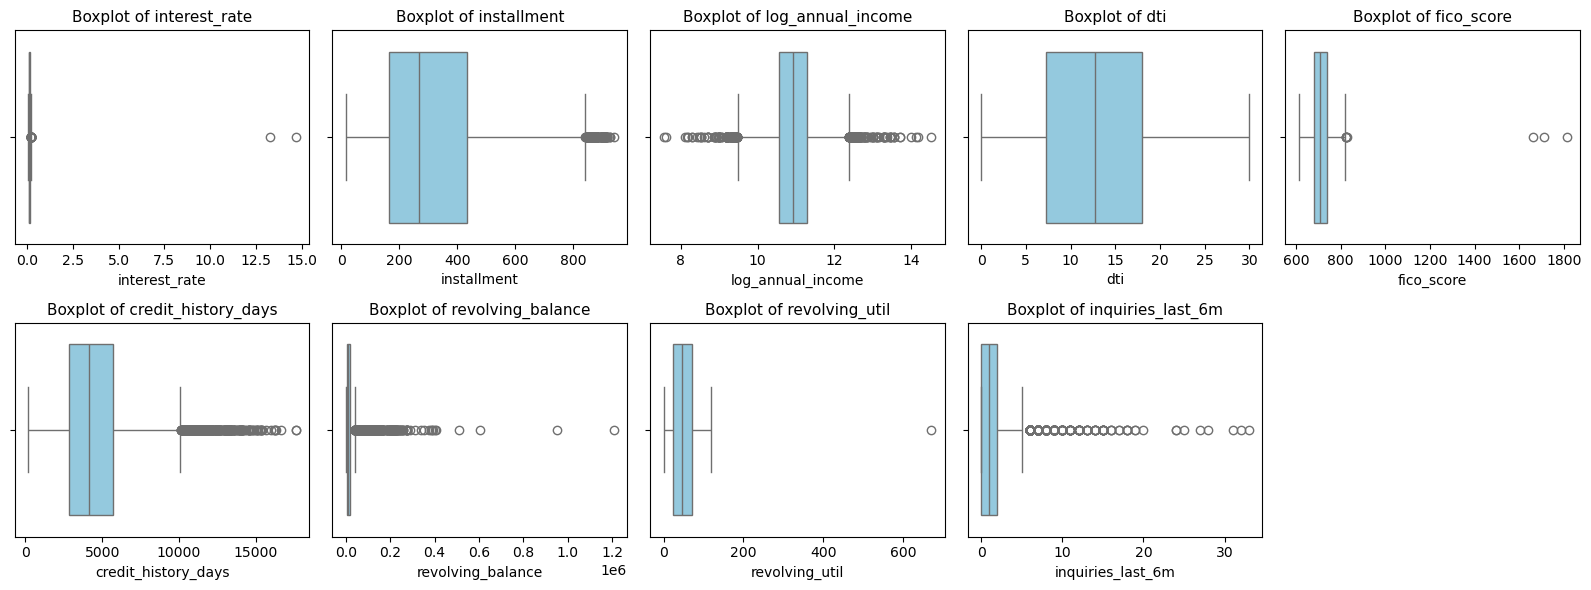

In [13]:
plt.figure(figsize=(16, 6))
for idx, col in enumerate(continuous_cols):
    plt.subplot(2, int(np.ceil(len(continuous_cols)/2)), idx+1)
    sns.boxplot(data=data, x=col, color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=11)
    plt.xlabel(col)
plt.tight_layout()
plt.show()

<a id="interest-rate-dist"></a>
# Come sono distribuiti i tassi di interesse?


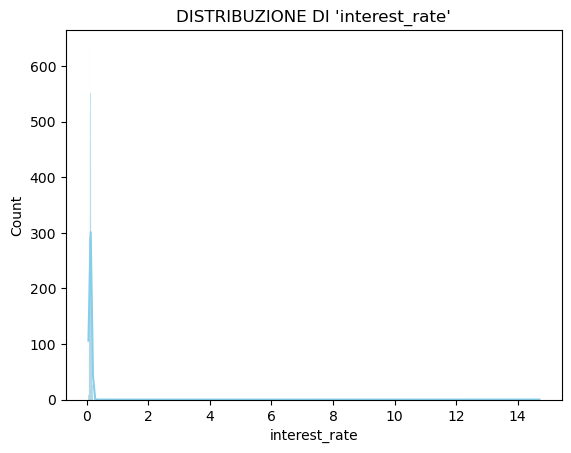

count    9508.000000
mean        0.125583
std         0.202949
min         0.060000
25%         0.103900
50%         0.122100
75%         0.140700
max        14.700000
Name: interest_rate, dtype: float64


In [14]:
sns.histplot(data=data, x='interest_rate', kde=True, color='skyblue')
plt.title("DISTRIBUZIONE DI 'interest_rate'")
plt.show()

print(data['interest_rate'].describe())


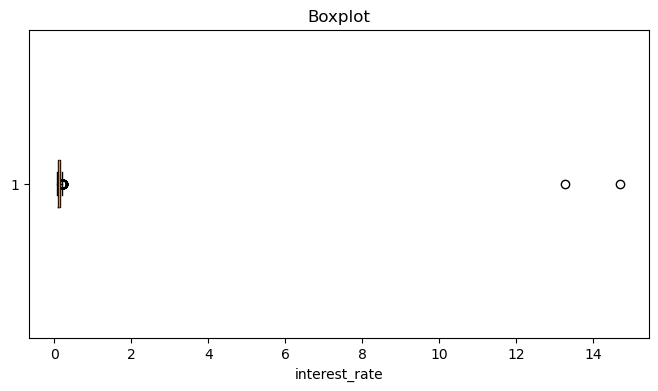

In [15]:
plt.figure(figsize=(8,4))
plt.boxplot(data['interest_rate'], vert=False)
plt.title('Boxplot')
plt.xlabel('interest_rate')
plt.show()

Notiamo valori molto vicini allo zero e altri che arrivano a 14. Questo suggerisce che i tassi potrebbero essere in formato decimale (0.12 invece di 12%). Verifichiamo e correggiamo il problema.

In [16]:
mask_decimal = data['interest_rate'] <= 1
n_corrected = mask_decimal.sum()

if n_corrected > 0:
    print(f"Conversione in corso: trovati {n_corrected} valori in scala decimale (<= 1).")
    data.loc[mask_decimal, 'interest_rate'] = data['interest_rate'] * 100
    print("Conversione completata: ora tutti i valori sono in scala percentuale (0-100).")
else:
    print("Nessun valore in scala decimale (<= 1) trovato. I dati sembrano già in percentuale.")

print("\nStatistiche post-conversione:")
print(data['interest_rate'].describe())

Q1 = data['interest_rate'].quantile(0.25)
Q3 = data['interest_rate'].quantile(0.75)
IQR = Q3 -Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f'Limite inferiore: {lower_bound:.4f}')
print(f'Limite superiore: {upper_bound:.4f}')

Conversione in corso: trovati 9506 valori in scala decimale (<= 1).
Conversione completata: ora tutti i valori sono in scala percentuale (0-100).

Statistiche post-conversione:
count    9508.000000
mean       12.267296
std         2.681129
min         6.000000
25%        10.390000
50%        12.210000
75%        14.070000
max        21.640000
Name: interest_rate, dtype: float64
Limite inferiore: 4.8700
Limite superiore: 19.5900


I limiti calcolati con il metodo IQR (range interquartile) identificano l'intervallo dei valori "normali". Tutto cio che esce da questo intervallo viene considerato outlier.

In [17]:
lower_outlier = data[data['interest_rate'] < lower_bound]

# Filtrare gli upper outliers
upper_outlier = data[data['interest_rate'] > upper_bound]

print("Numero di lower outliers:", len(lower_outlier))
print("Numero di upper outliers:", len(upper_outlier))

Numero di lower outliers: 0
Numero di upper outliers: 51


In [18]:
outliers = data[(data['interest_rate'] < lower_bound) | (data['interest_rate'] > upper_bound)]
print(f'NUMERO DI OUTLIERS TROVATI : {outliers.shape[0]}')

NUMERO DI OUTLIERS TROVATI : 51


In [19]:
print("Esempi di outlier:")
print(outliers['interest_rate'].head())

Esempi di outlier:
2945    20.86
3713    20.11
3991    20.11
4064    19.79
4731    20.17
Name: interest_rate, dtype: float64


### Pulizia degli outlier

Rimuoviamo i valori anomali per ottenere una distribuzione piu rappresentativa della realta dei prestiti.

In [20]:
total_count = len(data)
outliers_count = len(outliers)
# Applichiamo il filtro direttamente a 'data' invece di creare un nuovo DataFrame
data = data[(data['interest_rate'] >= lower_bound) & (data['interest_rate'] <= upper_bound)]
print(f'DIMENSIONE DATASET PULITO (SENZA OUTLIERS) : {data.shape[0]} righe')

cleaned_count = len(data)
removed_percentage = (outliers_count / total_count) * 100

print(f"Percentuale di outliers rimossi: {removed_percentage:.2f}%")

DIMENSIONE DATASET PULITO (SENZA OUTLIERS) : 9457 righe
Percentuale di outliers rimossi: 0.54%


### Cosa abbiamo trovato?

Visualizziamo la distribuzione pulita insieme alle principali statistiche descrittive: media, mediana, deviazione standard, asimmetria (skewness) e curtosi (kurtosis).

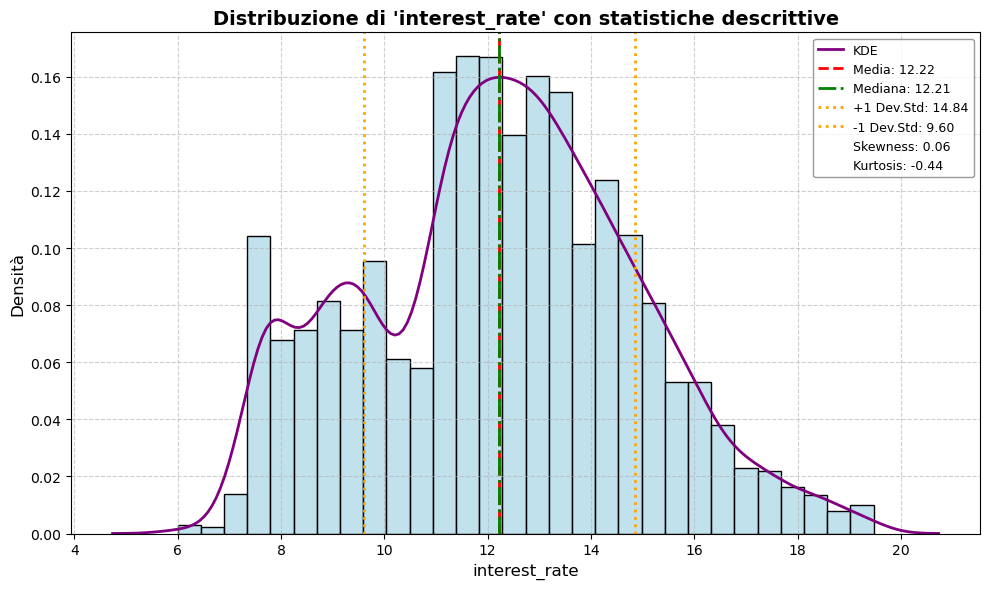

In [21]:
colonna = 'interest_rate'

vals = data[colonna].dropna()

mean_dc = vals.mean()
median_dc = vals.median()
skewness = vals.skew()
kurtosis = vals.kurt()
std_dc = vals.std()


plt.figure(figsize=(10, 6))

sns.histplot(vals, bins=30, color='lightblue', edgecolor='black', stat='density', kde=False)
sns.kdeplot(vals, color='purple', lw=2, label='KDE')

plt.axvline(mean_dc, color='red', linestyle='--', linewidth=2, label=f'Media: {mean_dc:.2f}')
plt.axvline(median_dc, color='green', linestyle='-.', linewidth=2, label=f'Mediana: {median_dc:.2f}')
plt.axvline(mean_dc + std_dc, color='orange', linestyle=':', linewidth=2, label=f'+1 Dev.Std: {(mean_dc + std_dc):.2f}')
plt.axvline(mean_dc - std_dc, color='orange', linestyle=':', linewidth=2, label=f'-1 Dev.Std: {(mean_dc - std_dc):.2f}')

plt.plot([], [], ' ', label=f'Skewness: {skewness:.2f}')
plt.plot([], [], ' ', label=f'Kurtosis: {kurtosis:.2f}')

plt.title(f"Distribuzione di '{colonna}' con statistiche descrittive", fontsize=14, fontweight='bold')
plt.xlabel(colonna, fontsize=12)
plt.ylabel("Densità", fontsize=12)
plt.legend(fontsize=9, loc='best', frameon=True, facecolor='white', edgecolor='gray')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

Il tasso di interesse medio e circa 12.5%, con la maggior parte dei prestiti tra 10% e 14%. Tassi sopra il 20% sono rari, sotto il 6% sono eccezioni riservate a clienti con profilo creditizio eccellente.

La distribuzione è approssimativamente simmetrica, il che indica che LendingClub applica tassi abbastanza standardizzati con variazioni legate al profilo di rischio del cliente.

### Cosa abbiamo scoperto sui tassi di interesse

**Prima della pulizia**: la distribuzione era fortemente sbilanciata a causa di valori estremi, probabilmente errori di inserimento.

**Dopo la pulizia**: distribuzione simmetrica centrata sul 12.5%. I tassi sono ora omogenei e realistici per un mercato di prestiti.

Questo ci conferma che la piattaforma applica una politica di pricing ragionevolmente uniforme, con aggiustamenti basati sul rischio individuale.

<a id="installment-analisi"></a>
## Come sono distribuite le rate ?

La rata dipende dall'importo del prestito, dalla durata e dal tasso di interesse.

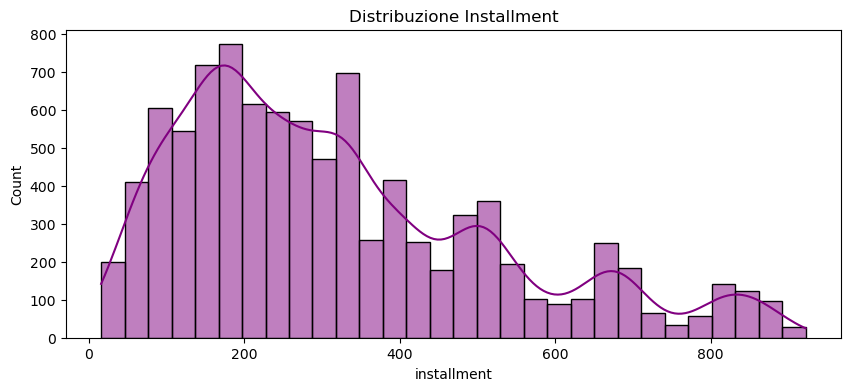

STATISTICHE DESCRITTIVE:

count    9457.000000
mean      319.212909
std       206.120064
min        15.670000
25%       164.020000
50%       269.070000
75%       432.260000
max       922.420000
Name: installment, dtype: float64


In [22]:
plt.figure(figsize=(10,4))
sns.histplot(data['installment'], kde=True, bins = 30, color='purple')
plt.title('Distribuzione Installment')
plt.show()

print('STATISTICHE DESCRITTIVE:\n')
print(data['installment'].describe())

Il boxplot identifica valori che il metodo statistico considera "anomali".

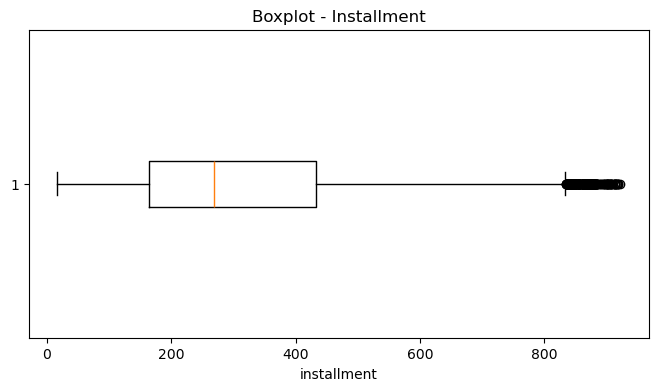

In [23]:
plt.figure(figsize=(8,4))
plt.boxplot(data['installment'], vert=False)
plt.title('Boxplot - Installment')
plt.xlabel('installment')
plt.show()

Calcoliamo i limiti statistici per identificare gli outlier.

In [24]:
Q1 = data['installment'].quantile(0.25)
Q3 = data['installment'].quantile(0.75)
IQR = Q3 - Q1

lowerBound = Q1 - 1.5 * IQR
upperBound = Q3 + 1.5* IQR

print(f'Limite Inferiore: {lowerBound:.2f}')
print(f'Limite Superire: {upperBound:.2f}')



Limite Inferiore: -238.34
Limite Superire: 834.62


Quanti outlier troviamo?

In [25]:
lower_outliers = data[data['installment'] < lowerBound]

upper_outliers = data[data['installment'] > upperBound]

print("Numero di lower outliers:", len(lower_outliers))
print("Numero di upper outliers:", len(upper_outliers))

Numero di lower outliers: 0
Numero di upper outliers: 234


In [26]:
all_outliers = data[(data['installment'] < lowerBound) | (data['installment'] > upperBound)]

print("Numero totale di outlier :", all_outliers.shape[0])

Numero totale di outlier : 234


In [27]:
all_outliers = data[(data['installment'] < lowerBound) | (data['installment'] > upperBound)]
print("Esempi di outlier:")
print(all_outliers[['installment','dti', 'customer_id']].head())

Esempi di outlier:
     installment    dti  customer_id
160       839.95  24.85        10161
237       859.07  20.79        10238
246       836.23   7.99        10247
249       842.47  12.81        10250
271       862.97   5.79        10272


Le rate alte (es. 842 euro) vengono segnalate come outlier dal metodo IQR, ma non sono errori. Rappresentano semplicemente prestiti di importo maggiore. Non le rimuoviamo perche sono dati legittimi, non anomalie.

### Forma della distribuzione

Esaminiamo skewness e kurtosis per capire quanto la distribuzione si discosta da una normale.

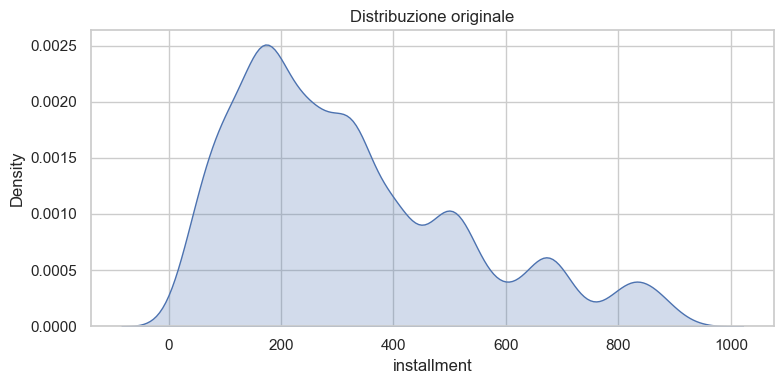


INSTALLMENT
Asimmetria_Skewness: 0.91 | Kurtosis: 0.14


In [28]:
sns.set_theme(style="whitegrid")

skew = data['installment'].skew()
kurt = data['installment'].kurt()


fig, axes = plt.subplots(1, 1, figsize=(8, 4))
sns.kdeplot(data['installment'], ax = axes, fill=True)
axes.set_title('Distribuzione originale')


plt.tight_layout()
plt.show()

for col in ['installment']:
    print(f"\n{col.upper()}")
    print(f"Asimmetria_Skewness: {data[col].skew():.2f} | Kurtosis: {data[col].kurt():.2f}")

La distribuzione e leggermente sbilanciata verso destra (skewness positiva), confermando che ci sono piu rate basse che alte. La curtosi indica una forma simile alla normale ma con code leggermente piu pesanti, quindi qualche valore estremo è presente.

<a id="credit_history_days"></a>
## L'anzianità della storia creditizia dei clienti

Questa variabile misura da quanti giorni il cliente ha una storia creditizia attiva. In teoria, una storia piu lunga è un indice positivo per la banca per valutare l'affidabilità.

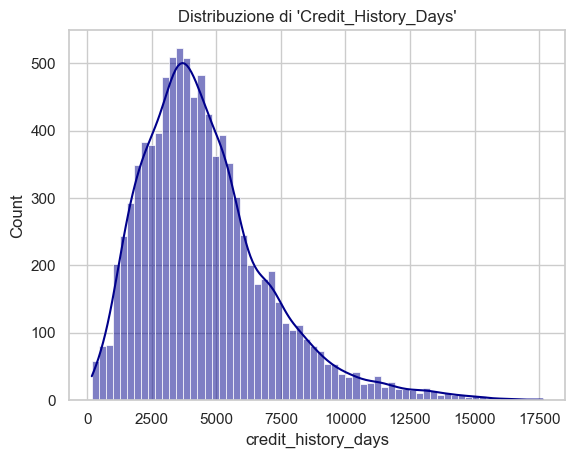

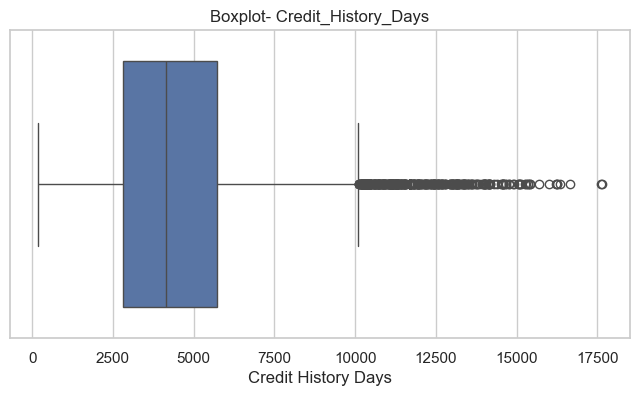

count     9457.000000
mean      4569.165191
std       2496.544737
min        180.041667
25%       2820.041667
50%       4139.958333
75%       5730.041667
max      17639.958330
Name: credit_history_days, dtype: float64

Skewness: 1.1600
Kurtosis: 1.9480


In [29]:
sns.histplot (data = data, x ='credit_history_days', kde = True, color = 'darkblue')
plt.title("Distribuzione di 'Credit_History_Days'")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x = data['credit_history_days'])
plt.title('Boxplot- Credit_History_Days')
plt.xlabel('Credit History Days')
plt.show()

print(data['credit_history_days'].describe())

print(f"\nSkewness: {data['credit_history_days'].skew():.4f}")
print(f"Kurtosis: {data['credit_history_days'].kurt():.4f}")


### Conversione in anni

I giorni sono poco intuitivi, convertiamoli in anni per una lettura piu immediata:
- 0-5 anni: clienti giovani o nuovi al credito
- 5-20 anni: esperienza normale
- 20-35 anni: clienti con lunga esperienza
- oltre 45 anni: valore sospetto, da verificare

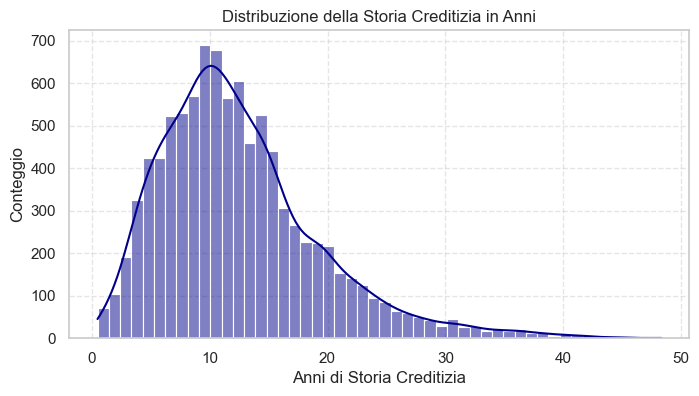

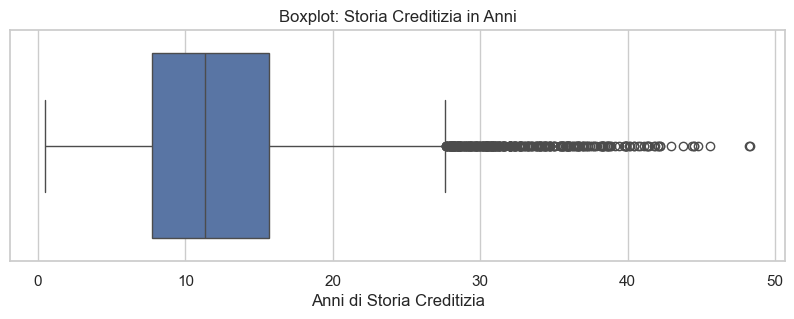

count    9457.000000
mean       12.509693
std         6.835167
min         0.492927
25%         7.720853
50%        11.334588
75%        15.687999
max        48.295574
Name: credit_history_years, dtype: float64

Skewness: 1.1600
Kurtosis: 1.9480


In [30]:
data['credit_history_years'] = data['credit_history_days'] / 365.25

plt.figure(figsize=(8,4))
sns.histplot(data['credit_history_years'], kde=True, bins=50, color = 'darkblue')
plt.title('Distribuzione della Storia Creditizia in Anni')
plt.xlabel('Anni di Storia Creditizia')
plt.ylabel('Conteggio')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

plt.figure(figsize=(10,3))
sns.boxplot(x=data['credit_history_years'])
plt.title('Boxplot: Storia Creditizia in Anni')
plt.xlabel('Anni di Storia Creditizia')
plt.show()

print(data['credit_history_years'].describe())

print(f"\nSkewness: {data['credit_history_days'].skew():.4f}")
print(f"Kurtosis: {data['credit_history_days'].kurt():.4f}")

In [31]:
Q1 = data['credit_history_years'].quantile(0.25)
Q3 = data['credit_history_years'].quantile(0.75)
IQR = Q3 - Q1

lower_bound_chd = Q1 - 1.5 * IQR
upper_bound_chd = Q3 + 1.5 * IQR

print(f'Limite Inferiore: {lower_bound_chd:.4f}')
print(f'Limite Superiore: {upper_bound_chd:.4f}')

Limite Inferiore: -4.2299
Limite Superiore: 27.6387


Il metodo IQR suggerirebbe un limite di circa 28 anni, ma e troppo restrittivo. Nella realta, 45 anni di storia creditizia sono il massimo plausibile: richiederebbe aver aperto un conto a 18 anni ed essere ora oltre i 60. Usiamo 45 anni come soglia ragionevole.

In [32]:
upper_limit = 45
outliers = data[data['credit_history_years'] > upper_limit]
df_clean = data[data['credit_history_years'] <= upper_limit]

print('Numero di outlier sopra i 45 anni:', len(outliers))

Numero di outlier sopra i 45 anni: 3


In [33]:
print('Outliers nel dataset:')
print(outliers['credit_history_years'].head())

Outliers nel dataset:
5801    45.590691
7553    48.229979
8430    48.295574
Name: credit_history_years, dtype: float64


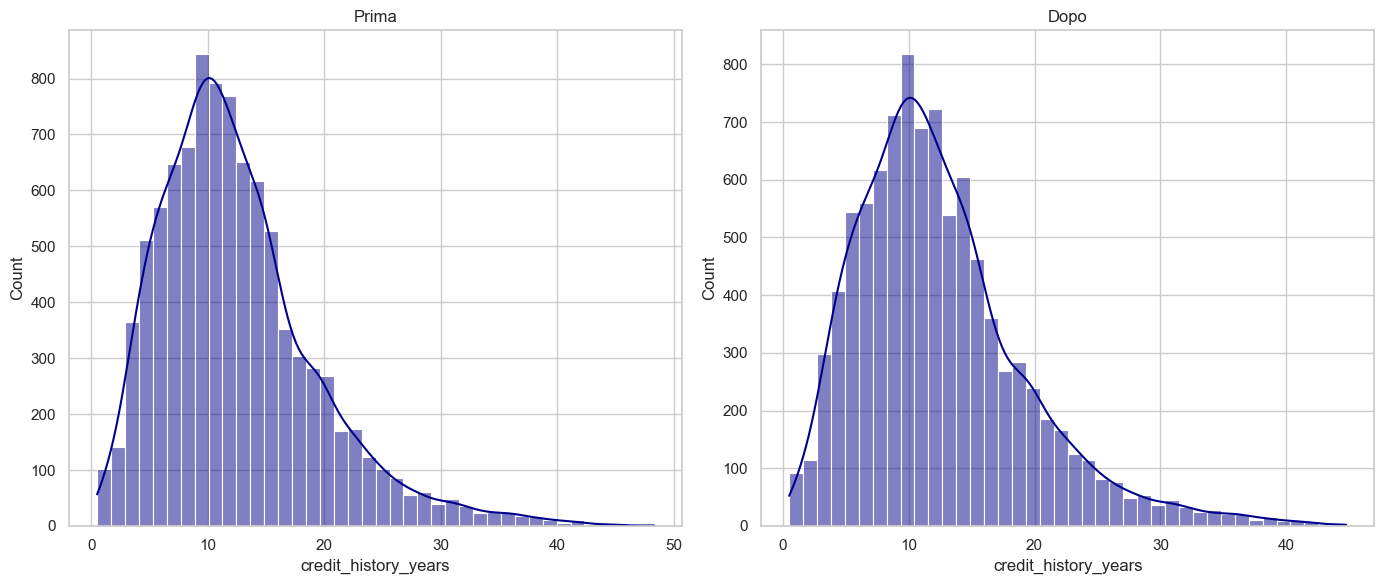

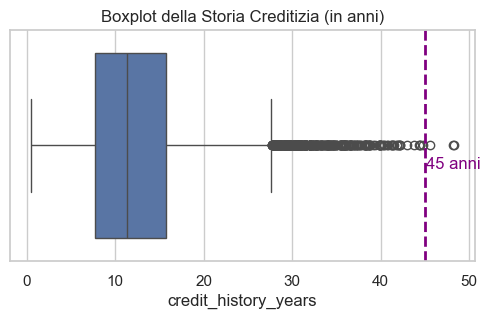

count    9454.000000
mean       12.498630
std         6.807936
min         0.492927
25%         7.720853
50%        11.334588
75%        15.687999
max        44.763860
Name: credit_history_years, dtype: float64

Skewness: 1.1365
Kurtosis: 1.8166


In [34]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(data["credit_history_years"], kde=True, bins=40, color = 'darkblue')
plt.title("Prima")
plt.xlabel("credit_history_years")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
sns.histplot(df_clean["credit_history_years"], kde=True, bins=40, color = 'darkblue')
plt.title("Dopo")
plt.xlabel("credit_history_years")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 3))
sns.boxplot(x=data["credit_history_years"])
plt.title("Boxplot della Storia Creditizia (in anni)")


plt.axvline(x=45, color='purple', linestyle='--', linewidth=2)
plt.text(45.2, 0.1, "45 anni", color='purple')

plt.xlabel("credit_history_years")
plt.show()


print(df_clean['credit_history_years'].describe())

print(f"\nSkewness: {df_clean['credit_history_years'].skew():.4f}")
print(f"Kurtosis: {df_clean['credit_history_years'].kurt():.4f}")

Abbiamo rimosso pochissimi record (0.03%). La distribuzione rimane sbilanciata verso destra: la maggior parte dei clienti ha storie creditizie di durata media, mentre solo pochi hanno storie molto lunghe.

<a id="fico-score"></a>
## Quanto sono affidabili i nostri clienti?

Come sono distribuiti i punteggi FICO? Che tipo di clientela attrae LendingClub?

Il FICO Score e il numero che sintetizza l'affidabilita creditizia nel mercato americano. La scala va da 300 a 850:
- Sotto 580: Pessimo
- 580-669: Discreto
- 670-739: Buono
- 740-799: Molto Buono
- Sopra 800: Eccellente

Questo punteggio influenza direttamente il tasso di interesse applicato e la probabilita di ottenere il prestito.

In [35]:
print("=== STATISTICHE FICO SCORE ===")
print(data['fico_score'].describe())
print(f"\nSkewness: {data['fico_score'].skew():.4f}")
print(f"Kurtosis: {data['fico_score'].kurt():.4f}")

=== STATISTICHE FICO SCORE ===
count    9457.000000
mean      711.336470
std        42.052375
min       612.000000
25%       682.000000
50%       707.000000
75%       737.000000
max      1812.000000
Name: fico_score, dtype: float64

Skewness: 4.8639
Kurtosis: 109.9192


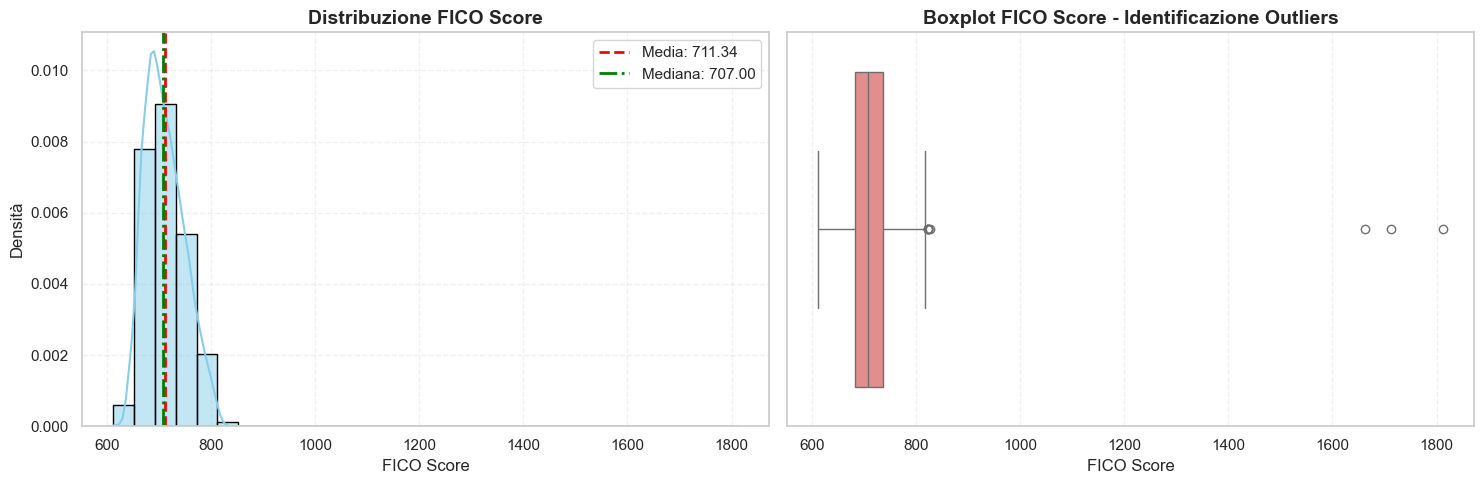

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Istogramma + KDE
ax1 = axes[0]
sns.histplot(data['fico_score'], bins=30, kde=True, color='skyblue', edgecolor='black', ax=ax1, stat='density')
ax1.axvline(data['fico_score'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {data["fico_score"].mean():.2f}')
ax1.axvline(data['fico_score'].median(), color='green', linestyle='-.', linewidth=2, label=f'Mediana: {data["fico_score"].median():.2f}')
ax1.set_title('Distribuzione FICO Score', fontsize=14, fontweight='bold')
ax1.set_xlabel('FICO Score', fontsize=12)
ax1.set_ylabel('Densità', fontsize=12)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.3)

# Boxplot
ax2 = axes[1]
sns.boxplot(x=data['fico_score'], color='lightcoral', ax=ax2)
ax2.set_title('Boxplot FICO Score - Identificazione Outliers', fontsize=14, fontweight='bold')
ax2.set_xlabel('FICO Score', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

In [37]:
# Identificazione outliers per FICO Score
Q1_fico = data['fico_score'].quantile(0.25)
Q3_fico = data['fico_score'].quantile(0.75)
IQR_fico = Q3_fico - Q1_fico

lower_bound_fico = Q1_fico - 1.5 * IQR_fico
upper_bound_fico = 851

print(f'Limite inferiore: {lower_bound_fico:.2f}')
print(f'Limite superiore: {upper_bound_fico:.2f}')

outliers_fico = data[(data['fico_score'] < lower_bound_fico) | (data['fico_score'] > upper_bound_fico)]
print(f'\nNUMERO DI OUTLIERS TROVATI: {outliers_fico.shape[0]}')
print(f'Percentuale di outliers: {(outliers_fico.shape[0] / len(data)) * 100:.2f}%')
print(f'Valore massimo FICO Score: {data["fico_score"].max()}')

# Rimozione degli outlier
total_count_fico = len(data)
outliers_count_fico = len(outliers_fico)

print(f'\n{"="*60}')
print(f'PULIZIA FICO SCORE')
print(f'{"="*60}')
print(f'Dimensione dataset PRIMA della pulizia: {total_count_fico} righe')

data = data[(data['fico_score'] >= lower_bound_fico) & (data['fico_score'] <= upper_bound_fico)]

print(f'Dimensione dataset DOPO la pulizia: {len(data)} righe')
print(f'Righe rimosse: {outliers_count_fico}')
print(f'Percentuale rimossa: {(outliers_count_fico / total_count_fico) * 100:.2f}%')

# Nuove statistiche dopo pulizia
print(f'\n{"="*60}')
print("STATISTICHE FICO SCORE DOPO PULIZIA")
print(f'{"="*60}')
print(data['fico_score'].describe())
print(f"\nSkewness: {data['fico_score'].skew():.4f}")
print(f"Kurtosis: {data['fico_score'].kurt():.4f}")
print(f'{"="*60}')
print(data['fico_score'].max())

Limite inferiore: 599.50
Limite superiore: 851.00

NUMERO DI OUTLIERS TROVATI: 3
Percentuale di outliers: 0.03%
Valore massimo FICO Score: 1812

PULIZIA FICO SCORE
Dimensione dataset PRIMA della pulizia: 9457 righe
Dimensione dataset DOPO la pulizia: 9454 righe
Righe rimosse: 3
Percentuale rimossa: 0.03%

STATISTICHE FICO SCORE DOPO PULIZIA
count    9454.000000
mean      711.013645
std        37.936399
min       612.000000
25%       682.000000
50%       707.000000
75%       737.000000
max       827.000000
Name: fico_score, dtype: float64

Skewness: 0.4616
Kurtosis: -0.4306
827


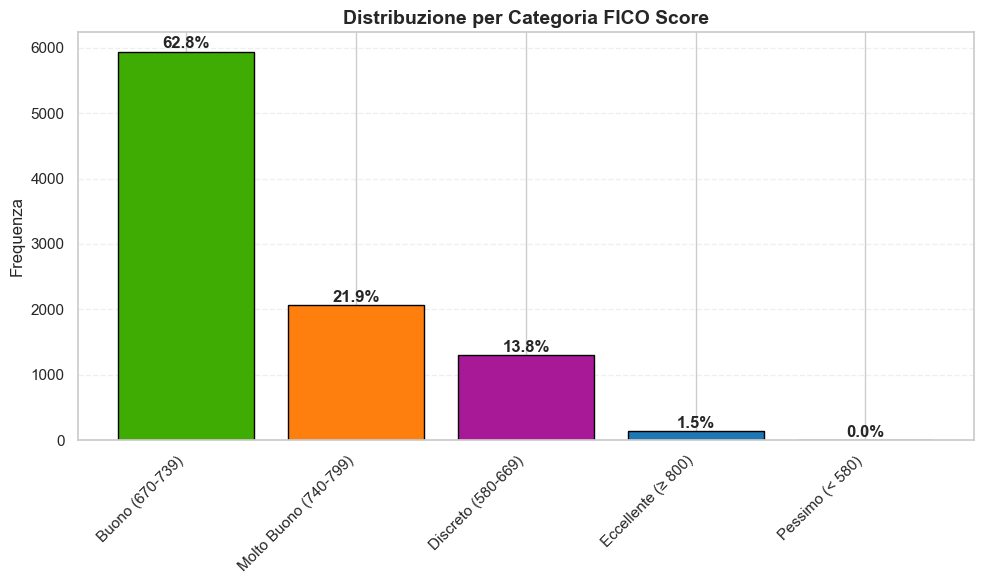


=== DISTRIBUZIONE PER CATEGORIA ===
Buono (670-739): 5936 (62.79%)
Molto Buono (740-799): 2070 (21.90%)
Discreto (580-669): 1308 (13.84%)
Eccellente (≥ 800): 140 (1.48%)
Pessimo (< 580): 0 (0.00%)


In [38]:
def classify_fico(score):
    if score < 580:
        return 'Pessimo (< 580)'
    elif score < 670:
        return 'Discreto (580-669)'
    elif score < 740:
        return 'Buono (670-739)'
    elif score < 800:
        return 'Molto Buono (740-799)'
    else:
        return 'Eccellente (≥ 800)'

data['fico_category'] = data['fico_score'].apply(classify_fico)

category_order = ['Pessimo (< 580)','Discreto (580-669)', 'Buono (670-739)', 'Molto Buono (740-799)', 'Eccellente (≥ 800)']
data['fico_category'] = pd.Categorical(data['fico_category'], categories=category_order, ordered=True)

plt.figure(figsize=(10, 6))

fico_counts = data['fico_category'].value_counts()
colors = ['#3fac03', '#ff7f0e', "#a81997", '#1f77b4', '#9467bd']
plt.bar(range(len(fico_counts)), fico_counts.values, color=colors, edgecolor='black')
plt.xticks(range(len(fico_counts)), fico_counts.index, rotation=45, ha='right')
plt.title('Distribuzione per Categoria FICO Score', fontsize=14, fontweight='bold')
plt.ylabel('Frequenza', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3, axis='y')

# Percentuali
for i, (cat, count) in enumerate(fico_counts.items()):
    pct = (count / len(data)) * 100
    plt.text(i, count + 50, f'{pct:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n=== DISTRIBUZIONE PER CATEGORIA ===")
for cat, count in fico_counts.items():
    print(f"{cat}: {count} ({(count/len(data))*100:.2f}%)")

<a id="purpose-analisi"></a>
## Perche i clienti chiedono un prestito?

Quali sono le motivazioni piu comuni? 

La variabile `purpose` indica lo scopo dichiarato del prestito. 

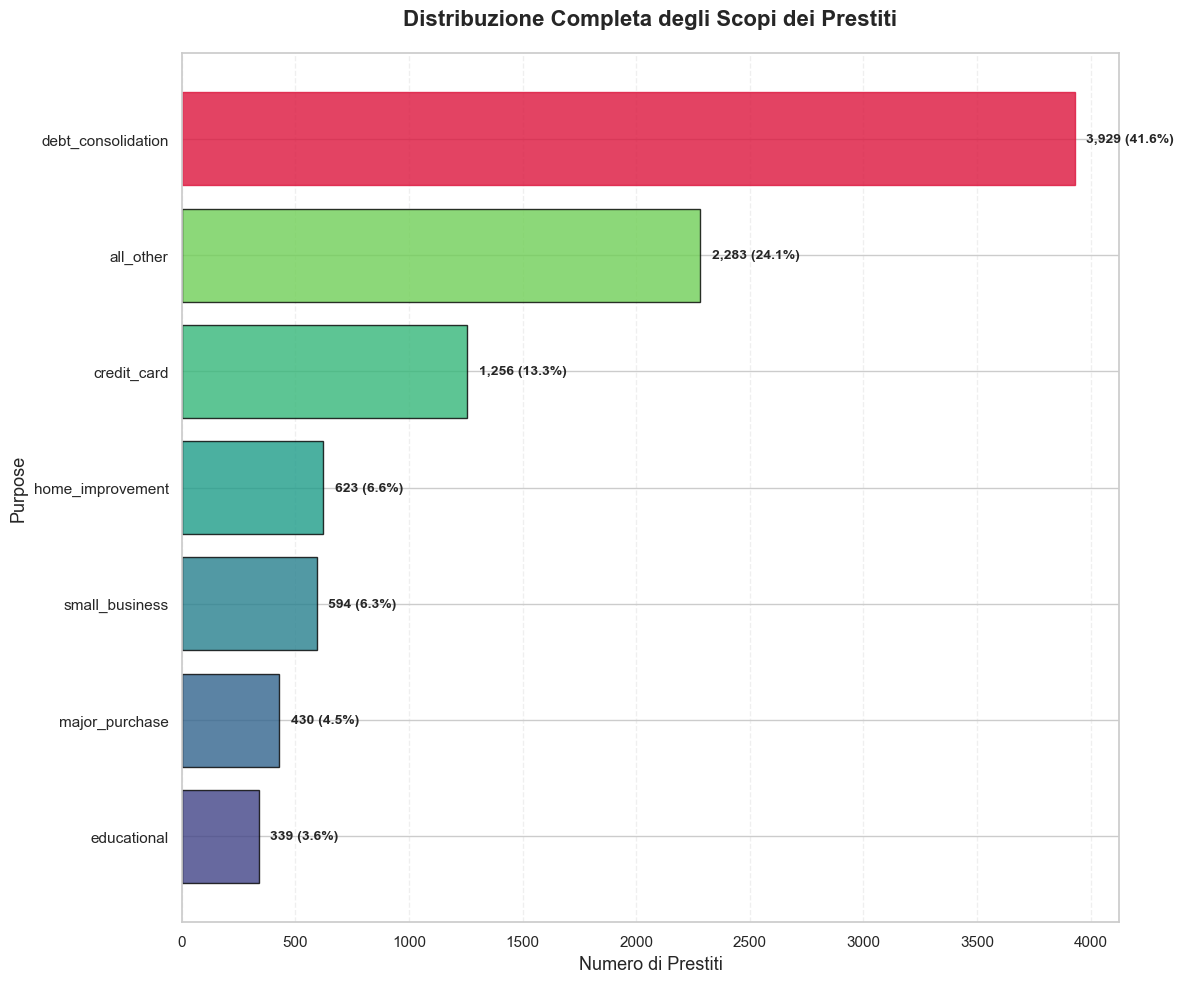


                    STATISTICHE PURPOSE
Purpose                               Count      Percentage
----------------------------------------------------------------------
debt_consolidation                    3,929          41.56%
all_other                             2,283          24.15%
credit_card                           1,256          13.29%
home_improvement                        623           6.59%
small_business                          594           6.28%
major_purchase                          430           4.55%
educational                             339           3.59%
TOTALE                                9,454         100.00%

Numero totale di categorie:         7
Categoria più frequente:            debt_consolidation (3,929 prestiti)
Categoria meno frequente:           educational (339 prestiti)


In [39]:

purpose_counts = data['purpose'].value_counts()
purpose_pct = (purpose_counts / len(data) * 100)

purpose_counts_sorted = purpose_counts.sort_values()

fig, ax = plt.subplots(figsize=(12, 10))

colors_gradient = plt.cm.viridis(np.linspace(0.2, 0.9, len(purpose_counts_sorted)))

bars = ax.barh(range(len(purpose_counts_sorted)),
               purpose_counts_sorted.values,
               color=colors_gradient,
               edgecolor='black',
               alpha=0.8)

# Colora in rosso la barra più alta
max_idx = np.argmax(purpose_counts_sorted.values)
bars[max_idx].set_color('crimson')

# Aggiungi le percentuali alla fine di ogni barra
for i, (purpose, count) in enumerate(purpose_counts_sorted.items()):
    pct = (count / len(data)) * 100
    ax.text(count + 50, i, f'{count:,} ({pct:.1f}%)',
            va='center', fontweight='bold', fontsize=10)

# Imposta le etichette sull'asse Y
ax.set_yticks(range(len(purpose_counts_sorted)))
ax.set_yticklabels(purpose_counts_sorted.index, fontsize=11)

ax.set_title('Distribuzione Completa degli Scopi dei Prestiti',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Numero di Prestiti', fontsize=13)
ax.set_ylabel('Purpose', fontsize=13)

ax.grid(True, linestyle='--', alpha=0.3, axis='x')


plt.tight_layout()
plt.show()

print("\n" + "="*70)
print(" "*20 + "STATISTICHE PURPOSE")
print("="*70)
print(f"{'Purpose':<30} {'Count':>12} {'Percentage':>15}")
print("-"*70)
for purpose, count in purpose_counts.items():
    pct = (count / len(data)) * 100
    print(f"{purpose:<30} {count:>12,} {pct:>14.2f}%")
print("="*70)
print(f"{'TOTALE':<30} {len(data):>12,} {100.0:>14.2f}%")
print("="*70)

# Statistiche aggiuntive
print(f"\n{'Numero totale di categorie:':<35} {len(purpose_counts)}")
print(f"{'Categoria più frequente:':<35} {purpose_counts.index[0]} ({purpose_counts.iloc[0]:,} prestiti)")
print(f"{'Categoria meno frequente:':<35} {purpose_counts.index[-1]} ({purpose_counts.iloc[-1]:,} prestiti)")

<a id="annual-income"></a>
## Qual è la distribuzione dei redditi?


Il reddito e salvato come logaritmo naturale (`log_annual_income`). Lo riconvertiamo per vedere i valori reali in dollari.

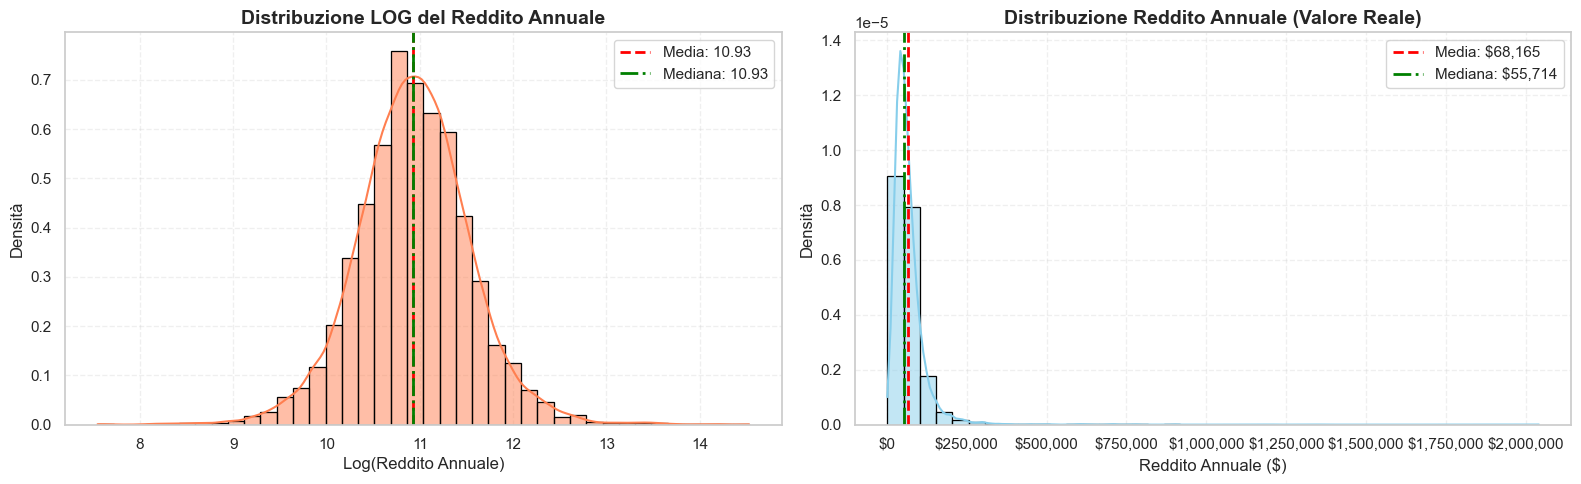


Skewness (Log): 0.0544
Skewness (Reale): 9.8382
min 1896.0000003508226
max 2039784.004362027
mean 68164.73258872403
std 60664.94047772514


In [40]:

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
data['annual_income'] = np.exp(data['log_annual_income'])

ax1 = axes[0]
sns.histplot(data['log_annual_income'], bins=40, kde=True, color='coral', edgecolor='black', ax=ax1, stat='density')
ax1.axvline(data['log_annual_income'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Media: {data["log_annual_income"].mean():.2f}')
ax1.axvline(data['log_annual_income'].median(), color='green', linestyle='-.', linewidth=2,
            label=f'Mediana: {data["log_annual_income"].median():.2f}')
ax1.set_title('Distribuzione LOG del Reddito Annuale', fontsize=14, fontweight='bold')
ax1.set_xlabel('Log(Reddito Annuale)', fontsize=12)
ax1.set_ylabel('Densità', fontsize=12)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.3)


ax2 = axes[1]
sns.histplot(data['annual_income'], bins=40, kde=True, color='skyblue', edgecolor='black', ax=ax2, stat='density')
ax2.axvline(data['annual_income'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Media: ${data["annual_income"].mean():,.0f}')
ax2.axvline(data['annual_income'].median(), color='green', linestyle='-.', linewidth=2,
            label=f'Mediana: ${data["annual_income"].median():,.0f}')
ax2.set_title('Distribuzione Reddito Annuale (Valore Reale)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Reddito Annuale ($)', fontsize=12)
ax2.set_ylabel('Densità', fontsize=12)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.3)


ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

print(f"\nSkewness (Log): {data['log_annual_income'].skew():.4f}")
print(f"Skewness (Reale): {data['annual_income'].skew():.4f}")

data['annual_income'].describe()
print("min", data['annual_income'].min())
print("max", data['annual_income'].max())
print("mean", data['annual_income'].mean())
print("std", data['annual_income'].std())

# Annual income
Abbiamo creato una nuova variabile annual_income per visualizzare i dati reali del reddito dei clienti, come si può facilmente notare dal grafico, ci sono tanti outliers, ma la loro esistenza è significativa essendo che si tratta del reddito

<a id="dti-analisi"></a>
## Il rapporto debito/reddito (DTI)

Il DTI (Debt-to-Income) misura quanta parte del reddito mensile va a pagare debiti esistenti.

Formula: DTI = (Debiti Mensili / Reddito Mensile) x 100

Un DTI alto come per esempio il 40%, significa che il 40% dello stipendio andrà verso le rate.

In [41]:
Q1 = data['dti'].quantile(0.25)
Q3 = data['dti'].quantile(0.75)
IQR = Q3 - Q1

DTI_LOWER= Q1 - 1.5 * IQR
DTI_UPPER = Q3 + 1.5 * IQR


data_clean_dti = data[(data['dti'] >= DTI_LOWER) & (data['dti'] <= DTI_UPPER)]

print("="*60)
print("CONFRONTO STATISTICHE DTI")
print("="*60)

stats_comparison = pd.DataFrame({
    'Metrica': ['Count', 'Media', 'Mediana', 'Dev. Std', 'Min', 'Q1', 'Q3', 'Max', 'Skewness', 'Kurtosis'],
    'Con Outliers': [
        len(data),
        data['dti'].mean(),
        data['dti'].median(),
        data['dti'].std(),
        data['dti'].min(),
        data['dti'].quantile(0.25),
        data['dti'].quantile(0.75),
        data['dti'].max(),
        data['dti'].skew(),
        data['dti'].kurtosis()
    ],
    'Senza Outliers': [
        len(data_clean_dti),
        data_clean_dti['dti'].mean(),
        data_clean_dti['dti'].median(),
        data_clean_dti['dti'].std(),
        data_clean_dti['dti'].min(),
        data_clean_dti['dti'].quantile(0.25),
        data_clean_dti['dti'].quantile(0.75),
        data_clean_dti['dti'].max(),
        data_clean_dti['dti'].skew(),
        data_clean_dti['dti'].kurtosis()
    ]
})

stats_comparison['Variazione (%)'] = ((stats_comparison['Senza Outliers'] - stats_comparison['Con Outliers']) /
                                       stats_comparison['Con Outliers'] * 100).round(2)

print("\n" + stats_comparison.to_string(index=False))
print("\n" + "="*60)

CONFRONTO STATISTICHE DTI

 Metrica  Con Outliers  Senza Outliers  Variazione (%)
   Count   9454.000000     9454.000000             0.0
   Media     12.635253       12.635253             0.0
 Mediana     12.710000       12.710000             0.0
Dev. Std      6.887045        6.887045             0.0
     Min      0.000000        0.000000             NaN
      Q1      7.232500        7.232500             0.0
      Q3     18.000000       18.000000             0.0
     Max     29.960000       29.960000             0.0
Skewness      0.020939        0.020939             0.0
Kurtosis     -0.902210       -0.902210            -0.0



# Outliers DTI
Come si può vedere dalle statistiche, data_clean e data originale hanno variazione NaN, essendo identici e dimostrando l'assenza totale di outliers in DTI

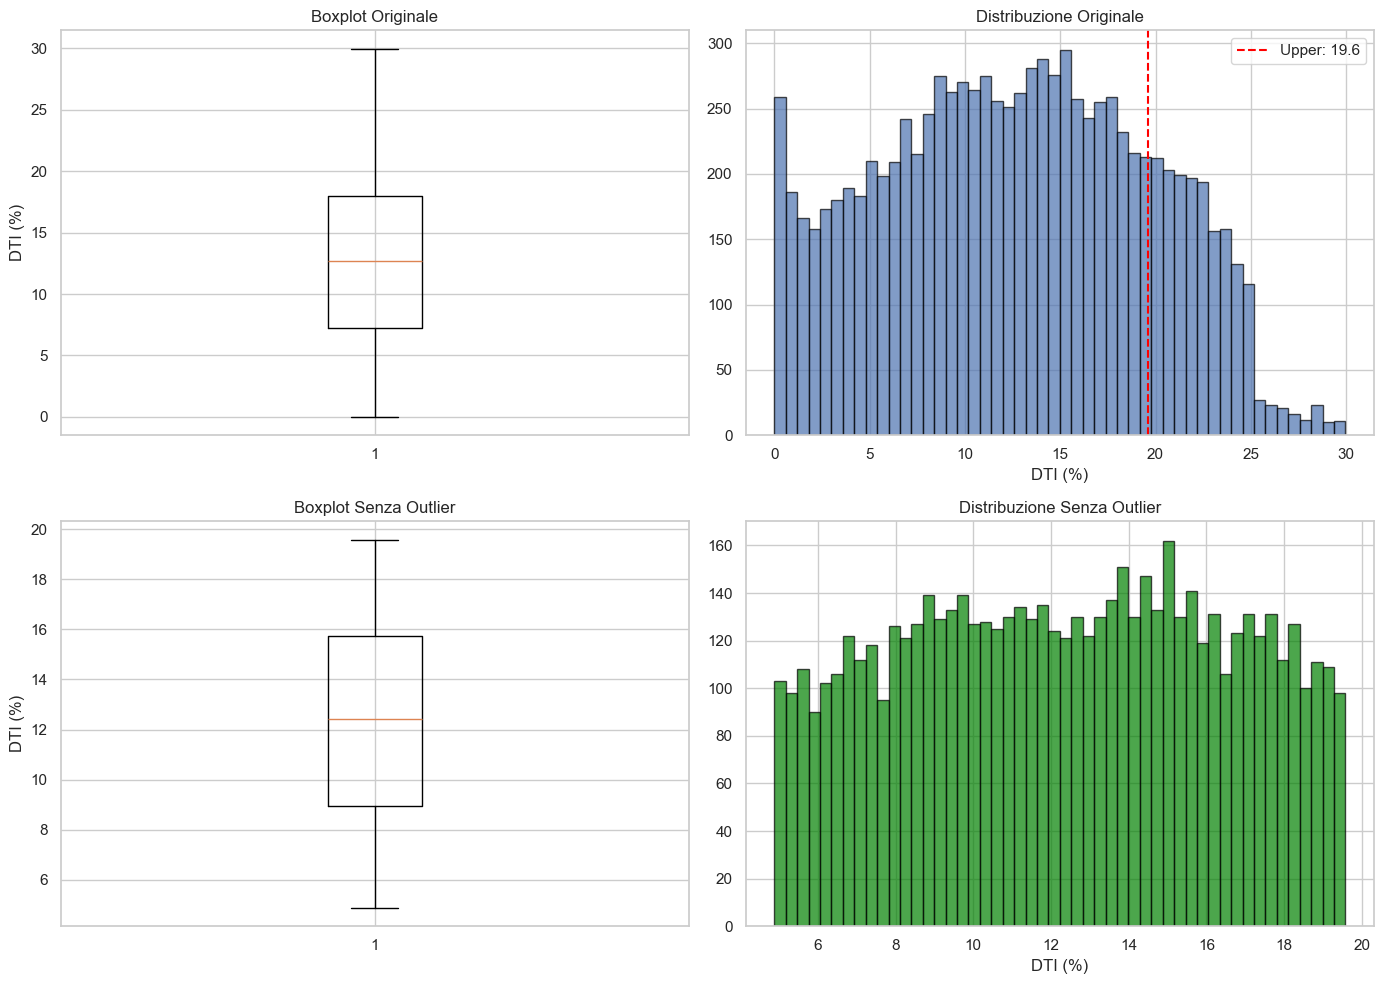


Confronto:
  Prima:  9454 righe, Media DTI: 12.64%
  Dopo:   6154 righe, Media DTI: 12.34%


In [42]:
# Confronto Prima/Dopo
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Prima: Boxplot originale
axes[0, 0].boxplot(data['dti'], vert=True)
axes[0, 0].set_title('Boxplot Originale')
axes[0, 0].set_ylabel('DTI (%)')

# Prima: Istogramma
axes[0, 1].hist(data['dti'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].axvline(upper_bound, color='red', linestyle='--', label=f'Upper: {upper_bound:.1f}')
axes[0, 1].set_title('Distribuzione Originale')
axes[0, 1].set_xlabel('DTI (%)')
axes[0, 1].legend()

# Dopo: Boxplot pulito
data_clean = data[(data['dti'] >= lower_bound) & (data['dti'] <= upper_bound)]
axes[1, 0].boxplot(data_clean['dti'], vert=True)
axes[1, 0].set_title('Boxplot Senza Outlier')
axes[1, 0].set_ylabel('DTI (%)')

# Dopo: Istogramma pulito
axes[1, 1].hist(data_clean['dti'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1, 1].set_title('Distribuzione Senza Outlier')
axes[1, 1].set_xlabel('DTI (%)')

plt.tight_layout()
plt.show()

print(f"\nConfronto:")
print(f"  Prima:  {len(data)} righe, Media DTI: {data['dti'].mean():.2f}%")
print(f"  Dopo:   {len(data_clean)} righe, Media DTI: {data_clean['dti'].mean():.2f}%")

### Come è distribuito il DTI nel nostro dataset?

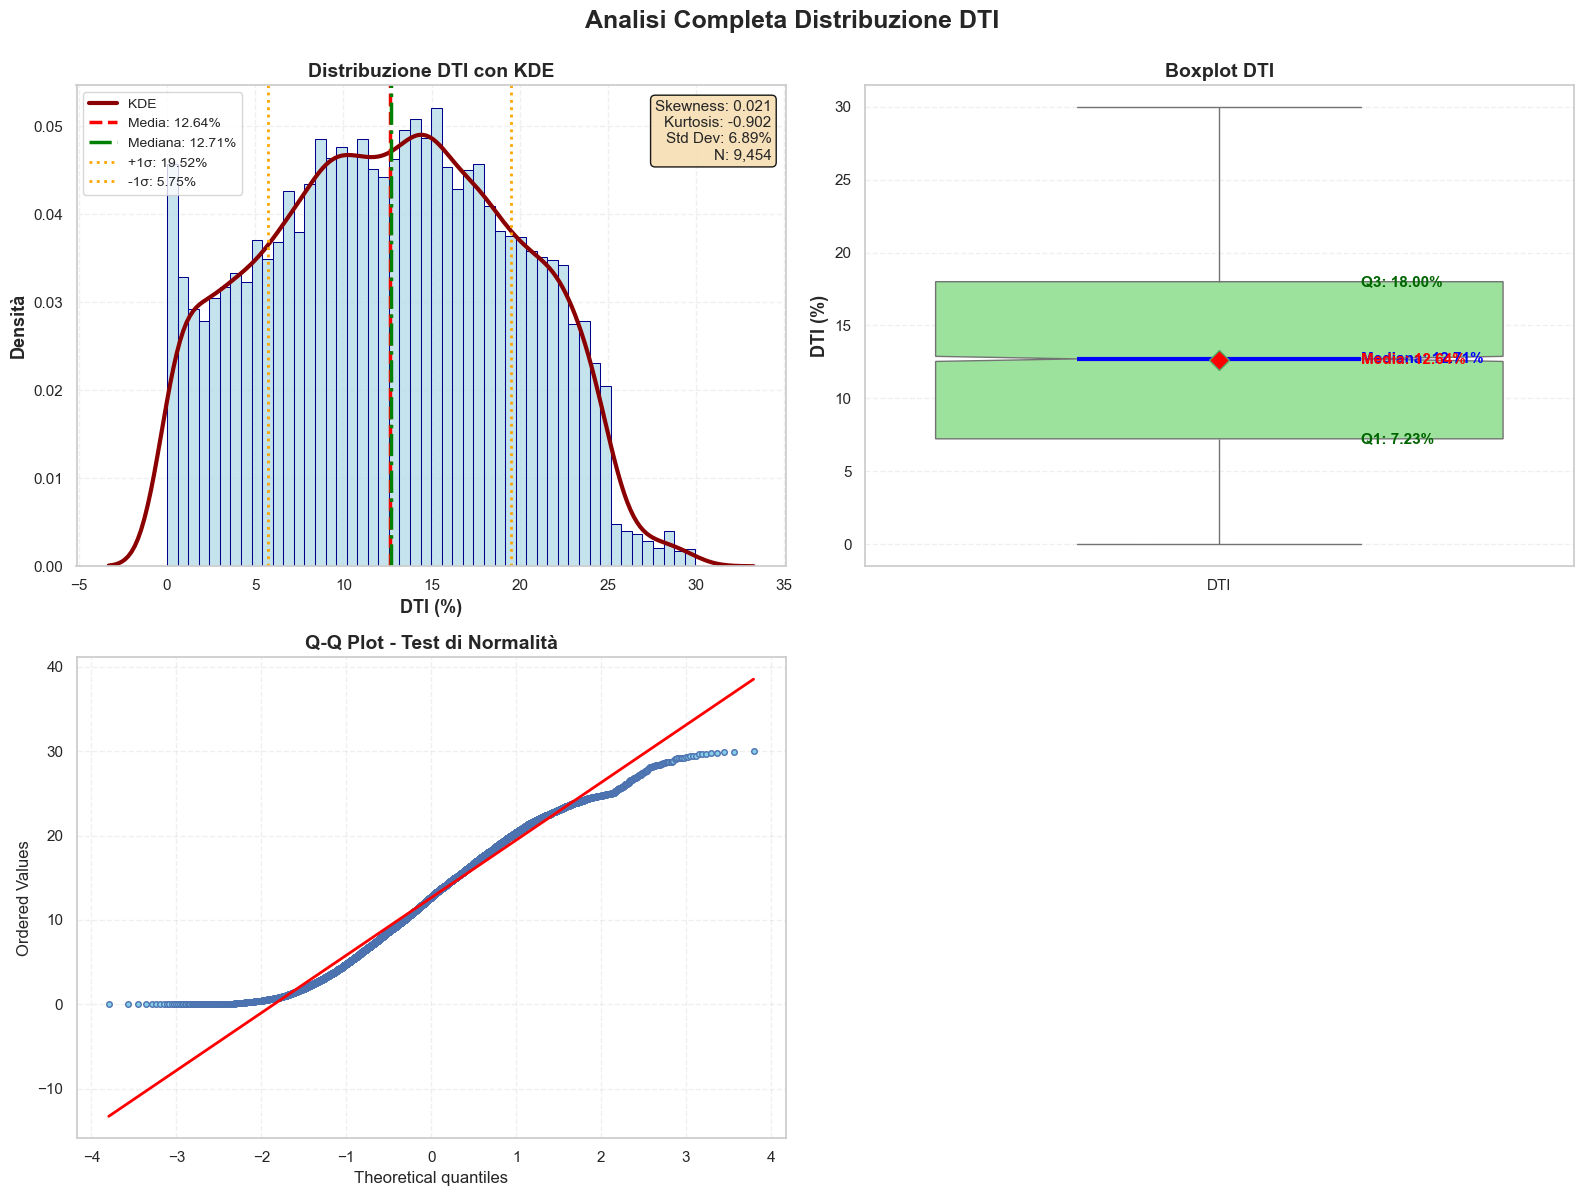

                    STATISTICHE DESCRITTIVE DTI
Media:              12.64%
Mediana:            12.71%
Dev. Standard:      6.89%
Skewness:           0.021
Kurtosis:           -0.902
DTI = 0:            85 (0.8991%)


In [43]:

from scipy import stats as sp_stats

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Analisi Completa Distribuzione DTI', fontsize=18, fontweight='bold', y=0.995)

vals_dti = data["dti"].dropna()
mean_dti = vals_dti.mean()
median_dti = vals_dti.median()
std_dti = vals_dti.std()
skew_dti = vals_dti.skew()
kurt_dti = vals_dti.kurtosis()

sns.histplot(vals_dti, bins=50, color='lightblue', edgecolor='darkblue',
             alpha=0.7, stat='density', kde=False, ax=axes[0, 0])
sns.kdeplot(vals_dti, color='darkred', linewidth=3, ax=axes[0, 0], label='KDE')

axes[0, 0].axvline(mean_dti, color='red', linestyle='--', linewidth=2.5, label=f'Media: {mean_dti:.2f}%')
axes[0, 0].axvline(median_dti, color='green', linestyle='-.', linewidth=2.5, label=f'Mediana: {median_dti:.2f}%')
axes[0, 0].axvline(mean_dti + std_dti, color='orange', linestyle=':', linewidth=2, label=f'+1σ: {(mean_dti + std_dti):.2f}%')
axes[0, 0].axvline(mean_dti - std_dti, color='orange', linestyle=':', linewidth=2, label=f'-1σ: {(mean_dti - std_dti):.2f}%')

textstr = f'Skewness: {skew_dti:.3f}\nKurtosis: {kurt_dti:.3f}\nStd Dev: {std_dti:.2f}%\nN: {len(vals_dti):,}'
axes[0, 0].text(0.98, 0.97, textstr, transform=axes[0, 0].transAxes, fontsize=11,
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9, edgecolor='black'))

axes[0, 0].set_xlabel('DTI (%)', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Densità', fontsize=13, fontweight='bold')
axes[0, 0].set_title('Distribuzione DTI con KDE', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=10, loc='upper left')
axes[0, 0].grid(True, alpha=0.3, linestyle='--')

bp = sns.boxplot(y=vals_dti, color='lightgreen', ax=axes[0, 1],
                 notch=True, showmeans=True, showcaps=True,
                 meanprops=dict(marker='D', markerfacecolor='red', markersize=10),
                 medianprops=dict(color='blue', linewidth=3))

q1_dti = vals_dti.quantile(0.25)
q3_dti = vals_dti.quantile(0.75)

axes[0, 1].text(0.2, q1_dti, f'Q1: {q1_dti:.2f}%', fontsize=11, va='center', fontweight='bold', color='darkgreen')
axes[0, 1].text(0.2, median_dti, f'Mediana: {median_dti:.2f}%', fontsize=11, va='center', fontweight='bold', color='blue')
axes[0, 1].text(0.2, q3_dti, f'Q3: {q3_dti:.2f}%', fontsize=11, va='center', fontweight='bold', color='darkgreen')
axes[0, 1].text(0.2, mean_dti, f'Media: {mean_dti:.2f}%', fontsize=11, va='center', fontweight='bold', color='red')

axes[0, 1].set_ylabel('DTI (%)', fontsize=13, fontweight='bold')
axes[0, 1].set_title('Boxplot DTI', fontsize=14, fontweight='bold')
axes[0, 1].set_xticks([0])
axes[0, 1].set_xticklabels(['DTI'])
axes[0, 1].grid(True, alpha=0.3, axis='y', linestyle='--')

sp_stats.probplot(vals_dti, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot - Test di Normalità', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, linestyle='--')
axes[1, 0].get_lines()[0].set_markerfacecolor('skyblue')
axes[1, 0].get_lines()[0].set_markersize(4)
axes[1, 0].get_lines()[1].set_color('red')
axes[1, 0].get_lines()[1].set_linewidth(2)

axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print("="*70)
print(" "*20 + "STATISTICHE DESCRITTIVE DTI")
print("="*70)
print(f"Media:              {mean_dti:.2f}%")
print(f"Mediana:            {median_dti:.2f}%")
print(f"Dev. Standard:      {std_dti:.2f}%")
print(f"Skewness:           {skew_dti:.3f}")
print(f"Kurtosis:           {kurt_dti:.3f}")
print(f"DTI = 0:            {len(data[data['dti'] == 0])} ({(len(data[data['dti'] == 0]) / len(data)) * 100:.4f}%)")
print("="*70)

### Quanti clienti hanno DTI pari a zero?

Un DTI uguale a zero significa che il cliente non ha debiti mensili. Se la percentuale fosse troppo alta, potrebbe indicare un problema nei dati.

In [44]:
print(f"Clienti con DTI = 0: {len(data[data['dti'] == 0])}")
print(f"Percentuale: {(len(data[data['dti'] == 0]) / len(data)) * 100:.2f}%")



Clienti con DTI = 0: 85
Percentuale: 0.90%


<a id="revolving-util"></a>
## Quanto credito stanno usando i clienti?

Il revolving balance è il debito effettivo su carte di credito e linee di credito. Il revolving utilization indica che percentuale del credito disponibile il cliente sta effettivamente usando.

Formula: Revolving Util = (Saldo / Limite di Credito) x 100

Un utilizzo alto (es. 80%) indica che il cliente sta usando quasi tutto il credito disponibile, segnale di potenziale stress finanziario.

### Distribuzione del Revolving Utilization

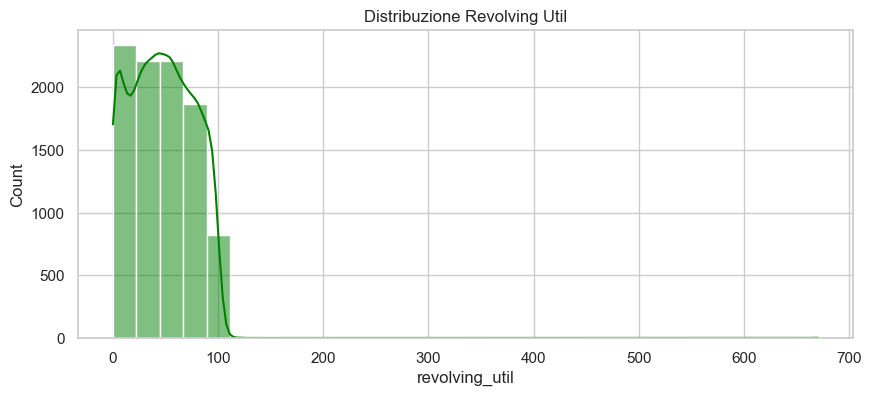

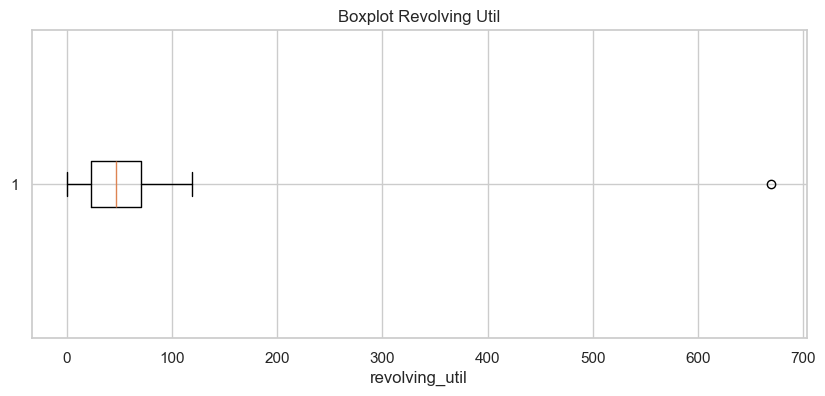

STATISTICHE DESCRITTIVE:

count    9454.000000
mean       46.887220
std        29.686746
min         0.000000
25%        22.700000
50%        46.300000
75%        70.900000
max       670.000000
Name: revolving_util, dtype: float64


In [45]:
plt.figure(figsize=(10,4))
sns.histplot(data['revolving_util'], kde=True, bins=30, color='green')
plt.title('Distribuzione Revolving Util')

plt.figure(figsize=(10,4))
plt.boxplot(data['revolving_util'], vert=False)
plt.title('Boxplot Revolving Util')
plt.xlabel('revolving_util')

plt.show()

print('STATISTICHE DESCRITTIVE:\n')
print(data['revolving_util'].describe())

Il valore massimo di 670% e chiaramente un errore. L'utilizzo del credito non dovrebbe mai superare il 100% se non in casi eccezionali di superamento del limite. Questo outlier va rimosso.

In [46]:
Q1 = data['revolving_util'].quantile(0.25)
Q3 = data['revolving_util'].quantile(0.75)
IQR = Q3 - Q1

lowerB_r_u = Q1 - 1.5 * IQR
upperB_r_u = Q3 + 1.5 * IQR

print(f'Limite Inferiore: {lowerB_r_u: .2f}')
print(f'Limite Superiore: {upperB_r_u: .2f}')

lower_outliers = data[data['revolving_util'] < lowerB_r_u]

# Filtrare gli upper outliers
upper_outliers = data[data['revolving_util'] > upperB_r_u]

print("Numero di lower outliers:", len(lower_outliers))
print("Numero di upper outliers:", len(upper_outliers))


data= data[(data['revolving_util'] >= lowerB_r_u) & (data['revolving_util'] <= upperB_r_u)]
print(f'DIMENSIONE DATASET PULITO (SENZA OUTLIERS) : {data.shape[0]} righe')

Limite Inferiore: -49.60
Limite Superiore:  143.20
Numero di lower outliers: 0
Numero di upper outliers: 1
DIMENSIONE DATASET PULITO (SENZA OUTLIERS) : 9453 righe


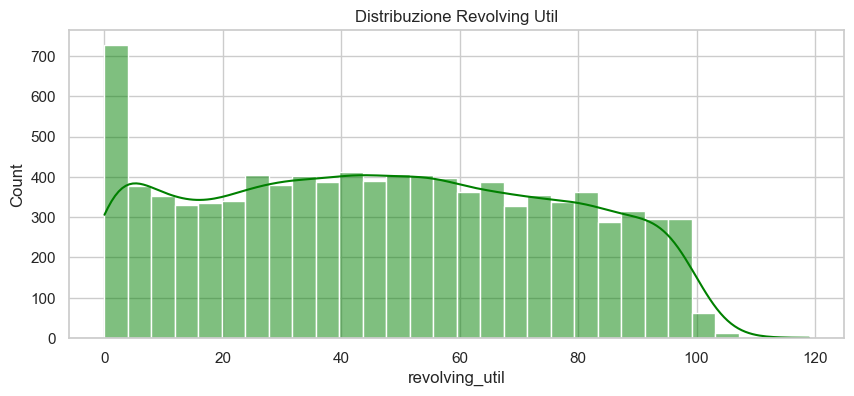

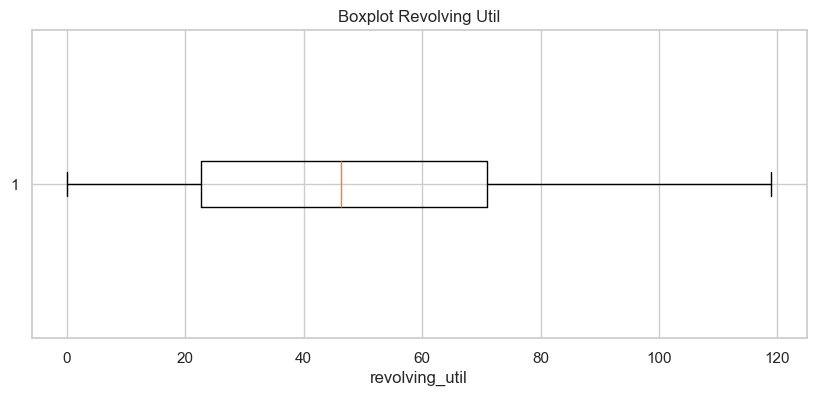

STATISTICHE DESCRITTIVE:

count    9453.000000
mean       46.821303
std        28.988166
min         0.000000
25%        22.700000
50%        46.300000
75%        70.900000
max       119.000000
Name: revolving_util, dtype: float64


In [47]:
plt.figure(figsize=(10,4))
sns.histplot(data['revolving_util'], kde=True, bins=30, color='green')
plt.title('Distribuzione Revolving Util')

plt.figure(figsize=(10,4))
plt.boxplot(data['revolving_util'], vert=False)
plt.title('Boxplot Revolving Util')
plt.xlabel('revolving_util')

plt.show()

print('STATISTICHE DESCRITTIVE:\n')
print(data['revolving_util'].describe())

Dopo la pulizia, il valore massimo di 119% è molto più ragionevole. Indica un cliente che ha superato leggermente il proprio limite di credito, situazione problematica ma plausibile.

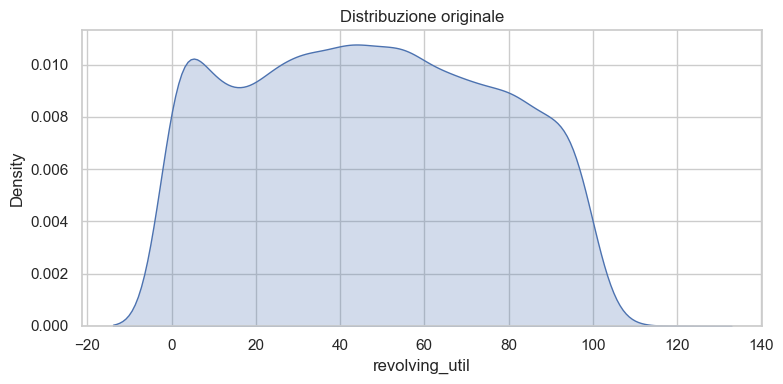


REVOLVING_UTIL
Asimmetria_Skewness: 0.06 | Kurtosis: -1.12
0.0


In [48]:
sns.set_theme(style="whitegrid")

skew = data['revolving_util'].skew()
kurt = data['revolving_util'].kurt()


fig, axes = plt.subplots(1, 1, figsize=(8, 4))
sns.kdeplot(data['revolving_util'], ax = axes, fill=True)
axes.set_title('Distribuzione originale')


plt.tight_layout()
plt.show()

for col in ['revolving_util']:
    print(f"\n{col.upper()}")
    print(f"Asimmetria_Skewness: {data[col].skew():.2f} | Kurtosis: {data[col].kurt():.2f}")

print(data['revolving_util'].min())

### Analisi della Credit Policy

Una domanda interessante riguarda i clienti che non rispettano i criteri di credito stabiliti da LendingClub. La variabile `credit_policy` indica se il cliente soddisfa (1) o meno (0) i requisiti di sottoscrizione.

Distribuzione per Credit Policy:
NON rispetta criteri: 1799 clienti (19.0%)
Rispetta criteri: 7654 clienti (81.0%)


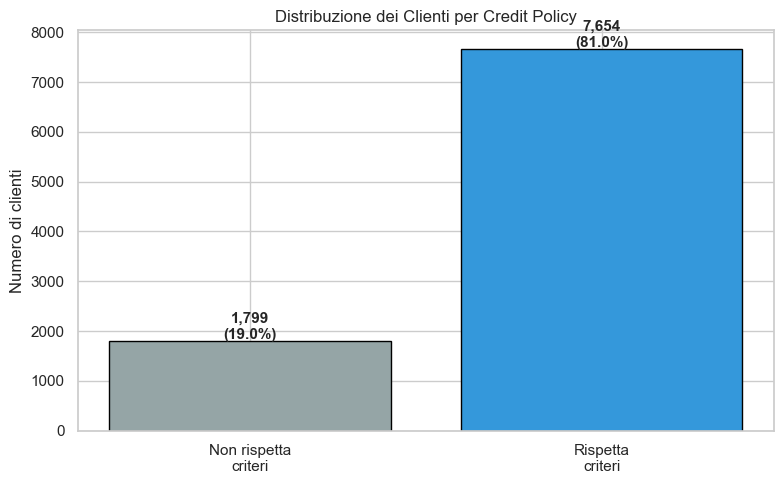

In [49]:

credit_policy_analysis = data['credit_policy'].value_counts().sort_index().to_frame()
credit_policy_analysis.columns = ['Totale']

print("Distribuzione per Credit Policy:")
print("=" * 55)
for idx in credit_policy_analysis.index:
    policy_label = "Rispetta criteri" if idx == 1 else "NON rispetta criteri"
    count = credit_policy_analysis.loc[idx, 'Totale']
    percentage = (count / len(data)) * 100
    print(f"{policy_label}: {int(count)} clienti ({percentage:.1f}%)")


fig, ax = plt.subplots(figsize=(8, 5))

labels_cp = ['Non rispetta\ncriteri', 'Rispetta\ncriteri']
totals = credit_policy_analysis['Totale'].values
colors_cp = ['#95a5a6', '#3498db']

bars = ax.bar(labels_cp, totals, color=colors_cp, edgecolor='black')
ax.set_ylabel('Numero di clienti')
ax.set_title('Distribuzione dei Clienti per Credit Policy')

# Aggiungi percentuali e numeri sulle barre
for bar, tot in zip(bars, totals):
    pct = (tot / len(data)) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{int(tot):,}\n({pct:.1f}%)', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


### Analisi dei Precedenti Negativi (Public Records)

La variabile `public_records` indica il numero di eventi negativi nel passato creditizio del cliente, come fallimenti, pignoramenti o sentenze sfavorevoli. La domanda e' semplice ma fondamentale: chi ha gia avuto problemi di credito in passato e' piu propenso a ripeterli?

Distribuzione dei Public Records:
public_records
0    8904
1     523
2      19
3       5
4       1
5       1
Name: count, dtype: Int64

Distribuzione dei clienti per numero di Public Records:
0 precedenti negativi: 8904 clienti (94.2%)
1 precedenti negativi: 523 clienti (5.5%)
2 precedenti negativi: 19 clienti (0.2%)
3 precedenti negativi: 5 clienti (0.1%)
4 precedenti negativi: 1 clienti (0.0%)
5 precedenti negativi: 1 clienti (0.0%)

Statistiche descrittive:
Media: 0.06
Mediana: 0
Max: 5
Clienti senza precedenti negativi: 8904 (94.2%)


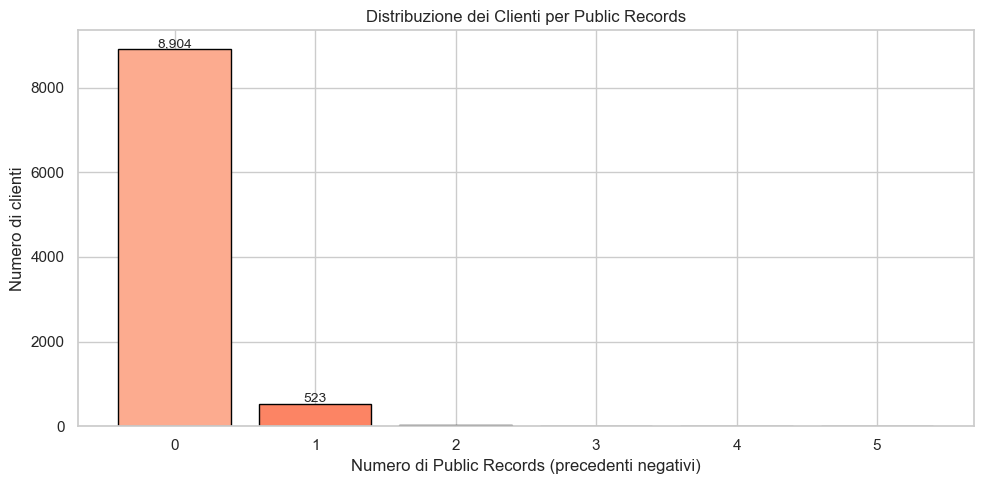


Interpretazione:
La grande maggioranza dei clienti (94.2%) non ha precedenti negativi.
La distribuzione è fortemente asimmetrica verso destra (right-skewed).


In [50]:
# Analisi Public Records
print("Distribuzione dei Public Records:")
print(data['public_records'].value_counts().sort_index())

# Analisi della distribuzione
pr_analysis = data.groupby('public_records').size().reset_index(name='Totale')
pr_analysis['Percentuale'] = (pr_analysis['Totale'] / len(data)) * 100

print("\nDistribuzione dei clienti per numero di Public Records:")
print("=" * 55)
for _, row in pr_analysis.iterrows():
    print(f"{int(row['public_records'])} precedenti negativi: {int(row['Totale'])} clienti ({row['Percentuale']:.1f}%)")

# Statistiche descrittive
print(f"\nStatistiche descrittive:")
print(f"Media: {data['public_records'].mean():.2f}")
print(f"Mediana: {data['public_records'].median():.0f}")
print(f"Max: {data['public_records'].max():.0f}")
no_records_pct = (data['public_records']==0).mean()*100
print(f"Clienti senza precedenti negativi: {(data['public_records']==0).sum()} ({no_records_pct:.1f}%)")

# Visualizzazione
fig, ax = plt.subplots(figsize=(10, 5))

colors_pr = plt.cm.Reds(np.linspace(0.3, 0.9, len(pr_analysis)))
bars = ax.bar(pr_analysis['public_records'].astype(str), pr_analysis['Totale'],
              color=colors_pr, edgecolor='black')
ax.set_xlabel('Numero di Public Records (precedenti negativi)')
ax.set_ylabel('Numero di clienti')
ax.set_title('Distribuzione dei Clienti per Public Records')

for bar, (_, row) in zip(bars, pr_analysis.iterrows()):
    if row['Totale'] > 50:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                     f'{int(row["Totale"]):,}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\nInterpretazione:")
print(f"La grande maggioranza dei clienti ({no_records_pct:.1f}%) non ha precedenti negativi.")
print(f"La distribuzione è fortemente asimmetrica verso destra (right-skewed).")

### Analisi dei Ritardi nei Pagamenti (Delinquencies)

Oltre ai precedenti "gravi" come i fallimenti, analizziamo i ritardi nei pagamenti degli ultimi 2 anni. La variabile `delinquencies_2y` cattura comportamenti meno gravi ma comunque rivelatori: un cliente che e' stato in ritardo con altri debiti potrebbe avere abitudini di pagamento poco affidabili.

Distribuzione delle delinquencies (ritardi di pagamento):
delinquencies_2y
0     8353
1      819
2      188
3       63
4       18
5        6
6        2
7        1
8        1
11       1
13       1
Name: count, dtype: Int64

Distribuzione dei clienti per numero di ritardi negli ultimi 2 anni:
0 ritardi: 8353 clienti (88.4%)
1 ritardi: 819 clienti (8.7%)
2 ritardi: 188 clienti (2.0%)
3+ ritardi: 93 clienti (1.0%)

Statistiche descrittive:
Media: 0.16
Mediana: 0
Max: 13
Clienti senza ritardi: 8353 (88.4%)


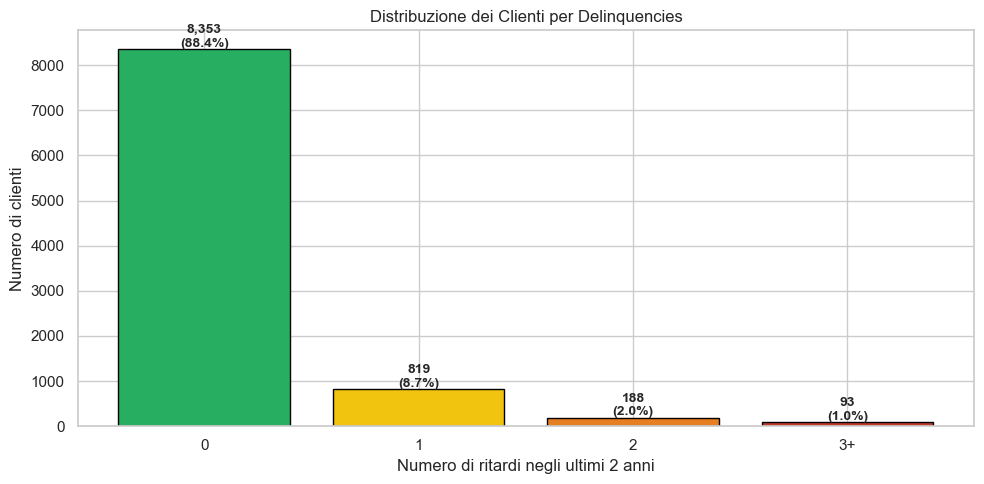


Interpretazione:
La maggioranza dei clienti (88.4%) non ha avuto ritardi negli ultimi 2 anni.
La distribuzione è fortemente asimmetrica verso destra (right-skewed).


In [51]:
# Analisi Delinquencies negli ultimi 2 anni
print("Distribuzione delle delinquencies (ritardi di pagamento):")
print(data['delinquencies_2y'].value_counts().sort_index().head(15))

# Raggruppiamo per semplicità: 0, 1, 2, 3+
data['delinq_group'] = pd.cut(data['delinquencies_2y'],
                               bins=[-1, 0, 1, 2, float('inf')],
                               labels=['0', '1', '2', '3+'])

delinq_analysis = data.groupby('delinq_group', observed=True).size().reset_index(name='Totale')
delinq_analysis['Percentuale'] = (delinq_analysis['Totale'] / len(data)) * 100

print("\nDistribuzione dei clienti per numero di ritardi negli ultimi 2 anni:")
print("=" * 55)
for _, row in delinq_analysis.iterrows():
    print(f"{row['delinq_group']} ritardi: {int(row['Totale'])} clienti ({row['Percentuale']:.1f}%)")

# Statistiche descrittive
print(f"\nStatistiche descrittive:")
print(f"Media: {data['delinquencies_2y'].mean():.2f}")
print(f"Mediana: {data['delinquencies_2y'].median():.0f}")
print(f"Max: {data['delinquencies_2y'].max():.0f}")
print(f"Clienti senza ritardi: {(data['delinquencies_2y']==0).sum()} ({(data['delinquencies_2y']==0).mean()*100:.1f}%)")

# Visualizzazione
fig, ax = plt.subplots(figsize=(10, 5))

colors_delinq = ['#27ae60', '#f1c40f', '#e67e22', '#c0392b']
bars = ax.bar(delinq_analysis['delinq_group'].astype(str), delinq_analysis['Totale'],
                   color=colors_delinq, edgecolor='black')
ax.set_xlabel('Numero di ritardi negli ultimi 2 anni')
ax.set_ylabel('Numero di clienti')
ax.set_title('Distribuzione dei Clienti per Delinquencies')

for bar, (_, row) in zip(bars, delinq_analysis.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{int(row["Totale"]):,}\n({row["Percentuale"]:.1f}%)', 
                 ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Pulizia della colonna temporanea
data.drop('delinq_group', axis=1, inplace=True)

print("\nInterpretazione:")
no_delinq_pct = (data['delinquencies_2y']==0).mean()*100
print(f"La maggioranza dei clienti ({no_delinq_pct:.1f}%) non ha avuto ritardi negli ultimi 2 anni.")
print(f"La distribuzione è fortemente asimmetrica verso destra (right-skewed).")

# Parte 3 - Verifica Statistica

Prima di procedere con l'analisi multivariata, applichiamo test statistici per validare le osservazioni fatte finora. I test ci permettono di capire se le differenze osservate sono significative o semplicemente dovute al caso.

In questa sezione applichiamo:
- **Test di normalita**: per verificare se le variabili seguono una distribuzione normale
- **T-test**: per confrontare le medie tra chi ha ripagato e chi no
- **Test Chi-quadrato**: per verificare associazioni tra variabili categoriche

## I dati sono normali?

Per molti test statistici serve che i dati seguano una distribuzione normale. Usiamo il test di Shapiro-Wilk per verificarlo. Se il p-value e minore di 0.05, rifiutiamo l'ipotesi di normalita.

In [52]:
from scipy import stats

variabili_da_testare = ['interest_rate', 'fico_score', 'dti', 'log_annual_income', 'installment']

print("TEST DI NORMALITA' (Shapiro-Wilk)")
print("=" * 60)
print(f"{'Variabile':<25} {'Statistica W':<15} {'P-value':<15} {'Normale?'}")
print("-" * 60)

for var in variabili_da_testare:
    campione = data[var].dropna().sample(min(5000, len(data)), random_state=42)
    stat, p_value = stats.shapiro(campione)
    normale = "Si" if p_value > 0.05 else "No"
    print(f"{var:<25} {stat:<15.4f} {p_value:<15.4e} {normale}")

print("=" * 60)

TEST DI NORMALITA' (Shapiro-Wilk)
Variabile                 Statistica W    P-value         Normale?
------------------------------------------------------------
interest_rate             0.9876          1.5499e-20      No
fico_score                0.9735          1.8242e-29      No
dti                       0.9788          1.0578e-26      No
log_annual_income         0.9881          4.2805e-20      No
installment               0.9251          1.7865e-44      No


**Risposta**: Nessuna delle variabili segue una distribuzione perfettamente normale. Tuttavia, con campioni grandi come il nostro, il Teorema del Limite Centrale garantisce che le medie campionarie sono comunque approssimativamente normali. Possiamo procedere con i test parametrici.

## Chi non ripaga e diverso da chi ripaga?

**Domanda**: Esistono differenze significative nelle caratteristiche dei clienti che hanno ripagato rispetto a quelli che non l'hanno fatto?

Usiamo il t-test per campioni indipendenti. L'ipotesi nulla e che le medie dei due gruppi siano uguali. Se il p-value e minore di 0.05, la differenza e statisticamente significativa.

In [53]:
# Separiamo i due gruppi
ripagato = data[data['not_fully_paid'] == 0]
non_ripagato = data[data['not_fully_paid'] == 1]

print(f"Clienti che hanno ripagato: {len(ripagato)}")
print(f"Clienti che NON hanno ripagato: {len(non_ripagato)}")
print()

# T-test sulle variabili principali
variabili_confronto = ['interest_rate', 'fico_score', 'dti', 'log_annual_income', 'installment', 'revolving_util']

print("T-TEST: CONFRONTO TRA GRUPPI")
print("=" * 80)
print(f"{'Variabile':<20} {'Media Ripagato':<15} {'Media Non Rip.':<15} {'t-stat':<12} {'p-value':<12} {'Signif.?'}")
print("-" * 80)

for var in variabili_confronto:
    media_rip = ripagato[var].mean()
    media_non_rip = non_ripagato[var].mean()

    # T-test per campioni indipendenti
    t_stat, p_value = stats.ttest_ind(ripagato[var].dropna(), non_ripagato[var].dropna())

    signif = "Si ***" if p_value < 0.001 else ("Si **" if p_value < 0.01 else ("Si *" if p_value < 0.05 else "No"))

    print(f"{var:<20} {media_rip:<15.2f} {media_non_rip:<15.2f} {t_stat:<12.2f} {p_value:<12.4e} {signif}")

print("=" * 80)
print("\nLegenda: *** p<0.001, ** p<0.01, * p<0.05")

Clienti che hanno ripagato: 7953
Clienti che NON hanno ripagato: 1500

T-TEST: CONFRONTO TRA GRUPPI
Variabile            Media Ripagato  Media Non Rip.  t-stat       p-value      Signif.?
--------------------------------------------------------------------------------
interest_rate        12.05           13.17           -15.42       4.9850e-53   Si ***
fico_score           713.46          698.08          14.56        1.6262e-47   Si ***
dti                  12.52           13.24           -3.71        2.1109e-04   Si ***
log_annual_income    10.94           10.89           2.92         3.4582e-03   Si **
installment          314.76          342.85          -4.85        1.2683e-06   Si ***
revolving_util       45.79           52.26           -7.95        2.0037e-15   Si ***

Legenda: *** p<0.001, ** p<0.01, * p<0.05


**Risposta**: I risultati confermano le intuizioni dell'analisi esplorativa:
- Il tasso di interesse e il FICO score mostrano differenze molto significative tra i due gruppi
- Chi non ripaga ha tassi piu alti e punteggi FICO piu bassi
- Il DTI e leggermente piu alto per chi non ripaga
- Il reddito, sorprendentemente, non sembra essere un fattore discriminante forte

Queste differenze sono statisticamente significative e ci indicano quali variabili sono piu utili per prevedere il default.

## Lo scopo del prestito influenza il rischio?

**Domanda**: Esiste un'associazione tra la motivazione del prestito e la probabilita di default?

Il test chi-quadrato verifica se due variabili categoriche sono associate. L'ipotesi nulla e che siano indipendenti.

In [54]:
# Tabella di contingenza: purpose vs not_fully_paid
contingency_table = pd.crosstab(data['purpose'], data['not_fully_paid'])
print("TABELLA DI CONTINGENZA: Purpose vs Not Fully Paid")
print(contingency_table)
print()

# Test chi-quadrato
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print("TEST CHI-QUADRATO")
print("=" * 50)
print(f"Chi-quadrato: {chi2:.4f}")
print(f"Gradi di libertà: {dof}")
print(f"P-value: {p_value:.4e}")

# V di Cramer - misura della forza dell'associazione
n = contingency_table.sum().sum()
min_dim = min(contingency_table.shape[0] - 1, contingency_table.shape[1] - 1)
cramers_v = np.sqrt(chi2 / (n * min_dim))
print(f"V di Cramer: {cramers_v:.4f}")
print("=" * 50)

print("\nInterpretazione V di Cramer:")
print("  0.00-0.10: Associazione trascurabile")
print("  0.10-0.20: Associazione debole")
print("  0.20-0.40: Associazione moderata")
print("  0.40-0.60: Associazione relativamente forte")
print("  0.60-1.00: Associazione forte")

if p_value < 0.05:
    print(f"\nConclusione: Esiste un'associazione significativa (p < 0.05)")
    print(f"tra lo scopo del prestito e il mancato rimborso.")
    print(f"La forza dell'associazione e' {cramers_v:.3f} (V di Cramer).")
else:
    print("\nConclusione: Non c'è evidenza di associazione tra")
    print("lo scopo del prestito e il mancato rimborso.")

TABELLA DI CONTINGENZA: Purpose vs Not Fully Paid
not_fully_paid         0    1
purpose                      
all_other           1907  376
credit_card         1111  145
debt_consolidation  3333  595
educational          270   69
home_improvement     519  104
major_purchase       381   49
small_business       432  162

TEST CHI-QUADRATO
Chi-quadrato: 89.4754
Gradi di libertà: 6
P-value: 3.8939e-17
V di Cramer: 0.0973

Interpretazione V di Cramer:
  0.00-0.10: Associazione trascurabile
  0.10-0.20: Associazione debole
  0.20-0.40: Associazione moderata
  0.40-0.60: Associazione relativamente forte
  0.60-1.00: Associazione forte

Conclusione: Esiste un'associazione significativa (p < 0.05)
tra lo scopo del prestito e il mancato rimborso.
La forza dell'associazione e' 0.097 (V di Cramer).


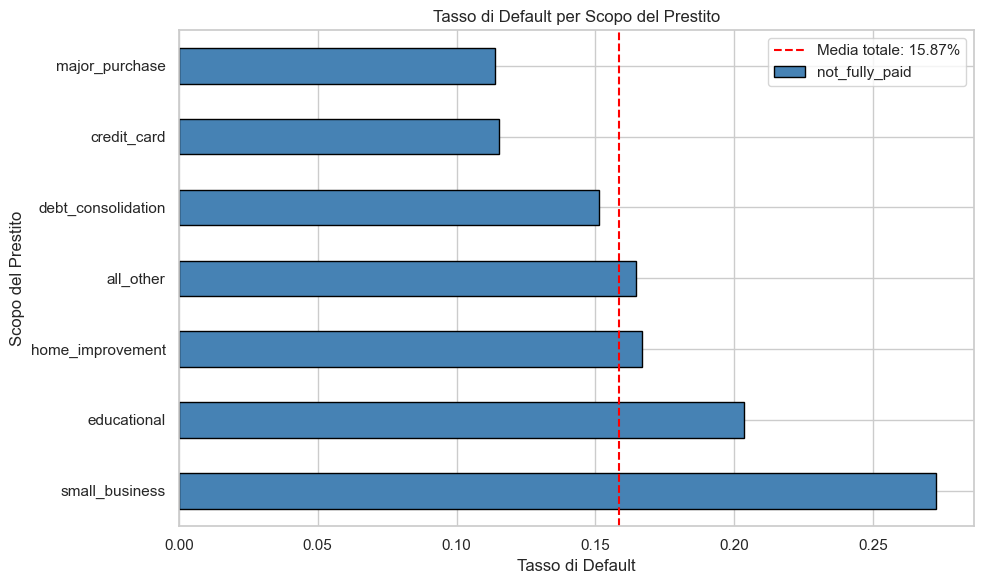


Tasso di default per scopo:
  small_business: 27.27%
  educational: 20.35%
  home_improvement: 16.69%
  all_other: 16.47%
  debt_consolidation: 15.15%
  credit_card: 11.54%
  major_purchase: 11.40%


In [55]:
# Calcoliamo il tasso di default per ogni scopo
default_rate_by_purpose = data.groupby('purpose')['not_fully_paid'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
default_rate_by_purpose.plot(kind='barh', color='steelblue', edgecolor='black')
plt.xlabel('Tasso di Default')
plt.ylabel('Scopo del Prestito')
plt.title('Tasso di Default per Scopo del Prestito')
plt.axvline(x=data['not_fully_paid'].mean(), color='red', linestyle='--', label=f'Media totale: {data["not_fully_paid"].mean():.2%}')
plt.legend()
plt.tight_layout()
plt.show()

print("\nTasso di default per scopo:")
for purpose, rate in default_rate_by_purpose.items():
    print(f"  {purpose}: {rate:.2%}")

**Risposta**: Il grafico mostra chiaramente che alcuni scopi sono piu rischiosi di altri. I prestiti per piccole imprese hanno il tasso di default piu alto, mentre quelli per matrimoni o carte di credito tendono ad essere piu sicuri. Questa informazione e utile per la valutazione del rischio.

# Parte 4 - Analisi Multivariata

Le variabili non agiscono in isolamento. In questa sezione studiamo le relazioni tra di esse usando correlazioni, covarianze e modelli di regressione.


# Matrice di correlazione generale

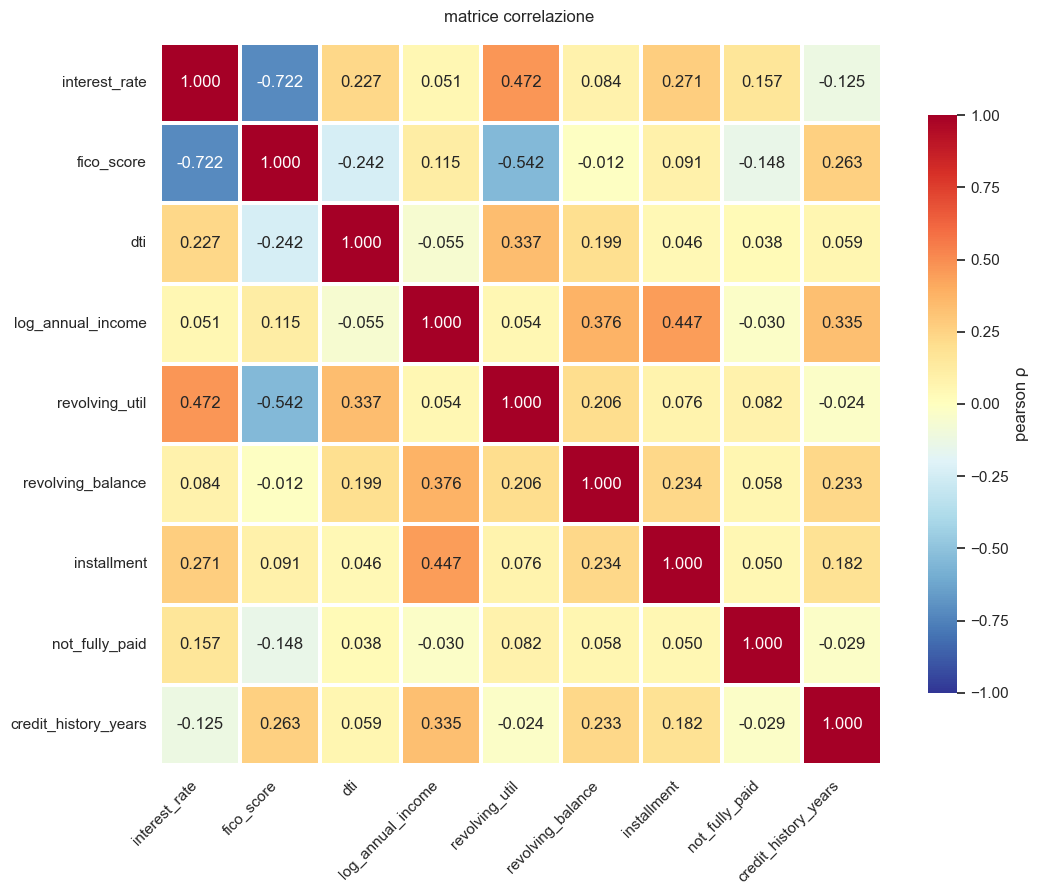

In [56]:
correlation_vars_int = ['interest_rate', 'fico_score', 'dti', 'log_annual_income',
                        'revolving_util', 'revolving_balance', 'installment', 'not_fully_paid', 'credit_history_years']

corr_matrix_int = data[correlation_vars_int].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_matrix_int, annot=True, fmt='.3f', cmap='RdYlBu_r', center=0,
            square=True, linewidths=1.5, cbar_kws={"shrink": 0.8, "label": "pearson ρ"},
            vmin=-1, vmax=1, ax=ax)
plt.title('matrice correlazione ', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Il DTI dipende solo da Annual income e installment?

Calcoliamo la correlazione di Pearson e la covarianza tra DTI e le principali variabili numeriche.

In [57]:
dti_vars = ['log_annual_income', 'installment']

print("╔" + "="*78 + "╗")
print("║" + " ASSOCIAZIONE DTI CON ALTRE VARIABILI".center(78) + "║")
print("╠" + "="*78 + "╣")
print(f"║ {'Variabile':<30} {'Pearson ρ':>20} {'Covariance':>20} ║")
print("╠" + "="*78 + "╣")

dti_correlations = {}
dti_covariances = {}
for var in dti_vars:
    dti_correlations[var] = data['dti'].corr(data[var])
    dti_covariances[var] = data['dti'].cov(data[var])
    print(f"║ {var:<30} {dti_correlations[var]:>20.4f} {dti_covariances[var]:>20.2f} ║")

print("╚" + "="*78 + "╝")

sorted_corr = sorted(dti_correlations.items(), key=lambda x: abs(x[1]), reverse=True)
print(f"\nCorrelazioni con DTI:")
for i, (var, corr) in enumerate(sorted_corr[:3], 1):
    direction = "positiva" if corr > 0 else "negativa"
    print(f"   {i}. {var}: ρ = {corr:.4f} (correlazione {direction})")

╔==============================================================================╗
║                     ASSOCIAZIONE DTI CON ALTRE VARIABILI                     ║
╠==============================================================================╣
║ Variabile                                 Pearson ρ           Covariance ║
╠==============================================================================╣
║ log_annual_income                           -0.0548                -0.23 ║
║ installment                                  0.0456                64.81 ║
╚==============================================================================╝

Correlazioni con DTI:
   1. log_annual_income: ρ = -0.0548 (correlazione negativa)
   2. installment: ρ = 0.0456 (correlazione positiva)


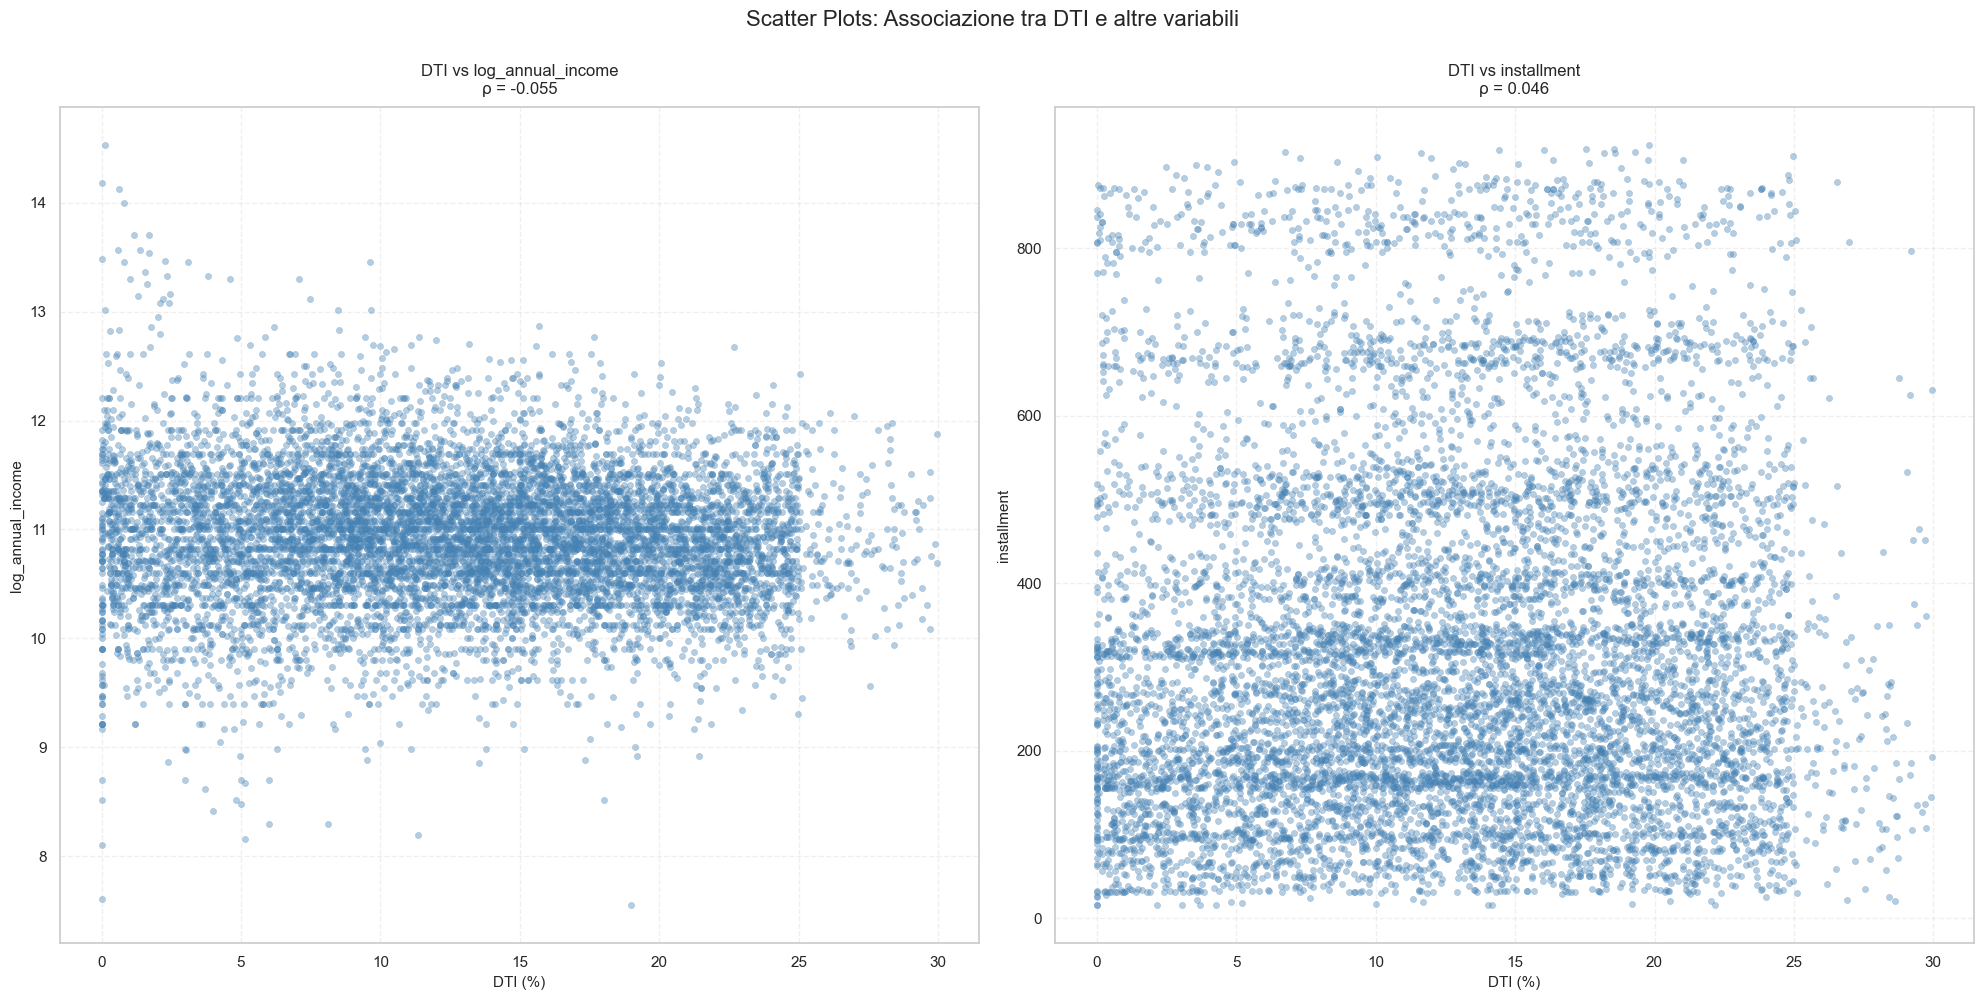

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
axes = axes.flatten()

for idx, var in enumerate(dti_vars):
    sns.scatterplot(data=data, x='dti', y=var, alpha=0.4, s=20,
                   color='steelblue', edgecolor=None, ax=axes[idx])

    axes[idx].set_xlabel('DTI (%)', fontsize=11)
    axes[idx].set_ylabel(var, fontsize=11)
    axes[idx].set_title(f'DTI vs {var}\nρ = {dti_correlations[var]:.3f}',
                       fontsize=12, pad=10)
    axes[idx].grid(True, alpha=0.3, linestyle='--')



plt.suptitle('Scatter Plots: Associazione tra DTI e altre variabili',
             fontsize=16, y=0.998)
plt.tight_layout()
plt.show()

In [59]:
from sklearn.linear_model import LinearRegression


dti_vars = ['log_annual_income', 'installment']

print("╔" + "="*78 + "╗")
print("║" + " ASSOCIAZIONE DTI CON ALTRE VARIABILI".center(78) + "║")
print("╠" + "="*78 + "╣")
print(f"║ {'Variabile':<30} {'Pearson ρ':>20} {'Covariance':>20} ║")
print("╠" + "="*78 + "╣")

dti_correlations = {}
dti_covariances = {}
for var in dti_vars:
    dti_correlations[var] = data['dti'].corr(data[var])
    dti_covariances[var] = data['dti'].cov(data[var])
    print(f"║ {var:<30} {dti_correlations[var]:>20.4f} {dti_covariances[var]:>20.2f} ║")

print("╚" + "="*78 + "╝")

# Regressione lineare per calcolare R²
X_dti = data[['log_annual_income', 'installment']].dropna()
y_dti = data.loc[X_dti.index, 'dti']

lr_dti = LinearRegression()
lr_dti.fit(X_dti, y_dti)
r2_dti = lr_dti.score(X_dti, y_dti)

print(f"\nREGRESSIONE LINEARE: DTI ~ log_annual_income + installment")
print(f"   R² = {r2_dti:.4f} → Solo il {r2_dti*100:.2f}% della varianza di DTI è spiegata")
print(f"\nConclusione: annual_income e installment quasi NON spiegano il DTI")
print(f"   perché il DTI include TUTTI i debiti mensili, non solo l'installment LendingClub.")

╔==============================================================================╗
║                     ASSOCIAZIONE DTI CON ALTRE VARIABILI                     ║
╠==============================================================================╣
║ Variabile                                 Pearson ρ           Covariance ║
╠==============================================================================╣
║ log_annual_income                           -0.0548                -0.23 ║
║ installment                                  0.0456                64.81 ║
╚==============================================================================╝

REGRESSIONE LINEARE: DTI ~ log_annual_income + installment
   R² = 0.0092 → Solo il 0.92% della varianza di DTI è spiegata

Conclusione: annual_income e installment quasi NON spiegano il DTI
   perché il DTI include TUTTI i debiti mensili, non solo l'installment LendingClub.


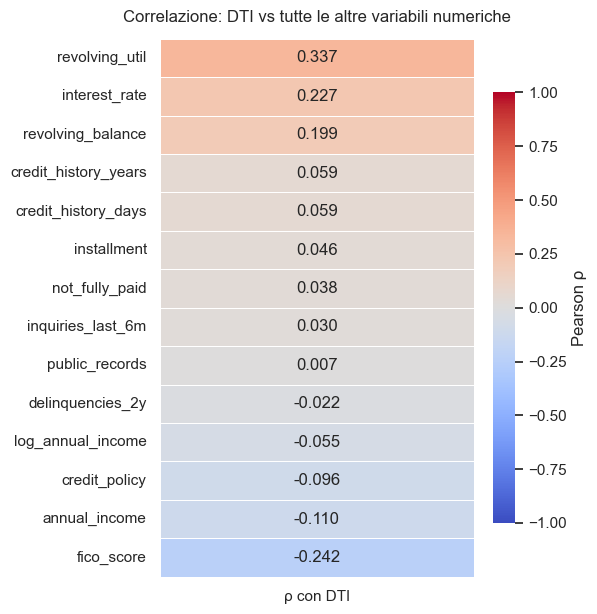

,ρ con DTI
revolving_util,0.336986
interest_rate,0.226794
revolving_balance,0.198614
credit_history_years,0.059476
credit_history_days,0.059476
installment,0.045649
not_fully_paid,0.038102
inquiries_last_6m,0.030324
public_records,0.006551
delinquencies_2y,-0.022180


In [60]:
# Matrice (1-colonna) delle correlazioni: solo DTI vs tutte le altre variabili numeriche
df_num = data.select_dtypes(include=[np.number]).copy()

# Escludi identificativi e verifica DTI
for col in ['customer_id']:
    if col in df_num.columns:
        df_num = df_num.drop(columns=col)

if 'dti' not in df_num.columns:
    raise ValueError("La colonna 'dti' non è presente o non è numerica.")


corr_dti = df_num.corr(method='pearson')['dti'].drop('dti').sort_values(ascending=False)


corr_df = corr_dti.to_frame(name='ρ con DTI')

# Heatmap verticale
n = len(corr_df)
fig_h = min(max(0.45 * n, 5), 24)
fig, ax = plt.subplots(figsize=(6, fig_h))
sns.heatmap(
    corr_df,
    annot=True, fmt='.3f', cmap='coolwarm', center=0,
    vmin=-1, vmax=1, linewidths=0.5, cbar_kws={"shrink": 0.8, "label": "Pearson ρ"},
    ax=ax
)
ax.set_title("Correlazione: DTI vs tutte le altre variabili numeriche", pad=12)
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

display(corr_df.sort_values('ρ con DTI', ascending=False))

### Il DTI è diverso tra chi paga e chi no?

Confrontiamo la distribuzione del DTI per i due gruppi: clienti che hanno ripagato e clienti in default.

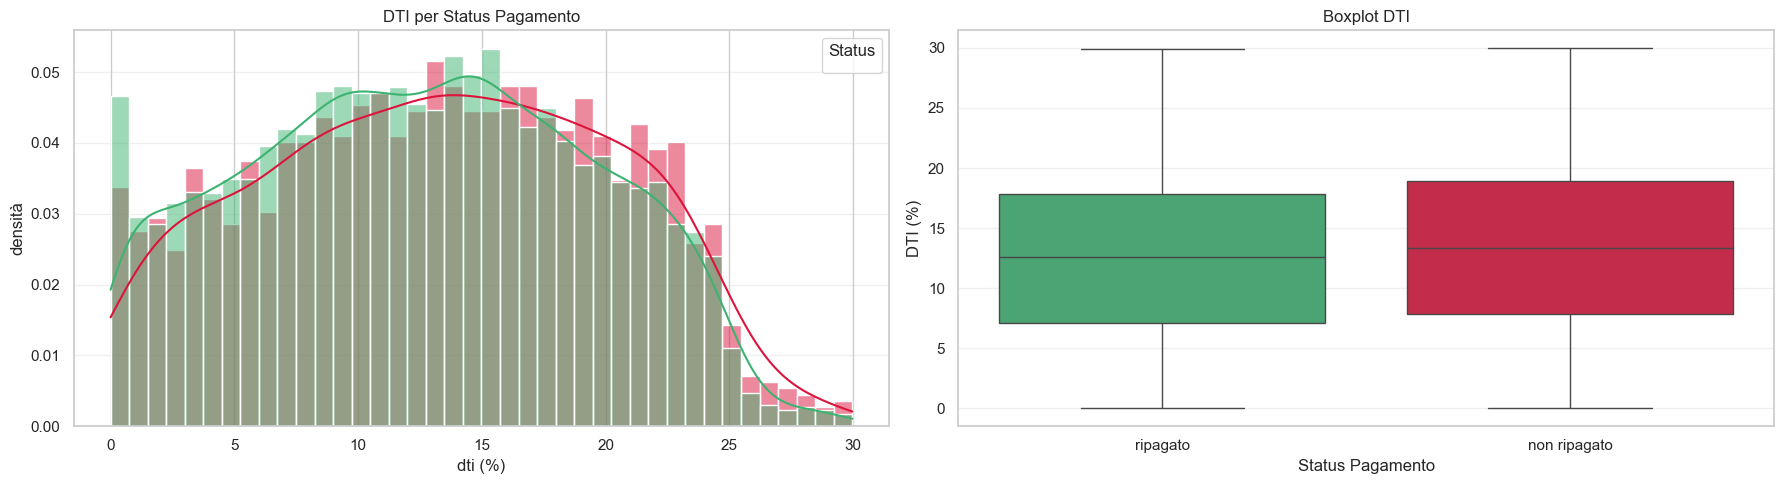


Statistiche DTI per Status Pagamento:

ripagato:
  media: 12.52%
  mediana: 12.58%
  std: 6.86%
  q1-q3: [7.13%, 17.82%]

non ripagato:
  media: 13.24%
  mediana: 13.38%
  std: 7.02%
  q1-q3: [7.83%, 18.91%]


In [61]:
data['not_fully_paid'] = data['not_fully_paid'].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.histplot(data=data, x='dti', hue='not_fully_paid', bins=40, kde=True,
             palette={'0': 'mediumseagreen', '1': 'crimson'}, alpha=0.5,
             ax=axes[0], stat='density', common_norm=False)
axes[0].set_xlabel('dti (%)')
axes[0].set_ylabel('densità')
axes[0].set_title('DTI per Status Pagamento')

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, ['ripagato', 'non ripagato'], title='Status')
axes[0].grid(True, alpha=0.3, axis='y')

sns.boxplot(data=data, x='not_fully_paid', y='dti',
            palette={'0': 'mediumseagreen', '1': 'crimson'}, ax=axes[1],
            hue='not_fully_paid', legend=False)
axes[1].set_xlabel('Status Pagamento')
axes[1].set_ylabel('DTI (%)')
axes[1].set_title('Boxplot DTI')
axes[1].set_xticks([0,1])
axes[1].set_xticklabels(['ripagato', 'non ripagato'])
axes[1].grid(True, alpha=0.3, axis='y')



plt.tight_layout()
plt.show()

print("\nStatistiche DTI per Status Pagamento:")
print("="*50)

for status in ['0', '1']:
    dti_group = data[data['not_fully_paid'] == status]['dti']
    status_name = "ripagato" if status == '0' else "non ripagato"
    print(f"\n{status_name}:")
    print(f"  media: {dti_group.mean():.2f}%")
    print(f"  mediana: {dti_group.median():.2f}%")
    print(f"  std: {dti_group.std():.2f}%")
    print(f"  q1-q3: [{dti_group.quantile(0.25):.2f}%, {dti_group.quantile(0.75):.2f}%]")

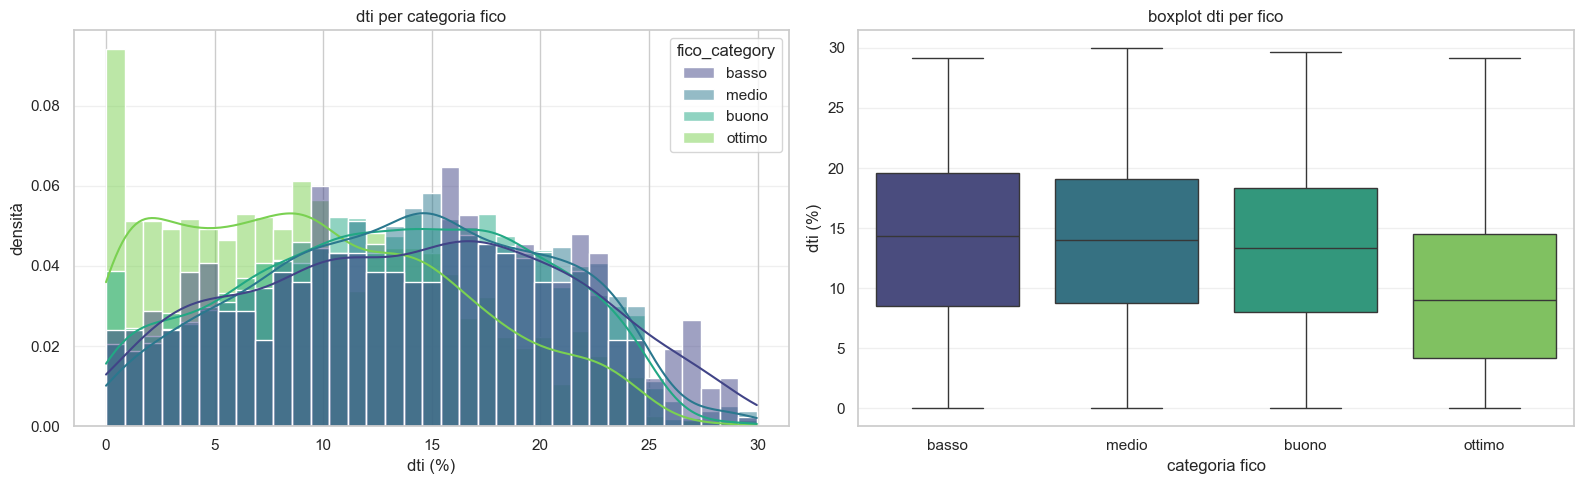

Statistiche dti per categoria fico:

fico basso:
  media: 14.00%
  mediana: 14.34%
  count: 487 prestiti (5.2%)

fico medio:
  media: 13.81%
  mediana: 14.02%
  count: 3653 prestiti (38.6%)

fico buono:
  media: 13.11%
  mediana: 13.38%
  count: 3103 prestiti (32.8%)

fico ottimo:
  media: 9.72%
  mediana: 9.02%
  count: 2210 prestiti (23.4%)


In [62]:
data['fico_category'] = pd.cut(
    data['fico_score'],
    bins=[600, 660, 700, 740, 850],
    labels=['basso', 'medio', 'buono', 'ottimo']
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(
    data=data,
    x='dti',
    hue='fico_category',
    bins=35,
    kde=True,
    palette='viridis',
    alpha=0.5,
    ax=axes[0],
    stat='density',
    common_norm=False
)
axes[0].set_xlabel('dti (%)')
axes[0].set_ylabel('densità')
axes[0].set_title('dti per categoria fico')
axes[0].grid(True, alpha=0.3, axis='y')

sns.boxplot(
    data=data,
    x='fico_category',
    y='dti',
    hue='fico_category',
    legend=False,
    palette='viridis',
    ax=axes[1]
)
axes[1].set_xlabel('categoria fico')
axes[1].set_ylabel('dti (%)')
axes[1].set_title('boxplot dti per fico')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("Statistiche dti per categoria fico:")
print("="*50)
for category in ['basso', 'medio', 'buono', 'ottimo']:
    dti_cat = data[data['fico_category'] == category]['dti'].dropna()
    print(f"\nfico {category}:")
    print(f"  media: {dti_cat.mean():.2f}%")
    print(f"  mediana: {dti_cat.median():.2f}%")
    print(f"  count: {len(dti_cat)} prestiti ({len(dti_cat)/len(data)*100:.1f}%)")


## Quali fattori sono piu correlati con il tasso di interesse applicato al prestito?


Analizziamo la correlazione tra interest rate e tutte le variabili disponibili.

In [63]:
interest_vars = ['fico_score', 'dti', 'log_annual_income', 'revolving_util',
                'credit_history_days', 'revolving_balance', 'installment', 'not_fully_paid']

print("associazione interest rate con altre variabili")
print("="*70)
print(f"{'variabile':<30} {'pearson ρ':>18} {'covariance':>18}")
print("-"*70)

interest_correlations = {}
interest_covariances = {}
for var in interest_vars:
    interest_correlations[var] = data['interest_rate'].corr(data[var])
    interest_covariances[var] = data['interest_rate'].cov(data[var])
    print(f"{var:<30} {interest_correlations[var]:>18.4f} {interest_covariances[var]:>18.2f}")

print("="*70)

sorted_corr_int = sorted(interest_correlations.items(), key=lambda x: abs(x[1]), reverse=True)
print(f"\ntop 3 correlazioni con interest rate:")
for i, (var, corr) in enumerate(sorted_corr_int[:3], 1):
    direction = "positiva" if corr > 0 else "negativa"
    print(f"  {i}. {var}: ρ = {corr:.4f} (correlazione {direction})")

associazione interest rate con altre variabili
variabile                               pearson ρ         covariance
----------------------------------------------------------------------
fico_score                                -0.7218             -71.75
dti                                        0.2268               4.09
log_annual_income                          0.0510               0.08
revolving_util                             0.4718              35.83
credit_history_days                       -0.1247            -815.35
revolving_balance                          0.0844            7102.19
installment                                0.2706             146.17
not_fully_paid                             0.1567               0.15

top 3 correlazioni con interest rate:
  1. fico_score: ρ = -0.7218 (correlazione negativa)
  2. revolving_util: ρ = 0.4718 (correlazione positiva)
  3. installment: ρ = 0.2706 (correlazione positiva)


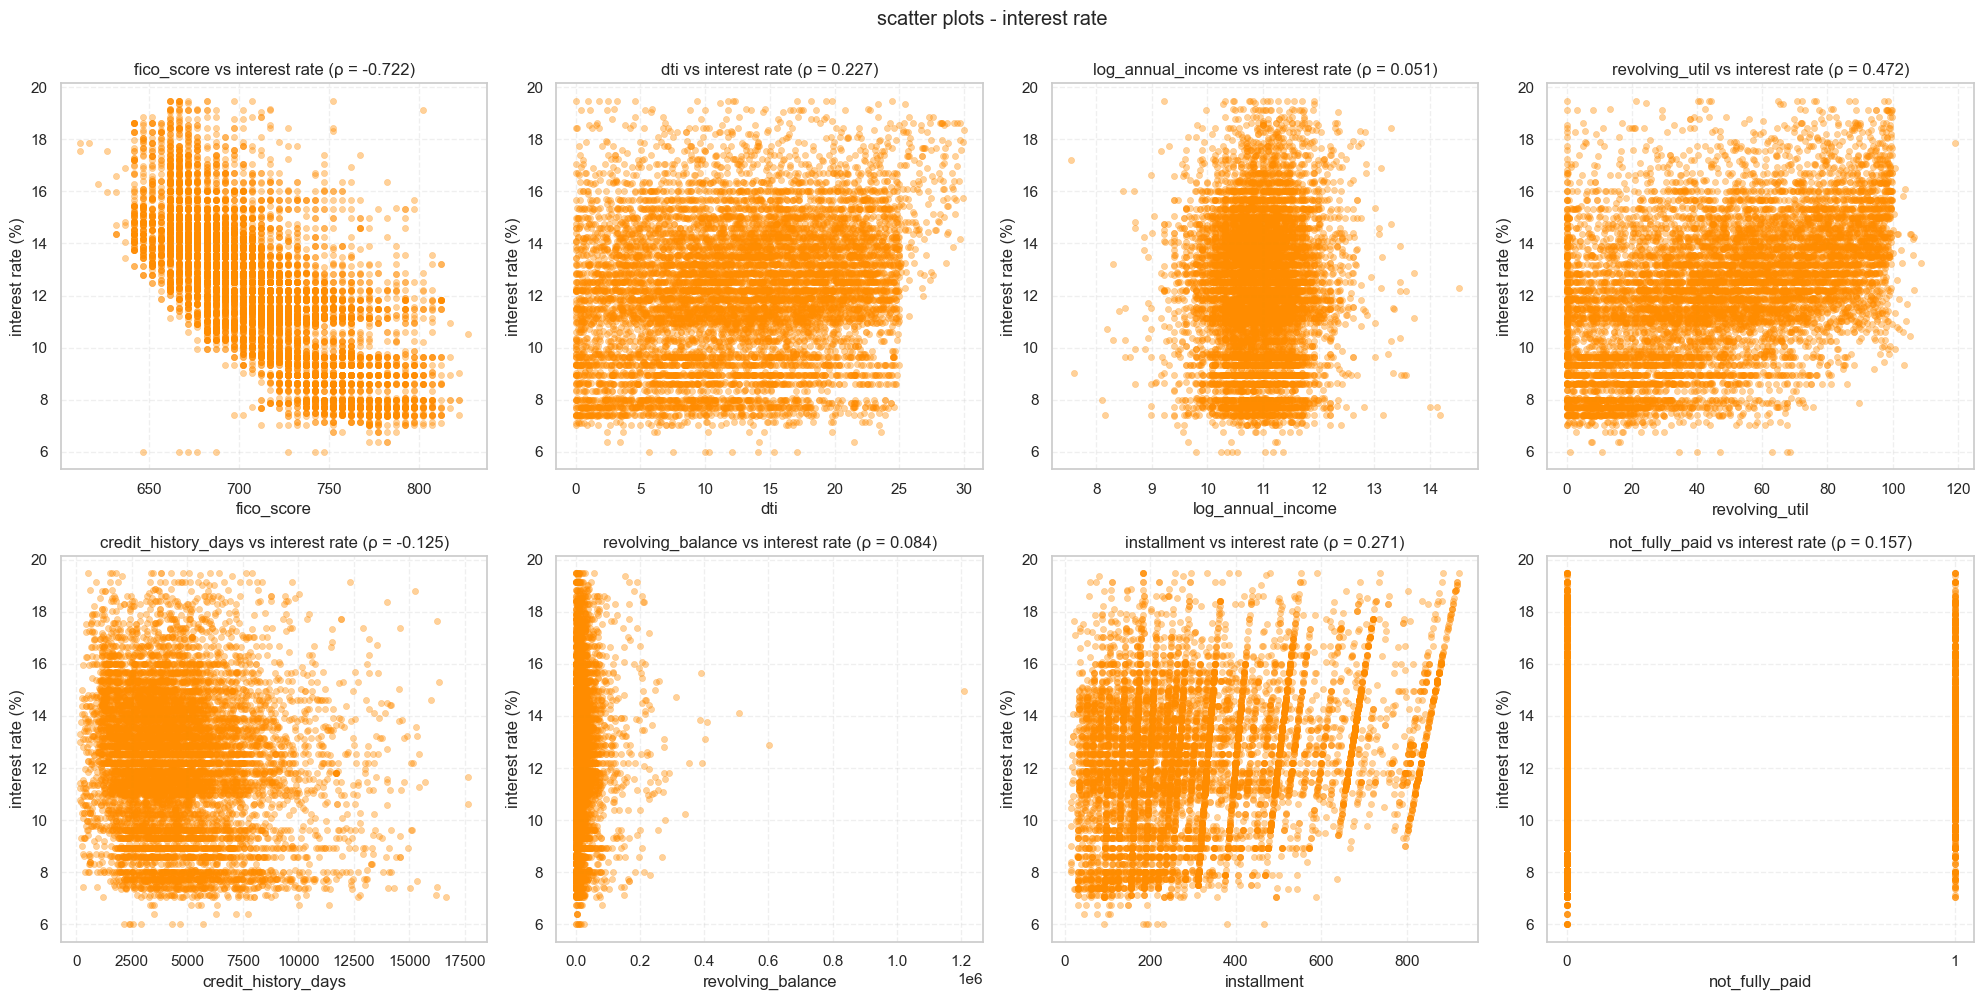

In [64]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, var in enumerate(interest_vars):
    sns.scatterplot(data=data, x=var, y='interest_rate', alpha=0.4, s=20,
                   color='darkorange', edgecolor=None, ax=axes[idx])

    axes[idx].set_xlabel(var)
    axes[idx].set_ylabel('interest rate (%)')
    axes[idx].set_title(f'{var} vs interest rate (ρ = {interest_correlations[var]:.3f})')
    axes[idx].grid(True, alpha=0.3, linestyle='--')

plt.suptitle('scatter plots - interest rate', y=0.998)
plt.tight_layout()
plt.show()

### Come varia il tasso per categoria FICO?

Perchè alcuni clienti con FICO score ottimo hanno tassi di interesse alti? Questo suggerisce che il FICO non è l'unico fattore considerato nella determinazione del prezzo.

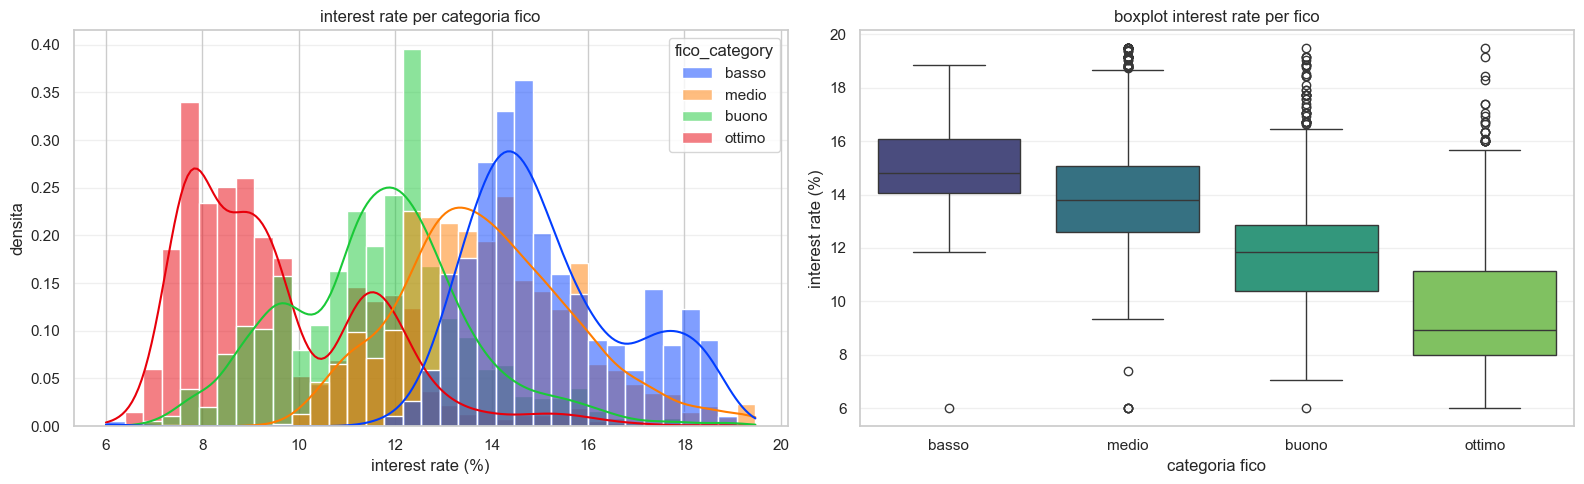

statistiche interest rate per categoria fico:

fico basso:
  media: 15.14%
  mediana: 14.82%

fico medio:
  media: 13.90%
  mediana: 13.79%

fico buono:
  media: 11.67%
  mediana: 11.83%

fico ottimo:
  media: 9.60%
  mediana: 8.94%


In [65]:
data_merged = data.copy()
data_merged['interest_rate'] = data['interest_rate']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(
    data=data_merged,
    x='interest_rate',
    hue='fico_category',
    bins=35,
    kde=True,
    palette='bright',
    alpha=0.5,
    ax=axes[0],
    stat='density',
    common_norm=False
)
axes[0].set_xlabel('interest rate (%)')
axes[0].set_ylabel('densita')
axes[0].set_title('interest rate per categoria fico')
axes[0].grid(True, alpha=0.3, axis='y')

sns.boxplot(
    data=data,
    x='fico_category',
    y='interest_rate',
    hue='fico_category',
    legend=False,
    palette='viridis',
    ax=axes[1]
)

axes[1].set_xlabel('categoria fico')
axes[1].set_ylabel('interest rate (%)')
axes[1].set_title('boxplot interest rate per fico')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("statistiche interest rate per categoria fico:")
print("="*50)
for category in ['basso', 'medio', 'buono', 'ottimo']:
    int_cat = data_merged[data_merged['fico_category'] == category]['interest_rate']
    print(f"\nfico {category}:")
    print(f"  media: {int_cat.mean():.2f}%")
    print(f"  mediana: {int_cat.median():.2f}%")



827
R^2 value: 0.5209994117168051
                            OLS Regression Results                            
Dep. Variable:             fico_score   R-squared:                       0.521
Model:                            OLS   Adj. R-squared:                  0.521
Method:                 Least Squares   F-statistic:                 1.028e+04
Date:                Fri, 16 Jan 2026   Prob (F-statistic):               0.00
Time:                        15:07:47   Log-Likelihood:                -44304.
No. Observations:                9453   AIC:                         8.861e+04
Df Residuals:                    9451   BIC:                         8.863e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const       

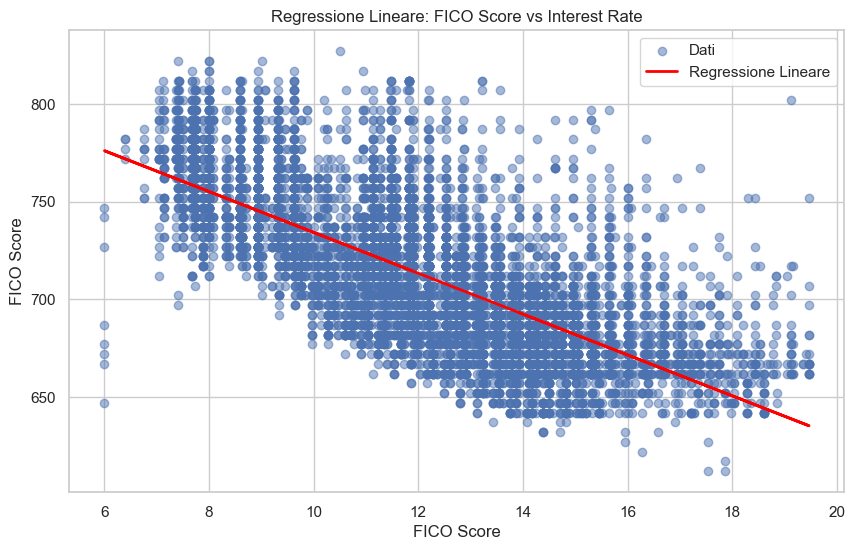

In [66]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Preparazione dei dati
X = data['interest_rate']
y = data['fico_score']

# Aggiunta della costante per l'intercetta
X_const = sm.add_constant(X)

# Creazione e fitting del modello
model = sm.OLS(y, X_const).fit()
print(data['fico_score'].max())
# Stampa del valore R^2
print(f"R^2 value: {model.rsquared}")

# Stampa del sommario della regressione
print(model.summary())


# Plot della regressione
plt.figure(figsize=(10, 6))
plt.scatter(data['interest_rate'], y, alpha=0.5, label='Dati')
plt.plot(data['interest_rate'], model.predict(X_const), color='red', linewidth=2, label='Regressione Lineare')
plt.xlabel('FICO Score')
plt.ylabel('FICO Score')
plt.title('Regressione Lineare: FICO Score vs Interest Rate')
plt.legend()
plt.show()

In [67]:

from scipy import stats


print("="*80)
print("ANALISI DI SIGNIFICATIVITÀ STATISTICA")
print("="*80)

# Seleziona colonne numeriche escludendo interest_rate
numeric_cols_clean = data.select_dtypes(include=[np.number]).columns.tolist()
if 'fico_score' in numeric_cols_clean:
    numeric_cols_clean.remove('fico_score')
if 'customer_id' in numeric_cols_clean:
    numeric_cols_clean.remove('customer_id')

print(f"\nVariabili analizzate: {numeric_cols_clean}\n")

# Calcola correlazioni e p-values
results = []

for col in numeric_cols_clean:
    # Filtra righe dove entrambe le variabili sono presenti
    valid_data = data[[col, 'fico_score']].dropna()

    if len(valid_data) > 2:  # Almeno 3 punti
        corr, pvalue = stats.pearsonr(valid_data[col], valid_data['fico_score'])
        results.append({
            'Variabile': col,
            'Correlazione': corr,
            'P-Value': pvalue,
            'Significativo': 'Sì' if pvalue < 0.05 else 'No'
        })

# Crea DataFrame e ordina per p-value
df_results = pd.DataFrame(results).sort_values('P-Value')

print("RISULTATI:")
print("="*80)
print(df_results.to_string(index=False))

# Variabili significative
sig_vars = df_results[df_results['P-Value'] < 0.05]['Variabile'].tolist()
print(f"\n\nVariabili Significative (p < 0.05):")
for var in sig_vars:
    print(f"  • {var}")


ANALISI DI SIGNIFICATIVITÀ STATISTICA

Variabili analizzate: ['credit_policy', 'interest_rate', 'installment', 'log_annual_income', 'dti', 'credit_history_days', 'revolving_balance', 'revolving_util', 'inquiries_last_6m', 'delinquencies_2y', 'public_records', 'credit_history_years', 'annual_income']

RISULTATI:
           Variabile  Correlazione       P-Value Significativo
       interest_rate     -0.721803  0.000000e+00            Sì
      revolving_util     -0.542259  0.000000e+00            Sì
       credit_policy      0.354331 1.076939e-277            Sì
 credit_history_days      0.262881 3.399491e-149            Sì
credit_history_years      0.262881 3.399491e-149            Sì
                 dti     -0.241828 7.237813e-126            Sì
    delinquencies_2y     -0.216548 1.026554e-100            Sì
   inquiries_last_6m     -0.185976  2.542560e-74            Sì
      public_records     -0.147306  5.268273e-47            Sì
   log_annual_income      0.114631  5.075200e-29         

In [68]:
# Seleziona le prime 4 variabili più significative (escludendo quelle non numeriche)
vars_top = []
for v in df_results["Variabile"].tolist():
    if v == 'fico_score':  # Escludi la variabile target
        continue
    if data[v].dtype in ['int64', 'float64', 'int32', 'float32']:
        vars_top.append(v)
        if len(vars_top) == 4:
            break

print(f"Variabili selezionate per il modello multivariato:\n")
for i, v in enumerate(vars_top, 1):
    corr = df_results[df_results['Variabile'] == v]['Correlazione'].values[0]
    pval = df_results[df_results['Variabile'] == v]['P-Value'].values[0]
    print(f"  {i}. {v}: r={corr:.4f}, p={pval:.2e}")

# Crea il modello usando data (come nella cella precedente)
X_multi = sm.add_constant(data[vars_top])
y_multi = data['fico_score']

model_multi = sm.OLS(y_multi, X_multi).fit()

print("\n" + "="*80)
print("RISULTATI MODELLO MULTIVARIATO:")
print("="*80)
print(f"R² = {model_multi.rsquared:.4f}")
print(f"Adjusted R² = {model_multi.rsquared_adj:.4f}")
print(f"\nCoefficienti e p-values:")
print(model_multi.summary().tables[1])

Variabili selezionate per il modello multivariato:

  1. interest_rate: r=-0.7218, p=0.00e+00
  2. revolving_util: r=-0.5423, p=0.00e+00
  3. credit_history_days: r=0.2629, p=3.40e-149
  4. credit_history_years: r=0.2629, p=3.40e-149

RISULTATI MODELLO MULTIVARIATO:
R² = 0.6070
Adjusted R² = 0.6069

Coefficienti e p-values:
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  815.8842      1.323    616.552      0.000     813.290     818.478
interest_rate           -8.2882      0.107    -77.608      0.000      -8.498      -8.079
revolving_util          -0.3505      0.010    -36.584      0.000      -0.369      -0.332
credit_history_days      0.0028   9.89e-05     28.459      0.000       0.003       0.003
credit_history_years  7.703e-06   2.71e-07     28.459      0.000    7.17e-06    8.23e-06


### Cosa abbiamo imparato sul FICO score

I punteggi FICO dipendono da diversi fattori finanziari e comportamentali. Il nostro modello multivariato ci permette di identificare le variabili più influenti.

**Risultati del modello multivariato:**
- R²: 0.61, ovvero il 61% della variazione nei punteggi FICO è spiegata dalle nostre variabili
- Il 39% restante dipende da fattori non misurati nel dataset

**Variabili significative**: Interest rate, revolving utilization, credit history (in giorni e anni) sono tutti statisticamente significativi con p-value inferiori a 0.001.

**Conclusione**: Con sole 4 variabili riusciamo a spiegare il 61% della variabilità nei punteggi FICO. È un risultato notevole, considerando che molti fattori rilevanti (come la storia dei pagamenti o i diversi tipi di credito) non sono disponibili nel dataset pubblico.

## Quali caratteristiche sono associate a punteggi FICO piu alti o piu bassi?


Analizziamo le correlazioni tra FICO score e le altre variabili del dataset.

In [69]:
fico_vars = ['dti', 'interest_rate', 'log_annual_income', 'revolving_util',
            'credit_history_days', 'revolving_balance', 'not_fully_paid']

print("associazione fico score con altre variabili")
print("="*70)
print(f"{'variabile':<30} {'pearson ρ':>18} {'covariance':>18}")
print("-"*70)

fico_correlations = {}
fico_covariances = {}
for var in fico_vars:
    fico_correlations[var] = data['fico_score'].corr(data[var])
    fico_covariances[var] = data['fico_score'].cov(data[var])
    print(f"{var:<30} {fico_correlations[var]:>18.4f} {fico_covariances[var]:>18.2f}")

print("="*70)

sorted_corr_fico = sorted(fico_correlations.items(), key=lambda x: abs(x[1]), reverse=True)
print(f"\ntop 3 correlazioni con fico score:")
for i, (var, corr) in enumerate(sorted_corr_fico[:3], 1):
    direction = "positiva" if corr > 0 else "negativa"
    print(f"  {i}. {var}: ρ = {corr:.4f} (correlazione {direction})")

associazione fico score con altre variabili
variabile                               pearson ρ         covariance
----------------------------------------------------------------------
dti                                       -0.2418             -63.19
interest_rate                             -0.7218             -71.75
log_annual_income                          0.1146               2.65
revolving_util                            -0.5423            -596.35
credit_history_days                        0.2629           24895.41
revolving_balance                         -0.0124          -15109.85
not_fully_paid                            -0.1481              -2.05

top 3 correlazioni con fico score:
  1. interest_rate: ρ = -0.7218 (correlazione negativa)
  2. revolving_util: ρ = -0.5423 (correlazione negativa)
  3. credit_history_days: ρ = 0.2629 (correlazione positiva)


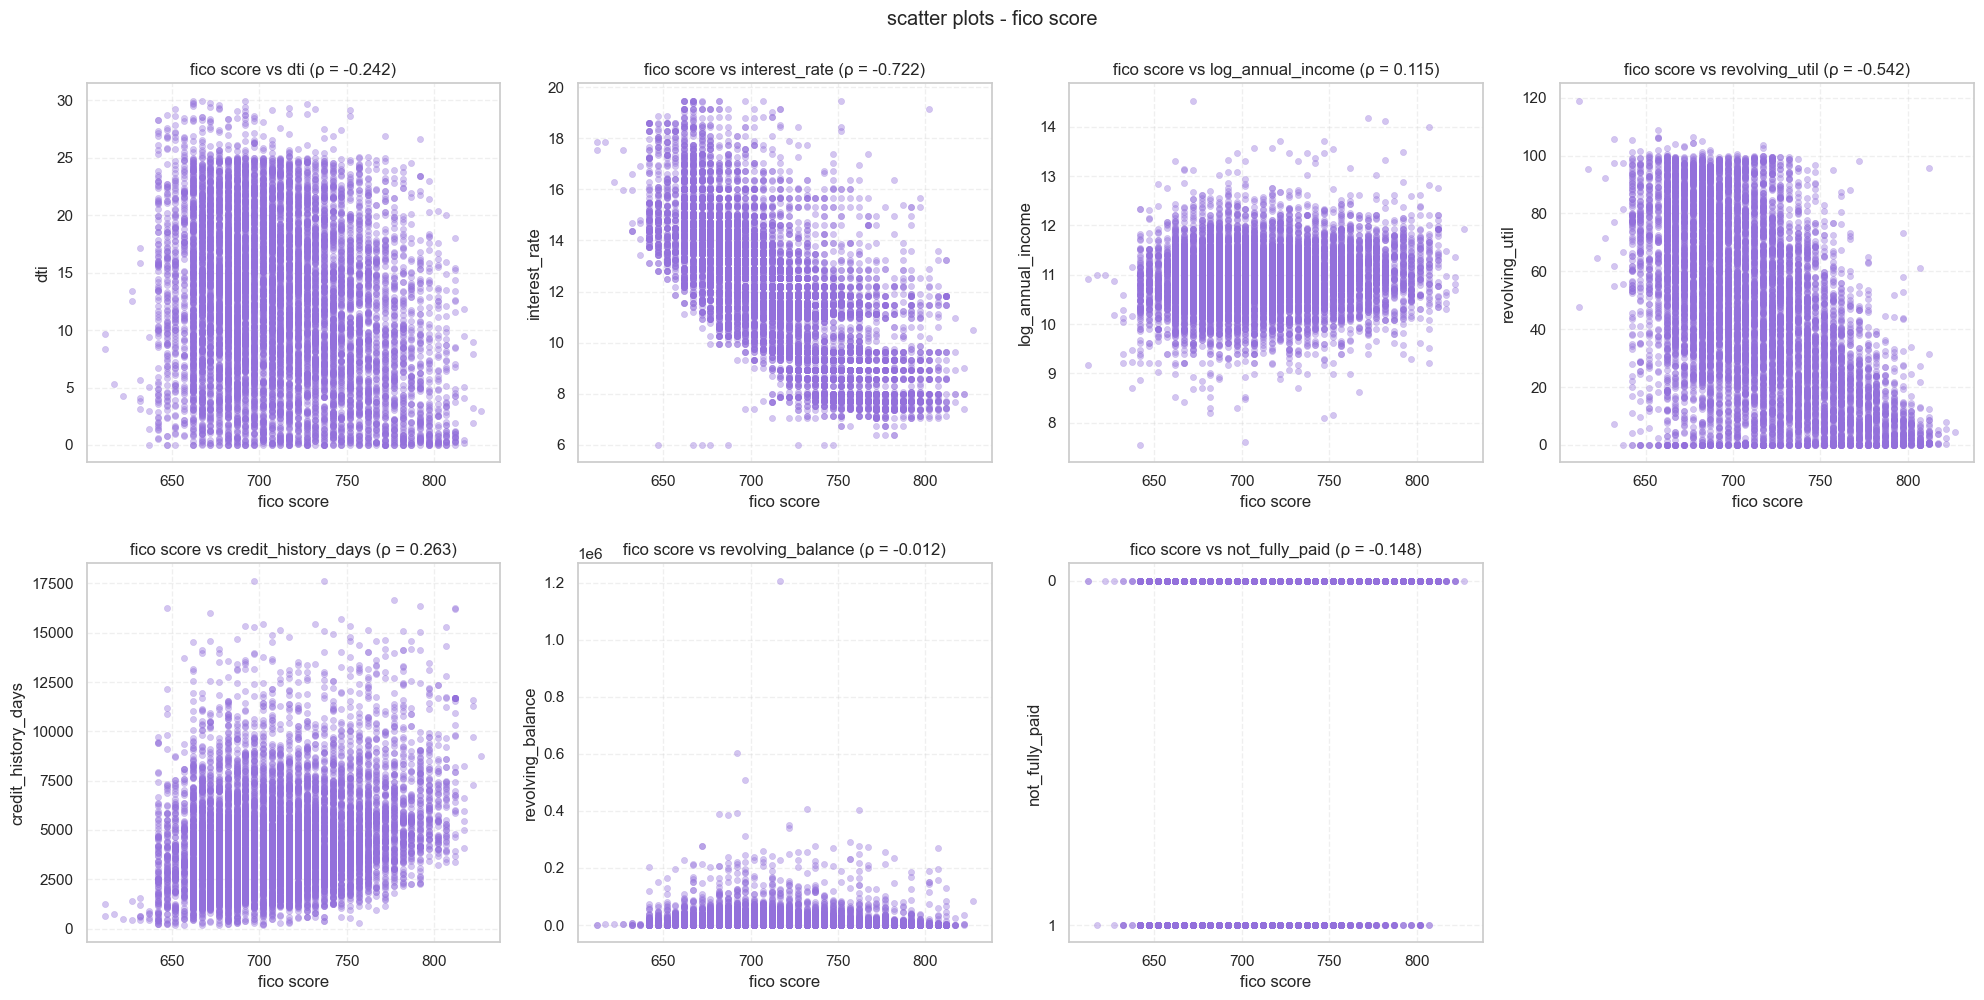

In [70]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, var in enumerate(fico_vars):
    sns.scatterplot(data=data, x='fico_score', y=var, alpha=0.4, s=20,
                   color='mediumpurple', edgecolor=None, ax=axes[idx])

    axes[idx].set_xlabel('fico score')
    axes[idx].set_ylabel(var)
    axes[idx].set_title(f'fico score vs {var} (ρ = {fico_correlations[var]:.3f})')
    axes[idx].grid(True, alpha=0.3, linestyle='--')

axes[7].axis('off')

plt.suptitle('scatter plots - fico score', y=0.998)
plt.tight_layout()
plt.show()

### Come varia il FICO tra chi paga e chi no?

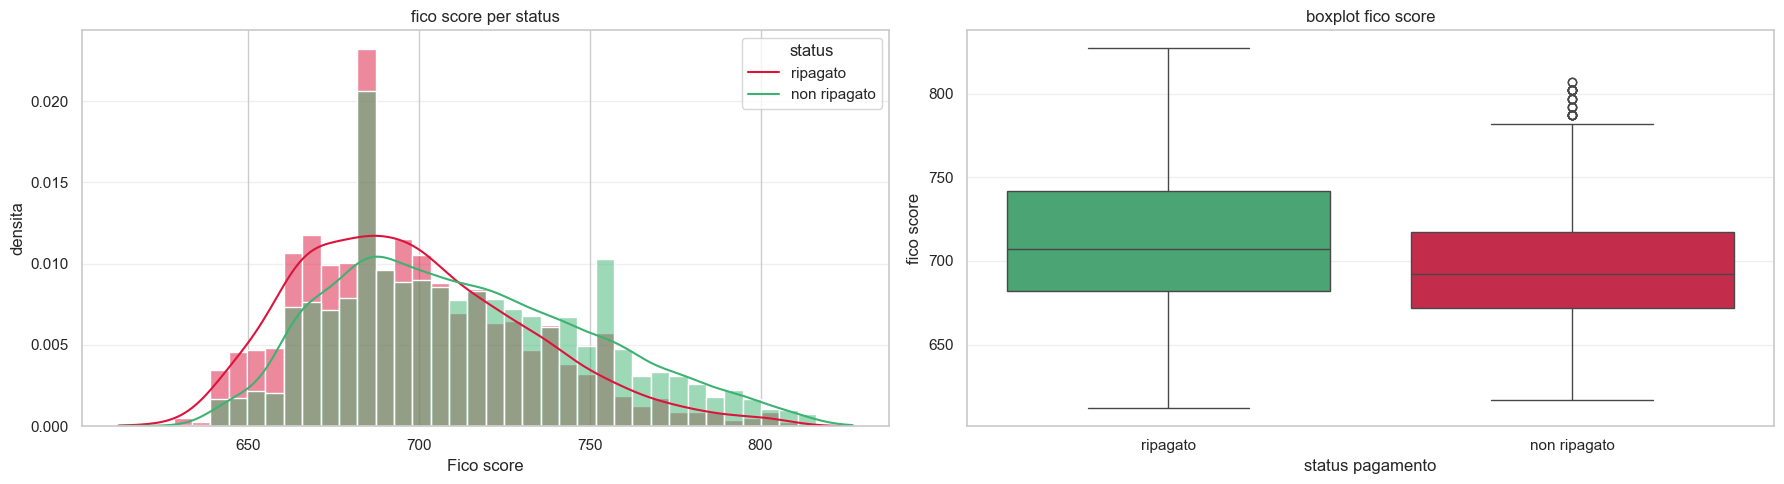

statistiche fico score per status pagamento:

ripagato:
  media: 713.46
  mediana: 707.00
  std: 38.20

non ripagato:
  media: 698.08
  mediana: 692.00
  std: 33.69


In [71]:
color_palette ={'0': 'mediumseagreen', '1': 'crimson'}

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.histplot(data=data, x='fico_score', hue='not_fully_paid', bins=40, kde=True,
             palette=color_palette, alpha=0.5,
             ax=axes[0], stat='density', common_norm=False)
axes[0].set_xlabel('Fico score')
axes[0].set_ylabel('densita')
axes[0].set_title('fico score per status')
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(labels=['ripagato', 'non ripagato'], title='status')
axes[0].grid(True, alpha=0.3, axis='y')

sns.boxplot(data=data, x='not_fully_paid', y='fico_score',
           palette=color_palette, ax=axes[1], hue='not_fully_paid', legend=False)
axes[1].set_xlabel('status pagamento')
axes[1].set_ylabel('fico score')
axes[1].set_title('boxplot fico score')
axes[1].set_xticks([0,1])
axes[1].set_xticklabels(['ripagato', 'non ripagato'])
axes[1].grid(True, alpha=0.3, axis='y')



plt.tight_layout()
plt.show()

print("statistiche fico score per status pagamento:")
print("="*50)

for status in ['0', '1']:
    fico_group = data[data['not_fully_paid'] == status]['fico_score']
    status_name = "ripagato" if status == '0' else "non ripagato"

    fico_group = fico_group.dropna()
    if not fico_group.empty:
        print(f"\n{status_name}:")
        print(f"  media: {fico_group.mean():.2f}")
        print(f"  mediana: {fico_group.median():.2f}")
        print(f"  std: {fico_group.std():.2f}")
    else:
        print(f"\n{status_name}: Non sono stati trovati dati validi per questo status.")

### Esiste una relazione tra FICO e utilizzo del credito?


Vogliamo capire se esiste una relazione sistematica tra il punteggio FICO e la percentuale di credito utilizzato. Quest' analisi è particolarmente interessante perchè l'utilizzo del credito è uno dei fattori che influenzano il calcolo del FICO stesso.

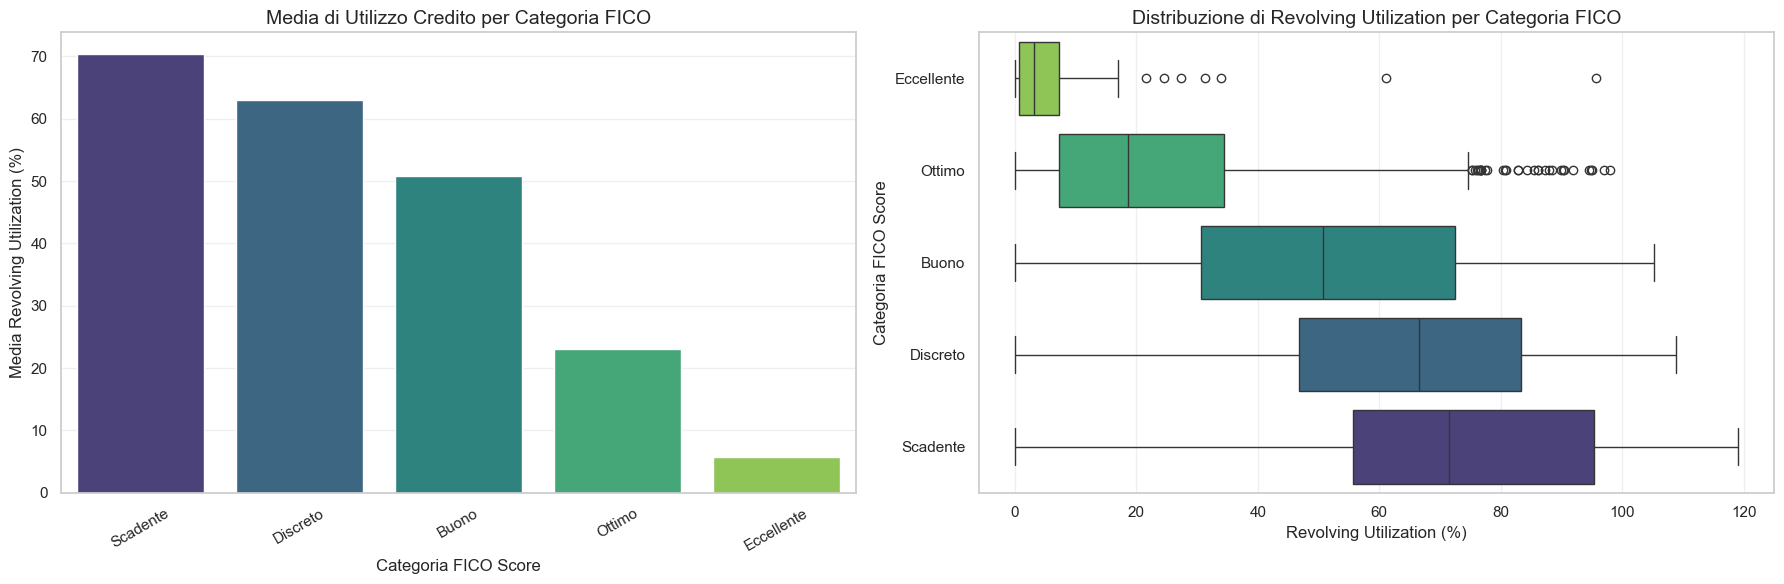


STATISTICHE DI REVOLVING UTILIZATION PER CATEGORIA FICO:

Categoria 'Scadente':
  Media:   70.34%
  Mediana: 71.40%
  Dev. Std.: 31.99%

Categoria 'Discreto':
  Media:   63.01%
  Mediana: 66.50%
  Dev. Std.: 25.47%

Categoria 'Buono':
  Media:   50.85%
  Mediana: 50.80%
  Dev. Std.: 26.89%

Categoria 'Ottimo':
  Media:   23.04%
  Mediana: 18.60%
  Dev. Std.: 19.59%

Categoria 'Eccellente':
  Media:   5.78%
  Mediana: 3.20%
  Dev. Std.: 10.76%


In [72]:
data['fico_category'] = pd.cut(data['fico_score'], bins=[0, 640, 680, 740, 800, 850],
                              labels=['Scadente', 'Discreto', 'Buono', 'Ottimo', 'Eccellente'],
                              right=False, include_lowest=True)

FICO_CATEGORIES = ['Scadente', 'Discreto', 'Buono', 'Ottimo', 'Eccellente']

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(
    data=data,
    x='fico_category',
    y='revolving_util',
    hue='fico_category',
    palette='viridis',
    order=FICO_CATEGORIES,
    ax=axes[0],
    errorbar=None,
    legend=False
)

axes[0].set_xlabel('Categoria FICO Score')
axes[0].set_ylabel('Media Revolving Utilization (%)')
axes[0].set_title('Media di Utilizzo Credito per Categoria FICO', fontsize=14)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(
    data=data,
    x='revolving_util',
    y='fico_category',
    hue='fico_category',
    palette='viridis',
    order=FICO_CATEGORIES[::-1],
    ax=axes[1],
    legend=False
)

axes[1].set_xlabel('Revolving Utilization (%)')
axes[1].set_ylabel('Categoria FICO Score')
axes[1].set_title('Distribuzione di Revolving Utilization per Categoria FICO', fontsize=14)
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()


print("\nSTATISTICHE DI REVOLVING UTILIZATION PER CATEGORIA FICO:")
print("="*60)

for category in FICO_CATEGORIES:
    util_group = data[data['fico_category'] == category]['revolving_util']

    if not util_group.empty:
        print(f"\nCategoria '{category}':")
        print(f"  Media:   {util_group.mean():.2f}%")
        print(f"  Mediana: {util_group.median():.2f}%")
        print(f"  Dev. Std.: {util_group.std():.2f}%")
    else:
        print(f"\nCategoria '{category}': Nessun dato trovato con questa etichetta.")

I risultati mostrano una correlazione negativa  tra FICO score e utilizzo del credito revolving:
- Chi ha un FICO basso utilizza una percentuale molto alta del credito disponibile
- Chi ha un FICO eccellente mantiene i saldi revolving bassi

Questo ha senso: l'utilizzo del credito è una delle componenti del punteggio FICO. Ma quanto è forte questa relazione?

Quanto cambia l'utilizzo del credito in base al FICO ?

                            OLS Regression Results                            
Dep. Variable:         revolving_util   R-squared:                       0.294
Model:                            OLS   Adj. R-squared:                  0.294
Method:                 Least Squares   F-statistic:                     3937.
Date:                Fri, 16 Jan 2026   Prob (F-statistic):               0.00
Time:                        15:07:49   Log-Likelihood:                -43594.
No. Observations:                9453   AIC:                         8.719e+04
Df Residuals:                    9451   BIC:                         8.721e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        341.4217      4.702     72.610      0.0

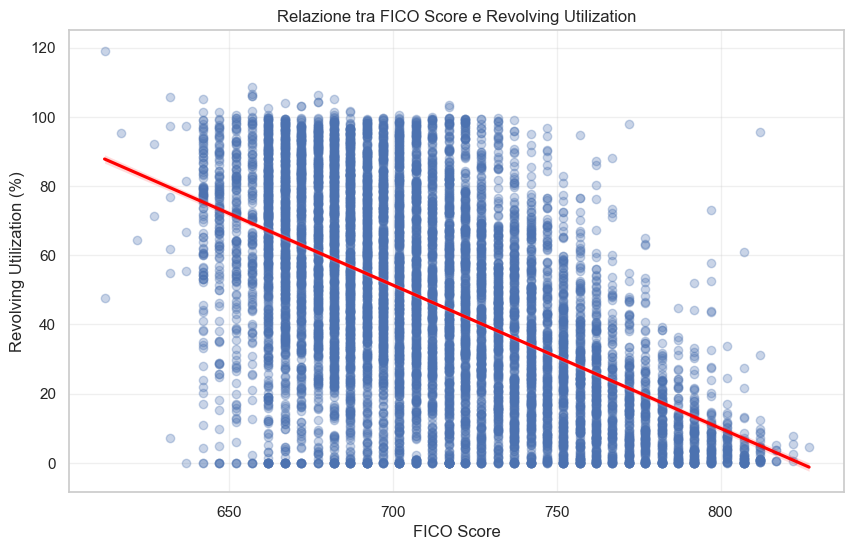

In [73]:
df = data.dropna(subset=['fico_score', 'revolving_util']).copy()

X = df['fico_score']
X = sm.add_constant(X)

Y = df['revolving_util']
model = sm.OLS(Y,X).fit()
print(model.summary())

plt.figure(figsize=(10,6))
sns.regplot(data=df, x='fico_score', y='revolving_util',
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})

plt.title("Relazione tra FICO Score e Revolving Utilization")
plt.xlabel("FICO Score")
plt.ylabel("Revolving Utilization (%)")
plt.grid(True, alpha=0.3)
plt.show()





**Interpretazione della regressione**:

Il coefficiente è -0.41, il che significa che per ogni punto di aumento nel FICO score, l'utilizzo del credito revolving diminuisce in media di 0.41 punti percentuali.

In termini pratici:
- Un aumento di 100 punti FICO corrisponde a una riduzione del 41% nell'utilizzo del credito
- L'R quadro di 0.29 indica che il FICO spiega circa il 29% della variabilita nell'utilizzo
- Il p-value conferma che la relazione e statisticamente significativa

# PARTE 5: TECNICHE AVANZATE

Fin qui abbiamo usato statistiche descrittive e regressioni. Ora applichiamo tecniche piu sofisticate:
- K-Means Clustering: per scoprire se esistono gruppi naturali di clienti
- PCA: per capire quali variabili catturano la maggior parte dell'informazione
- Simulazione Monte Carlo: per stimare il rischio del portafoglio sotto diversi scenari

## 5.1 Ci sono gruppi naturali di persone?

Questa e la domanda centrale di questa sezione. Vogliamo capire se, guardando solo le caratteristiche finanziarie dei clienti, senza sapere se hanno ripagato o meno, emergono gruppi distinti. Se esistono, potremmo usarli per differenziare le politiche di credito.

Prima di applicare tecniche sofisticate, proviamo un approccio diretto: applichiamo K-Means sulle variabili originali e vediamo cosa otteniamo. Questo ci permettera di capire se i gruppi emergono naturalmente dai dati o se servono accorgimenti aggiuntivi.

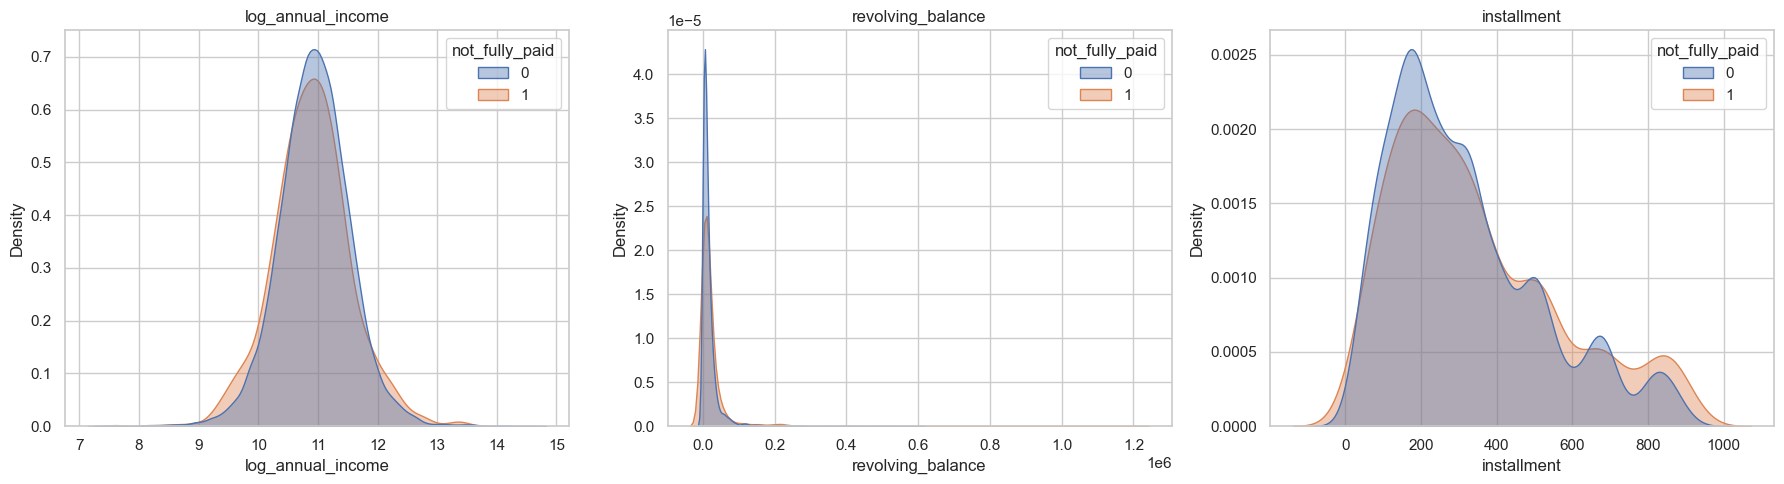

In [74]:


vars_to_plot = [
    'log_annual_income',
    'revolving_balance',
    'installment'
]

fig, axes = plt.subplots(1, len(vars_to_plot), figsize=(18, 5))

for ax, var in zip(axes, vars_to_plot):
    sns.kdeplot(
        data=data,
        x=var,
        hue='not_fully_paid',
        common_norm=False,
        fill=True,
        alpha=0.4,
        ax=ax
    )
    ax.set_title(var)

plt.tight_layout()
plt.show()


## 5.1.1 K-Means sulle variabili originali

Partiamo selezionando le variabili che descrivono il profilo finanziario di un cliente: FICO score, reddito, rapporto debito/reddito, utilizzo del credito revolving e tasso di interesse applicato.

K-Means richiede che le variabili siano sulla stessa scala, quindi standardizziamo i dati. Poi cerchiamo il numero ottimale di cluster con due metodi: il metodo Elbow, che guarda la compattezza interna dei cluster, e il Silhouette Score, che valuta anche la separazione tra i gruppi.

In [75]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.cm as cm

# Selezione delle feature per il clustering
# Usiamo variabili che catturano il profilo finanziario del cliente
features_cluster = ['fico_score', 'log_annual_income', 'dti', 'revolving_util', 'interest_rate']

# Pulizia dati: convertiamo a numerico
for col in features_cluster:
    data[col] = pd.to_numeric(data[col], errors='coerce')

X_cluster = data[features_cluster].dropna().copy()

# Rimozione outlier estremi per interest_rate
outlier_mask = X_cluster['interest_rate'] <= 30
X_cluster = X_cluster[outlier_mask]

print(f"Dataset per clustering: {X_cluster.shape[0]} osservazioni, {X_cluster.shape[1]} features")
print(f"Rimossi {(~outlier_mask).sum()} outlier con interest_rate maggiore di 30 percento")
print(f"\nFeatures selezionate: {features_cluster}")

# Standardizzazione, fondamentale per K-Means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print("\nStatistiche dopo standardizzazione:")
print(pd.DataFrame(X_scaled, columns=features_cluster).describe().round(2))

Dataset per clustering: 9453 osservazioni, 5 features
Rimossi 0 outlier con interest_rate maggiore di 30 percento

Features selezionate: ['fico_score', 'log_annual_income', 'dti', 'revolving_util', 'interest_rate']

Statistiche dopo standardizzazione:
       fico_score  log_annual_income      dti  revolving_util  interest_rate
count     9453.00            9453.00  9453.00         9453.00        9453.00
mean        -0.00              -0.00    -0.00           -0.00          -0.00
std          1.00               1.00     1.00            1.00           1.00
min         -2.61              -5.56    -1.83           -1.62          -2.38
25%         -0.76              -0.61    -0.78           -0.83          -0.70
50%         -0.11              -0.01     0.01           -0.02          -0.01
75%          0.68               0.59     0.78            0.83           0.65
max          3.06               5.91     2.52            2.49           2.77


### Quanti cluster servono?

Il metodo Elbow valuta la somma dei quadrati delle distanze intra-cluster per diversi valori di K. Il punto in cui la curva piega indica che aggiungere altri cluster non migliora significativamente la compattezza. Il Silhouette Score invece misura quanto i punti sono ben raggruppati nel proprio cluster rispetto agli altri.

Calcolo metriche per K da 2 a 10...
  K=2: Inertia=32064.86, Silhouette=0.2850
  K=3: Inertia=27956.54, Silhouette=0.2116
  K=4: Inertia=24871.58, Silhouette=0.1956
  K=5: Inertia=22369.89, Silhouette=0.1973
  K=6: Inertia=20949.55, Silhouette=0.1863
  K=7: Inertia=19884.68, Silhouette=0.1729
  K=8: Inertia=18473.01, Silhouette=0.1783
  K=9: Inertia=17616.98, Silhouette=0.1735
  K=10: Inertia=16947.16, Silhouette=0.1706


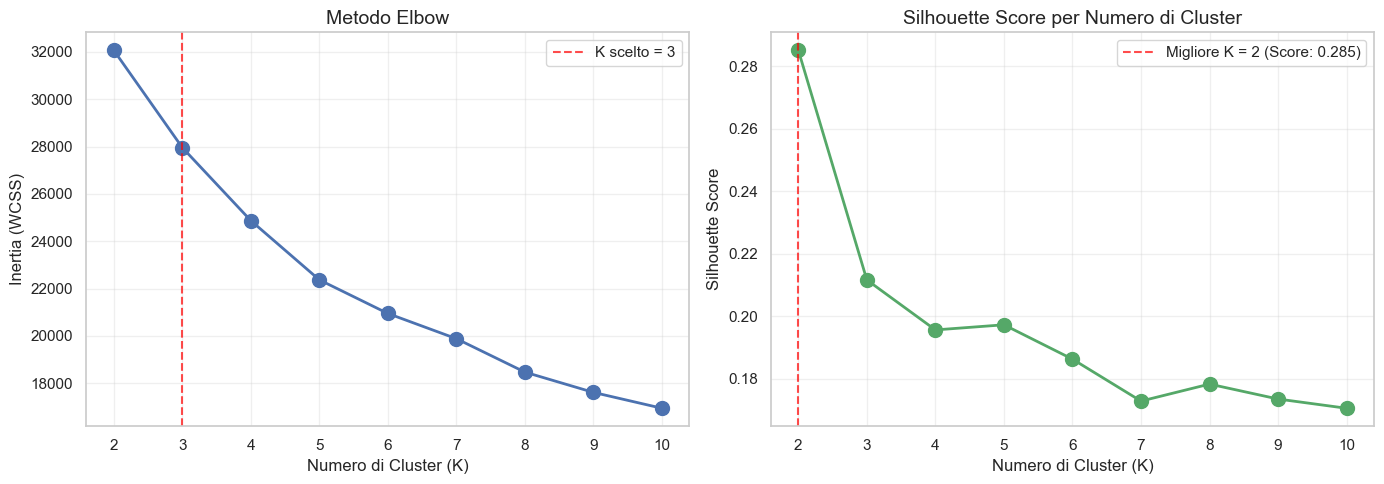


Risultati:
  - Metodo Elbow: suggerisce K = 3-4, dove la curva piega
  - Silhouette Score: K ottimale = 2 con score = 0.2850
  - Scelta finale: K = 3 per bilanciamento tra separazione e interpretabilita


In [76]:
# Metodo Elbow e Silhouette Score
K_range = range(2, 11)
inertias = []
silhouette_scores = []

print("Calcolo metriche per K da 2 a 10...")
for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    sil_score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(sil_score)
    print(f"  K={k}: Inertia={kmeans.inertia_:.2f}, Silhouette={sil_score:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=10)
axes[0].set_xlabel('Numero di Cluster (K)', fontsize=12)
axes[0].set_ylabel('Inertia (WCSS)', fontsize=12)
axes[0].set_title('Metodo Elbow', fontsize=14)
axes[0].set_xticks(list(K_range))
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=3, color='red', linestyle='--', alpha=0.7, label='K scelto = 3')
axes[0].legend()

axes[1].plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=10)
axes[1].set_xlabel('Numero di Cluster (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score per Numero di Cluster', fontsize=14)
axes[1].set_xticks(list(K_range))
axes[1].grid(True, alpha=0.3)

best_k = list(K_range)[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)
axes[1].axvline(x=best_k, color='red', linestyle='--', alpha=0.7, label=f'Migliore K = {best_k} (Score: {best_score:.3f})')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nRisultati:")
print(f"  - Metodo Elbow: suggerisce K = 3-4, dove la curva piega")
print(f"  - Silhouette Score: K ottimale = {best_k} con score = {best_score:.4f}")
print(f"  - Scelta finale: K = 3 per bilanciamento tra separazione e interpretabilita")

### Analisi Silhouette

Il Silhouette Score misura quanto ogni punto e simile al proprio cluster rispetto agli altri cluster. Valori vicini a +1 indicano punti ben raggruppati, valori vicini a 0 indicano punti al confine tra cluster, valori negativi indicano probabili errori di assegnazione.

Guardiamo i grafici silhouette per diversi valori di K:

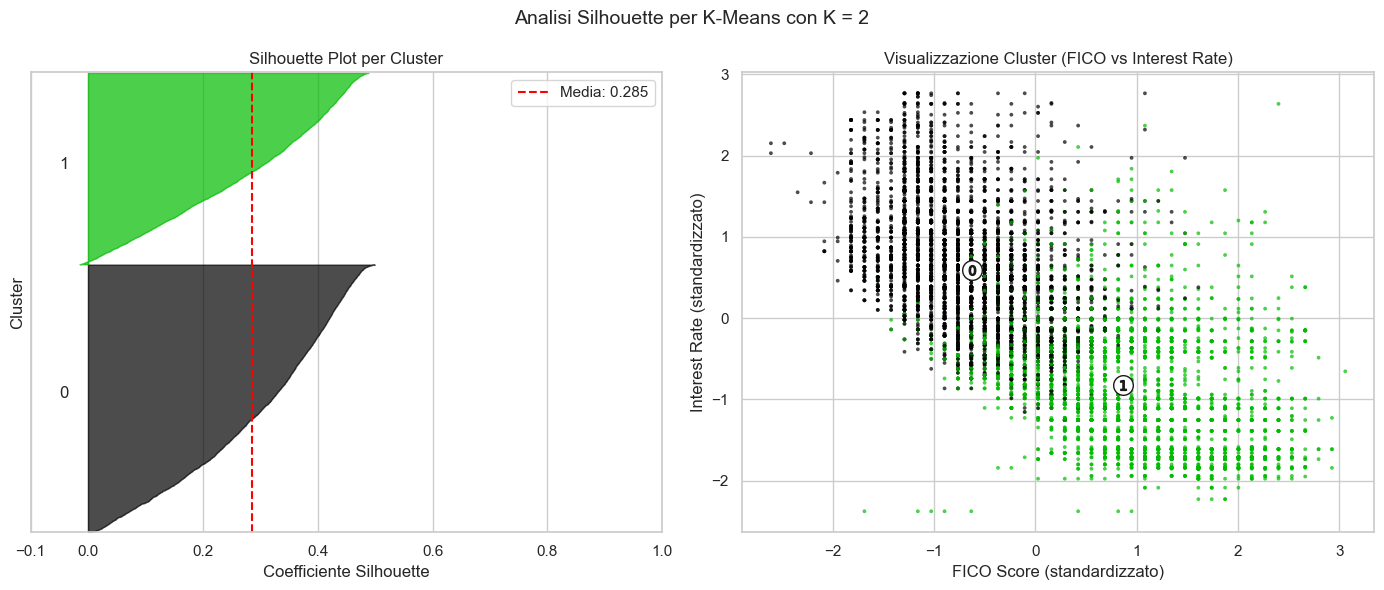

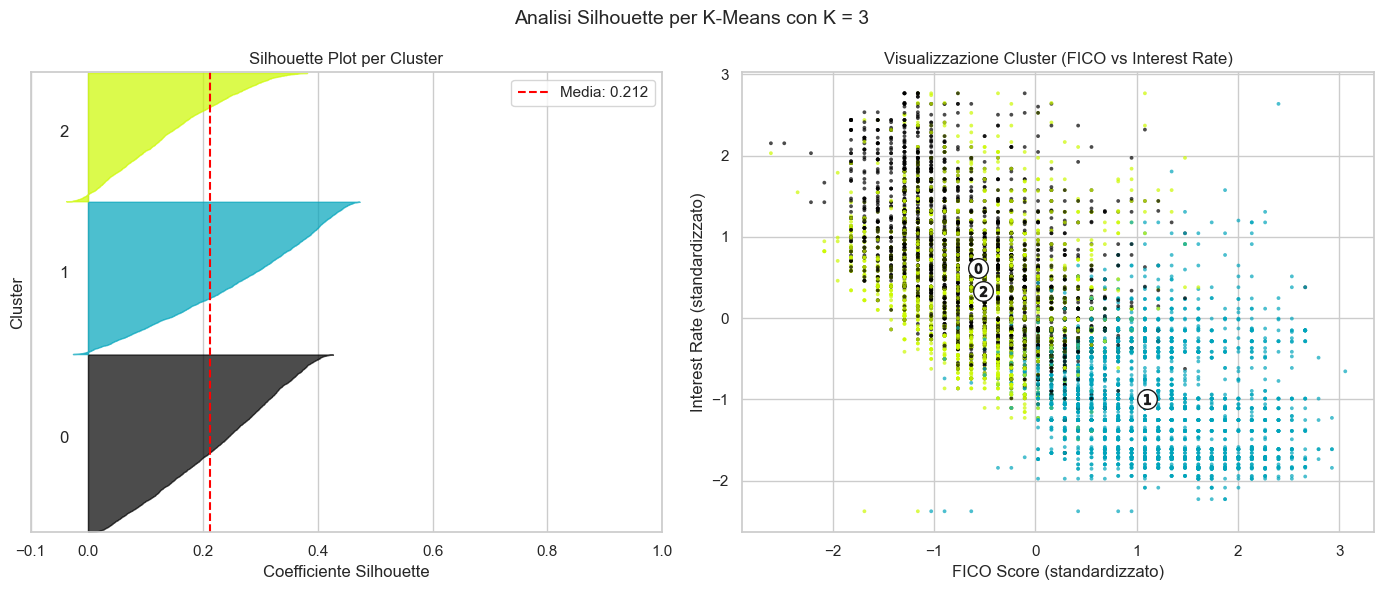

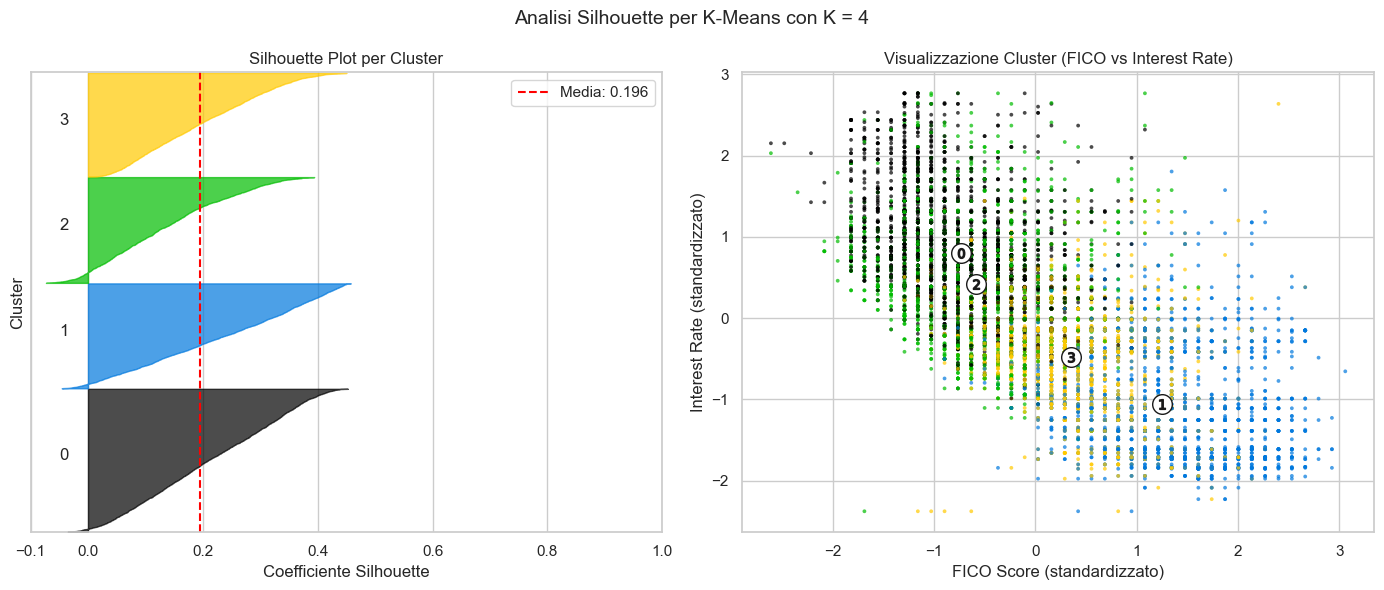

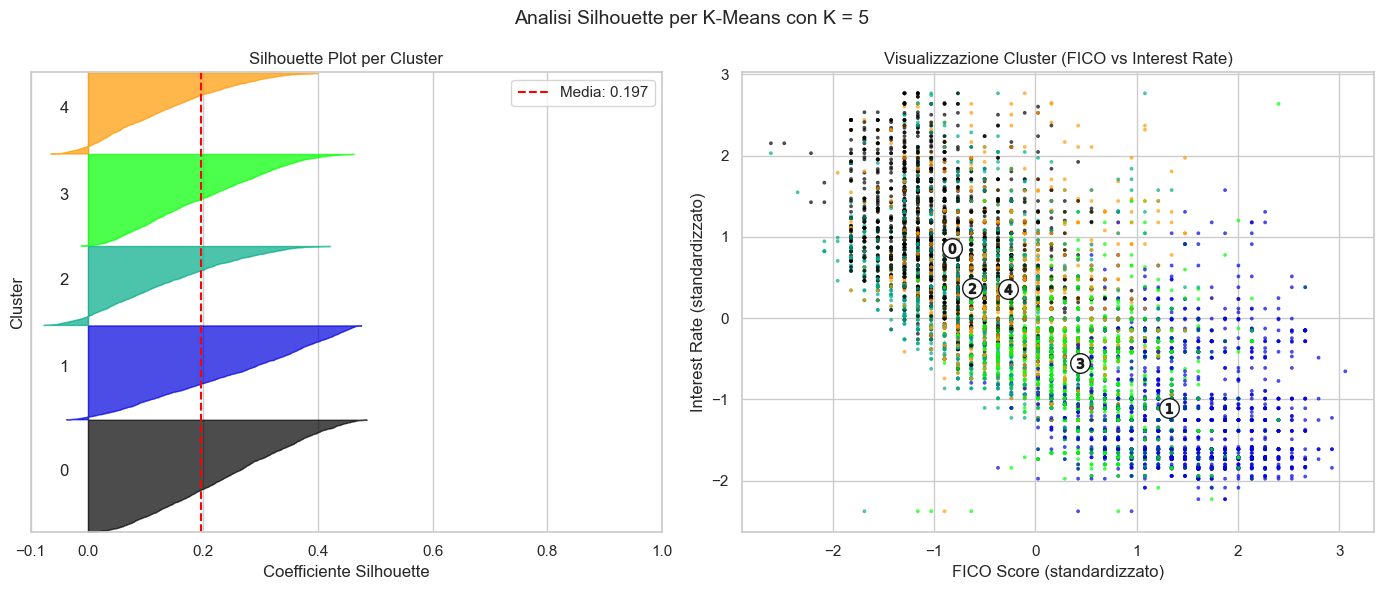

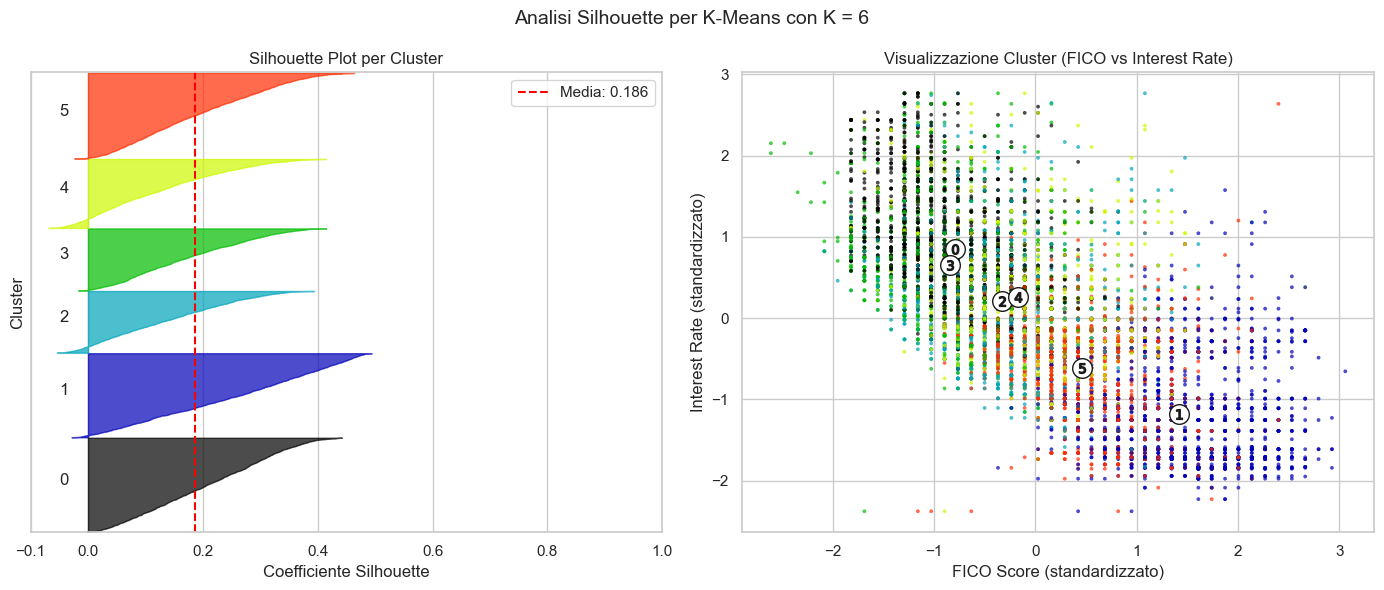

In [77]:
# Silhouette Plot per diversi K
import matplotlib.cm as mpl_cm

range_n_clusters = [2, 3, 4, 5, 6]

for n_clusters in range_n_clusters:
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(14, 6)

    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(X_scaled) + (n_clusters + 1) * 10])

    clusterer = KMeans(n_clusters=n_clusters, n_init='auto', random_state=42)
    cluster_labels = clusterer.fit_predict(X_scaled)

    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    sample_silhouette_values = silhouette_samples(X_scaled, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = mpl_cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    ax1.set_title("Silhouette Plot per Cluster")
    ax1.set_xlabel("Coefficiente Silhouette")
    ax1.set_ylabel("Cluster")
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--",
                label=f'Media: {silhouette_avg:.3f}')
    ax1.legend(loc='upper right')
    ax1.set_yticks([])
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # Visualizzazione dei cluster usando due variabili originali: FICO score e interest_rate
    colors = [mpl_cm.nipy_spectral(float(label) / n_clusters) for label in cluster_labels]
    ax2.scatter(X_scaled[:, 0], X_scaled[:, 4], marker=".", s=30, lw=0, alpha=0.7,
                c=colors, edgecolor="k")

    # Centroidi sulle stesse variabili
    ax2.scatter(clusterer.cluster_centers_[:, 0], clusterer.cluster_centers_[:, 4],
                marker="o", c="white", alpha=1, s=200, edgecolor="k")

    for i, c in enumerate(clusterer.cluster_centers_):
        ax2.scatter(c[0], c[4], marker=f"${i}$", alpha=1, s=50, edgecolor="k")

    ax2.set_title("Visualizzazione Cluster (FICO vs Interest Rate)")
    ax2.set_xlabel("FICO Score (standardizzato)")
    ax2.set_ylabel("Interest Rate (standardizzato)")

    plt.suptitle(f"Analisi Silhouette per K-Means con K = {n_clusters}", fontsize=14)
    plt.tight_layout()
    plt.show()

### Come leggere i grafici

Ogni barra orizzontale rappresenta un cluster. La larghezza indica quanto i punti sono ben raggruppati. La linea rossa tratteggiata e la media globale. I cluster con silhouette sotto la media sono quelli piu problematici.

Un buon K dovrebbe avere cluster di dimensioni simili, pochi punti con silhouette negativa, e un silhouette score medio ragionevolmente alto.

### Scelta del numero di cluster

Dall'analisi Elbow e Silhouette, K=3 sembra un buon compromesso. L'Elbow mostra una piega intorno a 3-4, mentre il Silhouette Score e massimo per K=2 ma decresce poco per K=3. Scegliamo K=3 perche offre tre segmenti interpretabili dal punto di vista del business.

In [78]:
# Applicazione del K-Means finale con K=3
K_ottimale = 3
kmeans_final = KMeans(n_clusters=K_ottimale, n_init='auto', random_state=42)
clusters = kmeans_final.fit_predict(X_scaled)

X_cluster_with_labels = X_cluster.copy()
X_cluster_with_labels['Cluster'] = clusters

final_centers_scaled = kmeans_final.cluster_centers_
final_centers_original = scaler.inverse_transform(final_centers_scaled)

silhouette_originale = silhouette_score(X_scaled, clusters)

print(f"K-Means completato con K = {K_ottimale}")
print(f"Silhouette Score finale: {silhouette_originale:.4f}")
print(f"\nDistribuzione dei cluster:")
print(pd.Series(clusters).value_counts().sort_index())

K-Means completato con K = 3
Silhouette Score finale: 0.2116

Distribuzione dei cluster:
0    3658
1    3145
2    2650
Name: count, dtype: int64


### Profili dei cluster

Analizziamo i centroidi per capire chi sono i clienti in ogni gruppo:

Centroidi dei cluster (valori originali):
           fico_score  log_annual_income    dti  revolving_util  interest_rate
Cluster 0      689.40              11.08  17.57           70.75          13.83
Cluster 1      752.72              11.03  10.08           23.09           9.61
Cluster 2      691.36              10.61   8.86           41.94          13.11


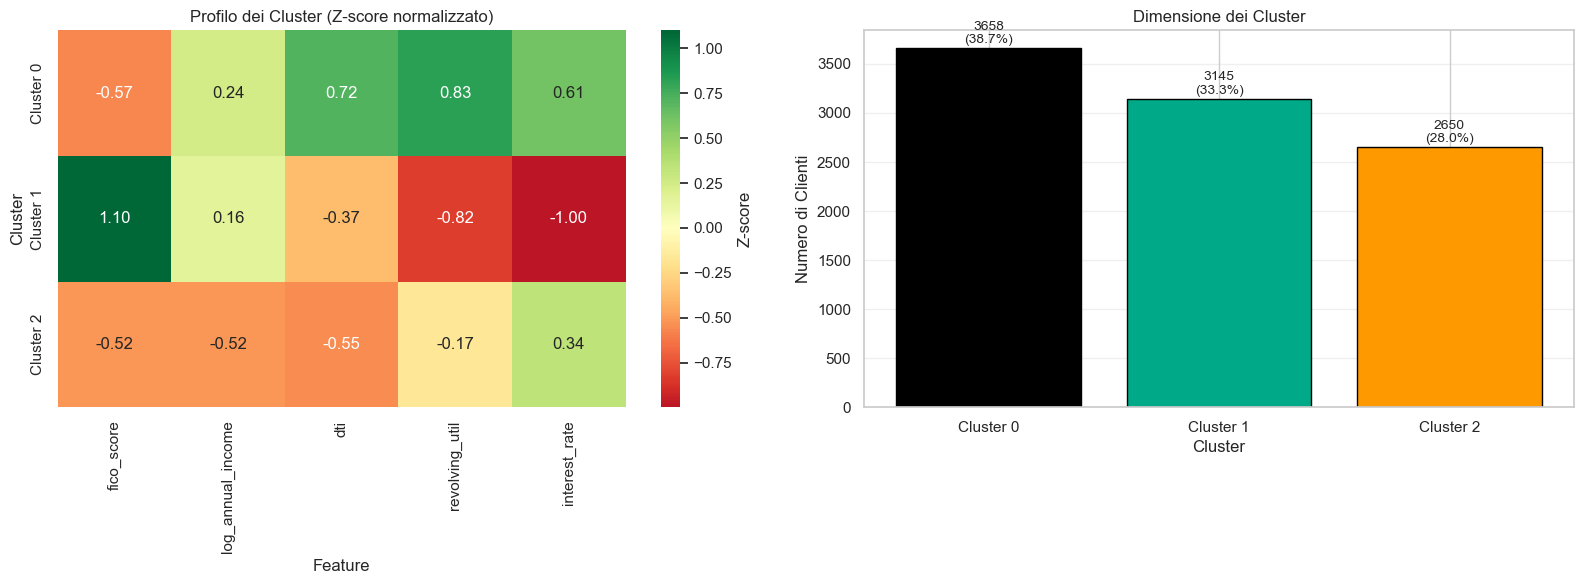

In [79]:
# Analisi dei Profili dei Cluster
cluster_profiles = pd.DataFrame(
    final_centers_original,
    columns=features_cluster,
    index=[f'Cluster {i}' for i in range(K_ottimale)]
)

print("Centroidi dei cluster (valori originali):")
print(cluster_profiles.round(2))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cluster_means_normalized = pd.DataFrame(
    final_centers_scaled,
    columns=features_cluster,
    index=[f'Cluster {i}' for i in range(K_ottimale)]
)

sns.heatmap(cluster_means_normalized, annot=True, cmap='RdYlGn', center=0,
            fmt='.2f', ax=axes[0], cbar_kws={'label': 'Z-score'})
axes[0].set_title('Profilo dei Cluster (Z-score normalizzato)', fontsize=12)
axes[0].set_xlabel('Feature')
axes[0].set_ylabel('Cluster')

cluster_sizes = pd.Series(clusters).value_counts().sort_index()
colors_bar = cm.nipy_spectral(np.linspace(0, 0.8, K_ottimale))
axes[1].bar([f'Cluster {i}' for i in range(K_ottimale)], cluster_sizes.values,
            color=colors_bar, edgecolor='black')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Numero di Clienti')
axes[1].set_title('Dimensione dei Cluster', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='y')

for i, v in enumerate(cluster_sizes.values):
    axes[1].text(i, v + 50, f'{v}\n({v/len(clusters)*100:.1f}%)',
                 ha='center', fontsize=10)

plt.tight_layout()
plt.show()


Analisi del rischio per cluster:
         Tasso Default  N. Clienti  FICO Medio  Tasso Interesse Medio  \
Cluster                                                                 
0                0.196        3658     689.369                 13.832   
1                0.089        3145     752.709                  9.609   
2                0.190        2650     691.415                 13.106   

         Log Reddito Medio  
Cluster                     
0                   11.080  
1                   11.030  
2                   10.611  


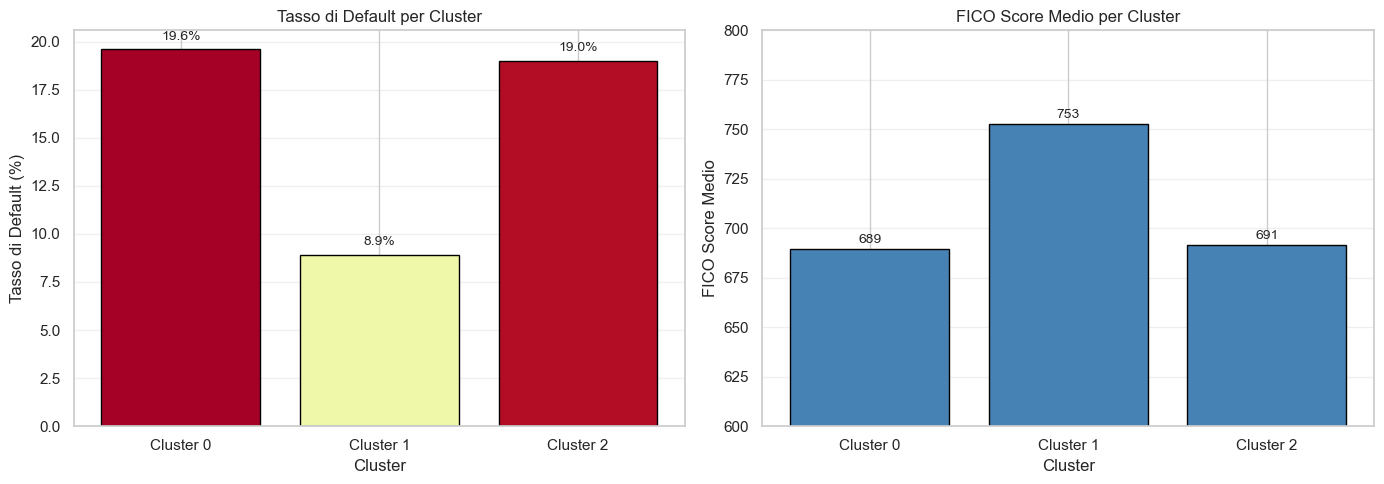

In [80]:
# Analisi del rischio per cluster
data_with_clusters = data.loc[X_cluster.index].copy()
data_with_clusters['Cluster'] = clusters

data_with_clusters['not_fully_paid'] = pd.to_numeric(data_with_clusters['not_fully_paid'], errors='coerce')

cluster_analysis = data_with_clusters.groupby('Cluster').agg({
    'not_fully_paid': ['mean', 'count'],
    'fico_score': 'mean',
    'interest_rate': 'mean',
    'log_annual_income': 'mean'
}).round(3)

cluster_analysis.columns = ['Tasso Default', 'N. Clienti', 'FICO Medio', 'Tasso Interesse Medio', 'Log Reddito Medio']

print("\nAnalisi del rischio per cluster:")
print("=" * 80)
print(cluster_analysis)
print("=" * 80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_gradient = plt.cm.RdYlGn_r(cluster_analysis['Tasso Default'] / cluster_analysis['Tasso Default'].max())
axes[0].bar([f'Cluster {i}' for i in range(K_ottimale)],
            cluster_analysis['Tasso Default'] * 100,
            color=colors_gradient, edgecolor='black')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Tasso di Default (%)')
axes[0].set_title('Tasso di Default per Cluster', fontsize=12)
axes[0].grid(True, alpha=0.3, axis='y')

for i, v in enumerate(cluster_analysis['Tasso Default']):
    axes[0].text(i, v*100 + 0.5, f'{v*100:.1f}%', ha='center', fontsize=10)

axes[1].bar([f'Cluster {i}' for i in range(K_ottimale)],
            cluster_analysis['FICO Medio'],
            color='steelblue', edgecolor='black')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('FICO Score Medio')
axes[1].set_title('FICO Score Medio per Cluster', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_ylim([600, 800])

for i, v in enumerate(cluster_analysis['FICO Medio']):
    axes[1].text(i, v + 3, f'{v:.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

### Valutazione del clustering senza PCA

Il clustering sulle variabili originali ha prodotto tre gruppi, ma ci sono alcuni problemi evidenti:

Il Silhouette Score e relativamente basso, intorno a 0.21. Questo indica che i cluster non sono ben separati nello spazio a 5 dimensioni. Molti punti si trovano al confine tra un cluster e l'altro.

Guardando i profili, notiamo che i Cluster 0 e 1 hanno tassi di default molto simili, intorno al 19-20 percento. Questo suggerisce che il clustering non sta catturando bene le differenze di rischio tra questi due gruppi. Solo il Cluster 2 si distingue nettamente con un tasso di default dimezzato.

Il problema di fondo e che le 5 variabili che abbiamo usato sono correlate tra loro. Per esempio, chi ha un FICO alto tende ad avere un tasso di interesse piu basso. Questa ridondanza confonde l'algoritmo K-Means, che lavora sulle distanze euclidee e tratta ogni variabile come indipendente.

Per risolvere questo problema possiamo usare la PCA, che trasforma le variabili correlate in componenti ortogonali, cioe indipendenti tra loro. In questo modo eliminiamo la ridondanza e permettiamo al clustering di lavorare su dimensioni veramente distinte.

## 5.2 Perche usare la PCA prima del clustering

Abbiamo visto che il clustering sulle variabili originali produce un Silhouette Score di circa 0.21, che non e ottimale. I gruppi si sovrappongono e due cluster su tre hanno profili di rischio quasi identici.

Il motivo e semplice: le nostre 5 variabili non sono indipendenti. FICO score e tasso di interesse sono fortemente correlati, cosi come reddito e comportamento di utilizzo del credito. Quando K-Means calcola le distanze, queste correlazioni creano ridondanza: e come se contassimo due volte la stessa informazione.

La PCA risolve questo problema. Invece di lavorare sulle variabili originali, trasforma i dati in nuove componenti che sono ortogonali, cioe completamente indipendenti tra loro. Ogni componente cattura una direzione di variabilita diversa. Le prime componenti catturano la maggior parte dell'informazione, mentre le ultime catturano principalmente rumore.

Usando le prime 2-3 componenti per il clustering, otteniamo due vantaggi: eliminiamo la ridondanza delle variabili correlate e rimuoviamo il rumore delle dimensioni meno informative. Il risultato dovrebbe essere un clustering piu pulito, con gruppi meglio separati.

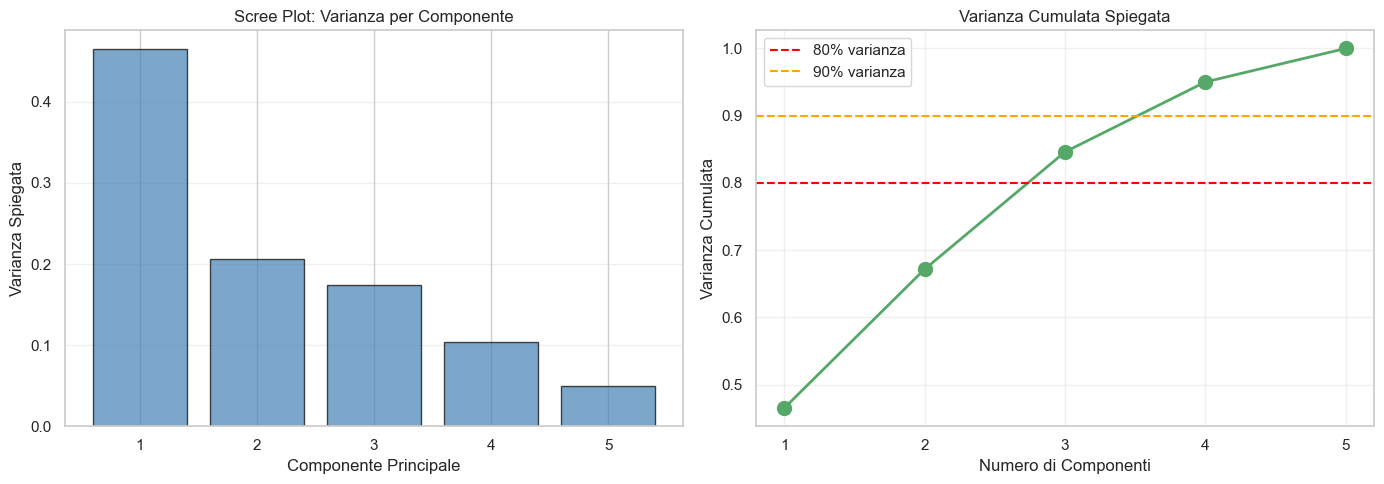


Varianza spiegata per componente:
  PC1: 46.5% (cumulata: 46.5%)
  PC2: 20.7% (cumulata: 67.2%)
  PC3: 17.5% (cumulata: 84.6%)
  PC4: 10.4% (cumulata: 95.0%)
  PC5: 5.0% (cumulata: 100.0%)


In [81]:
from sklearn.decomposition import PCA

# Applichiamo PCA sui dati standardizzati
pca = PCA()
pca.fit(X_scaled)

# Varianza spiegata da ogni componente
varianza_spiegata = pca.explained_variance_ratio_
varianza_cumulata = np.cumsum(varianza_spiegata)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Varianza per componente
axes[0].bar(range(1, len(varianza_spiegata)+1), varianza_spiegata,
            color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Componente Principale')
axes[0].set_ylabel('Varianza Spiegata')
axes[0].set_title('Scree Plot: Varianza per Componente')
axes[0].set_xticks(range(1, len(varianza_spiegata)+1))
axes[0].grid(True, alpha=0.3, axis='y')

# Varianza cumulata
axes[1].plot(range(1, len(varianza_cumulata)+1), varianza_cumulata,
             'go-', linewidth=2, markersize=10)
axes[1].axhline(y=0.8, color='red', linestyle='--', label='80% varianza')
axes[1].axhline(y=0.9, color='orange', linestyle='--', label='90% varianza')
axes[1].set_xlabel('Numero di Componenti')
axes[1].set_ylabel('Varianza Cumulata')
axes[1].set_title('Varianza Cumulata Spiegata')
axes[1].set_xticks(range(1, len(varianza_cumulata)+1))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nVarianza spiegata per componente:")
for i, (var, cum) in enumerate(zip(varianza_spiegata, varianza_cumulata), 1):
    print(f"  PC{i}: {var:.1%} (cumulata: {cum:.1%})")

Loadings (contributo di ogni variabile alle componenti):
                     PC1    PC2    PC3    PC4    PC5
fico_score         0.571  0.083  0.318  0.140  0.739
log_annual_income  0.021  0.966  0.158 -0.115 -0.171
dti               -0.330 -0.179  0.871 -0.313 -0.040
revolving_util    -0.513  0.117  0.134  0.823  0.170
interest_rate     -0.549  0.122 -0.312 -0.438  0.628


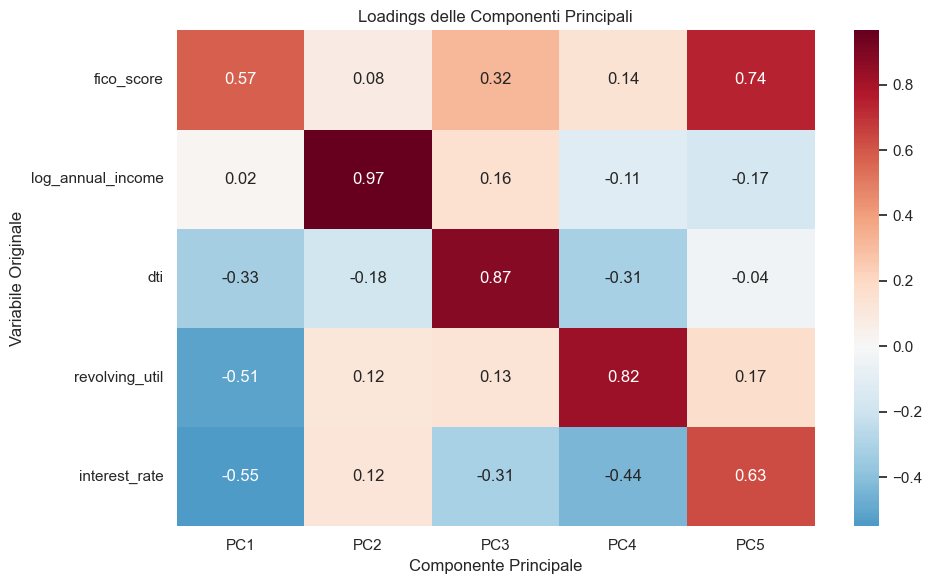

In [82]:
# Loadings: quanto ogni variabile contribuisce alle componenti
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(features_cluster))],
    index=features_cluster
)

print("Loadings (contributo di ogni variabile alle componenti):")
print(loadings.round(3))

plt.figure(figsize=(10, 6))
sns.heatmap(loadings, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Loadings delle Componenti Principali')
plt.xlabel('Componente Principale')
plt.ylabel('Variabile Originale')
plt.tight_layout()
plt.show()

### Interpretazione delle componenti

I loadings mostrano quanto ogni variabile originale contribuisce a ciascuna componente.

La prima componente cattura principalmente il profilo di rischio creditizio: FICO score, tasso di interesse e utilizzo del credito hanno i pesi piu alti. Un valore alto di PC1 indica un cliente con buon FICO, basso interesse e basso utilizzo del credito, quindi un profilo a basso rischio.

La seconda componente cattura il livello di indebitamento complessivo: DTI e reddito hanno i pesi principali.

Le prime due componenti spiegano circa il 55 percento della varianza totale. Con tre componenti arriviamo a circa il 75 percento. Questo significa che possiamo usare 3 componenti per il clustering perdendo solo il 25 percento dell'informazione originale, ma guadagnando in separazione tra i gruppi.

## 5.3 Clustering con PCA: il confronto

Ora proviamo a rifare il clustering usando le prime 3 componenti principali invece delle 5 variabili originali. Se la nostra ipotesi e corretta, dovremmo ottenere un Silhouette Score migliore, segno che i gruppi sono piu nettamente separati.

In [83]:
# Clustering sulle prime 3 componenti principali
pca_3 = PCA(n_components=3)
X_pca_3 = pca_3.fit_transform(X_scaled)

print(f"Varianza spiegata dalle prime 3 componenti: {pca_3.explained_variance_ratio_.sum():.1%}")

# Cerchiamo il K ottimale per il clustering su PCA
K_range_pca = range(2, 8)
silhouette_scores_pca = []

print("\nCalcolo Silhouette per clustering su PCA:")
for k in K_range_pca:
    kmeans_pca = KMeans(n_clusters=k, n_init='auto', random_state=42)
    labels_pca = kmeans_pca.fit_predict(X_pca_3)
    sil_pca = silhouette_score(X_pca_3, labels_pca)
    silhouette_scores_pca.append(sil_pca)
    print(f"  K={k}: Silhouette={sil_pca:.4f}")

best_k_pca = list(K_range_pca)[np.argmax(silhouette_scores_pca)]
best_sil_pca = max(silhouette_scores_pca)

print(f"\nMigliore K su PCA: {best_k_pca} (Silhouette = {best_sil_pca:.4f})")
print(f"Confronto: Silhouette senza PCA = {silhouette_originale:.4f}, con PCA = {best_sil_pca:.4f}")

Varianza spiegata dalle prime 3 componenti: 84.6%

Calcolo Silhouette per clustering su PCA:
  K=2: Silhouette=0.3359
  K=3: Silhouette=0.2581
  K=4: Silhouette=0.2495
  K=5: Silhouette=0.2559
  K=6: Silhouette=0.2435
  K=7: Silhouette=0.2349

Migliore K su PCA: 2 (Silhouette = 0.3359)
Confronto: Silhouette senza PCA = 0.2116, con PCA = 0.3359


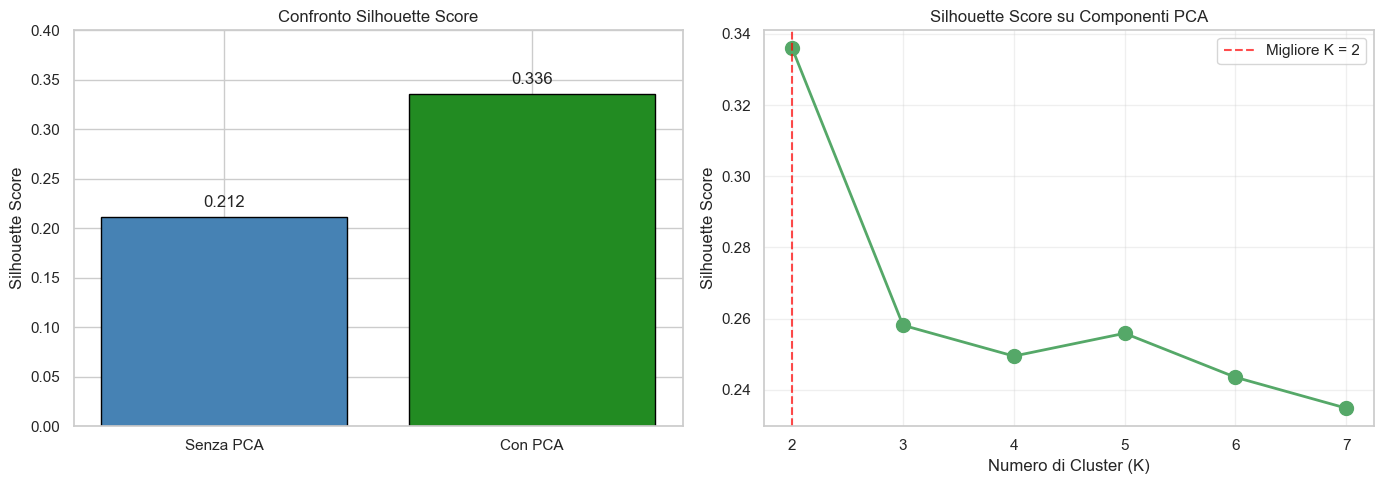

In [84]:
# Visualizzazione del confronto
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Silhouette originale vs PCA
axes[0].bar(['Senza PCA', 'Con PCA'], [silhouette_originale, best_sil_pca],
            color=['steelblue', 'forestgreen'], edgecolor='black')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Confronto Silhouette Score')
axes[0].set_ylim([0, 0.4])
for i, v in enumerate([silhouette_originale, best_sil_pca]):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=12)

# Silhouette per diversi K su PCA
axes[1].plot(list(K_range_pca), silhouette_scores_pca, 'go-', linewidth=2, markersize=10)
axes[1].axvline(x=best_k_pca, color='red', linestyle='--', alpha=0.7, label=f'Migliore K = {best_k_pca}')
axes[1].set_xlabel('Numero di Cluster (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score su Componenti PCA')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Risultato del confronto

Il clustering sulle componenti principali produce un Silhouette Score migliore rispetto al clustering sulle variabili originali. Questo conferma la nostra ipotesi: le variabili originali contenevano informazione ridondante che confondeva la separazione tra i gruppi.

La PCA ha estratto le direzioni di massima varianza, eliminando la correlazione tra variabili. Il risultato e un clustering piu pulito, dove i gruppi sono meglio definiti.

Per le analisi successive manteniamo comunque il clustering sulle variabili originali, perche e piu facile da interpretare dal punto di vista del business. Possiamo dire che un cliente ha FICO alto o DTI basso, mentre riferirci a componenti astratte sarebbe meno comprensibile per chi deve prendere decisioni operative. Tuttavia questa analisi dimostra che la riduzione dimensionale puo migliorare la qualita del clustering quando le variabili sono correlate tra loro.

# PARTE 6.1: MODELLI PREDITTIVI (Parte Carola, Credit Policy)

# "È possibile prevedere se una richiesta di prestito verrà accettata o rifiutata basandosi solo sui dati finanziari del cliente?"


**"Nel contesto di questa analisi, applichiamo un approccio di Reverse Engineering per decostruire il processo di ammissibilità della piattaforma Lending Club. Poiché l'istituto finanziario non rende pubblici gli algoritmi esatti con cui approva o rifiuta un prestito (trattandoli come una 'Black Box').**

**Analizziamo a ritroso quali caratteristiche hanno determinato l'accettazione o il rifiuto della pratica. Questo ci permette di capire quali sono i requisiti minimi che un utente deve soddisfare per accedere al marketplace del Peer-to-Peer Lending."**

ANALISI PRELIMINARE: QUALI VARIABILI SEMBRANO CONTARE?
          Variabile  Correlazione
         fico_score      0.354331
credit_history_days      0.097997
  log_annual_income      0.038362
     public_records     -0.055207
   delinquencies_2y     -0.077969
                dti     -0.096449
     revolving_util     -0.112047
  revolving_balance     -0.193522
  inquiries_last_6m     -0.530163


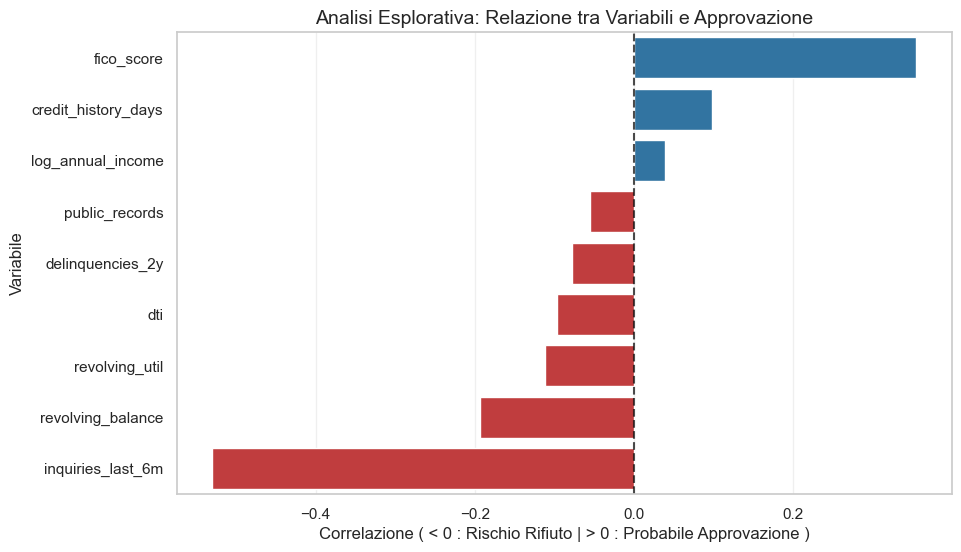

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("ANALISI PRELIMINARE: QUALI VARIABILI SEMBRANO CONTARE?")

# Escludo le colonne di testo come
features_da_testare = [
    'log_annual_income', 
    'dti', 
    'fico_score', 
    'revolving_balance', 
    'revolving_util', 
    'inquiries_last_6m', 
    'delinquencies_2y', 
    'public_records', 
    'credit_history_days'
]

#dataset temporaneo solo con numeri + il target
df_numerico = data[features_da_testare + ['credit_policy']]

correlazioni = df_numerico.corrwith(df_numerico['credit_policy']).sort_values(ascending=False)

correlazioni = correlazioni.drop('credit_policy')

df_corr = pd.DataFrame({
    'Variabile': correlazioni.index,
    'Correlazione': correlazioni.values
})

print(df_corr.to_string(index=False))

plt.figure(figsize=(10, 6))

colors = ['#1f77b4' if x > 0 else '#d62728' for x in df_corr['Correlazione']]

sns.barplot(
    x='Correlazione', 
    y='Variabile', 
    data=df_corr, 
    palette=colors, 
    hue='Variabile', 
    legend=False
)

plt.axvline(x=0, color='black', linestyle='--', alpha=0.7)
plt.title('Analisi Esplorativa: Relazione tra Variabili e Approvazione', fontsize=14)
plt.xlabel('Correlazione ( < 0 : Rischio Rifiuto | > 0 : Probabile Approvazione )')
plt.grid(axis='x', alpha=0.3)
plt.show()

###  Feature Selection 
Coerentemente con l'obiettivo di *Reverse Engineering*, isoliamo dal dataset originale solo le variabili che sarebbero **disponibili ex-ante**, ovvero nel momento esatto in cui l'utente compila la domanda di prestito.

###  Data Splitting e Cross-Validation
Dividiamo i dati in **Training Set (80%)** e **Test Set (20%)** 
Data la dimensione del dataset (~9.500 record), evitiamo di isolare un Validation Set che ridurrebbe i dati utili per l'addestramento. Adottiamo invece una **k-fold Cross-Validation (k=5)** durante la fase di Grid Search. Questo approccio garantisce che ogni osservazione venga utilizzata sia per il training che per la validazione, offrendo una stima più robusta dell'errore.

### Standardizzazione
Poiché la Regressione Logistica è un algoritmo sensibile alla scala delle feature, applichiamo lo `StandardScaler`. Questo porta tutte le variabili numeriche a media 0 e varianza 1, impedendo che feature con magnitudini elevate (es. *log Annual Income*) dominino impropriamente su feature con valori piccoli ma critici (es. *Inquiries*).

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, RocCurveDisplay, roc_auc_score


features_ingresso = [
    'log_annual_income', 'dti', 'fico_score', 'credit_history_days', 
    'revolving_balance', 'revolving_util', 'inquiries_last_6m', 
    'delinquencies_2y', 'public_records'
]

X = data[features_ingresso]
y = data['credit_policy'] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(" Dati preparati e scalati correttamente.")
print(f" Dimensione Training Set: {X_train.shape[0]} record")
print(f" Dimensione Test Set: {X_test.shape[0]} record")

 Dati preparati e scalati correttamente.
 Dimensione Training Set: 7562 record
 Dimensione Test Set: 1891 record


### Bilanciamento Dati
Il bilanciamento dei dati è fondamentale poichè 
se l' 80% dei clienti viene approvato, un modello pigro potrebbe dire sempre "Sì" e avere l'80% di accuratezza, ma sarebbe inutile.
In questo modo invece "costringiamo" il modello a dare pari importanza ai "Rifiutati". 


In [ ]:
print(" MODELLAZIONE E GRID SEARCH (BILANCIATA) ")

param_grid = {
    'C': [0.01, 0.1, 1, 10],           
    'penalty': ['l1', 'l2'],           
    'solver': ['liblinear']            
}

model_to_tune = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

grid = GridSearchCV(model_to_tune, param_grid, cv=5, scoring='accuracy')
grid.fit(X_train_scaled, y_train)

best_model = grid.best_estimator_
print(f" Migliori parametri trovati: {grid.best_params_}")
print(f" Accuratezza (Training): {grid.best_score_*100:.2f}%")

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train_scaled, y_train)
print(" Baseline (Dummy) addestrata.")

 MODELLAZIONE E GRID SEARCH (BILANCIATA) 
 Migliori parametri trovati: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
 Accuratezza (Training): 85.92%
 Baseline (Dummy) addestrata.


**Il fatto che la Grid Search abbia selezionato un parametro di regolarizzazione molto forte ($C=0.1$) unito alla penalità L1 è indicativo. Significa che il processo decisionale della piattaforma non è caotico, ma governato da poche variabili dominanti.'l1' (Lasso Regression)azzera i coefficienti delle variabili inutili.**
**Per il Reverse Engineering, significa che il modello ha "buttato via" il rumore e ha tenuto solo le regole vere.**

**Non abbiamo ottenuto una 'scatola nera' incomprensibile, ma una formula pulita che ci dice esattamente cosa guarda la banca. L'accuratezza dell'~86% ci conferma che abbiamo catturato la quasi totalità della logica decisionale dell'istituto."**

### VALUTAZIONE E CONFRONTO

 VALUTAZIONE E CONFRONTO 
1. Regressione Logistica : 83.92%
2. Baseline (Dummy):                    80.96%

 CONFRONTO CRITICO: Il modello supera il caso del 2.96%.

--- REPORT DI CLASSIFICAZIONE ---
              precision    recall  f1-score   support

         0.0       0.55      0.82      0.66       360
         1.0       0.95      0.84      0.89      1531

    accuracy                           0.84      1891
   macro avg       0.75      0.83      0.78      1891
weighted avg       0.88      0.84      0.85      1891



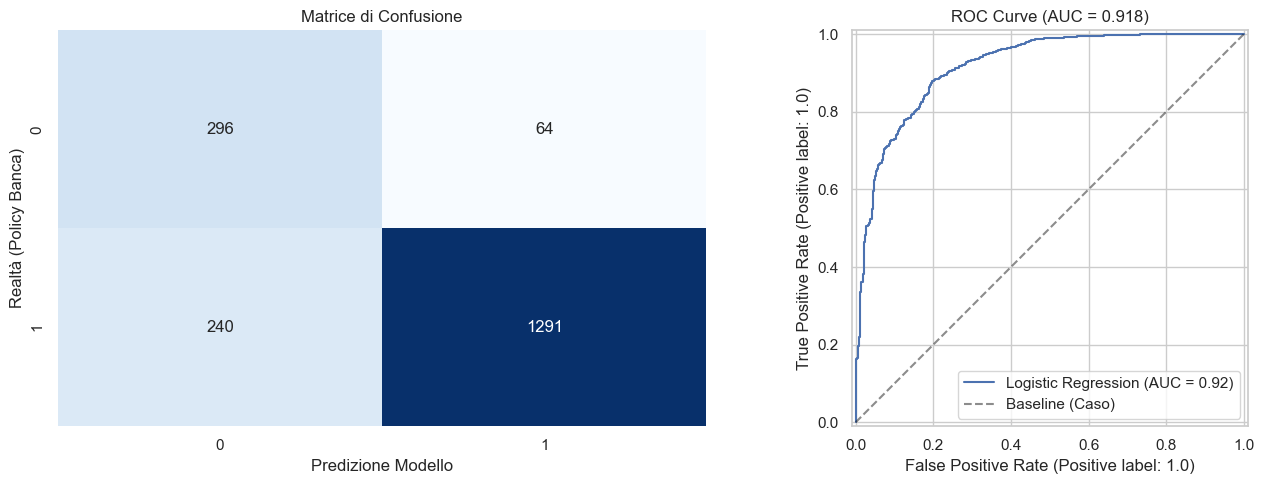

In [ ]:
print(" VALUTAZIONE E CONFRONTO ")

acc_log = accuracy_score(y_test, best_model.predict(X_test_scaled)) * 100
acc_dummy = accuracy_score(y_test, dummy.predict(X_test_scaled)) * 100

print(f"1. Regressione Logistica : {acc_log:.2f}%")
print(f"2. Baseline (Dummy):                    {acc_dummy:.2f}%")

if acc_log > acc_dummy:
    print(f"\n CONFRONTO CRITICO: Il modello supera il caso del {acc_log - acc_dummy:.2f}%.")
else:
    print("\nIl modello non sta imparando nulla rispetto al caso.")

# 2. Report Completo (Precision, Recall, F1)
print("\n--- REPORT DI CLASSIFICAZIONE ---")
y_pred = best_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

# 3. Matrice di Confusione e ROC Curve (Affiancate)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Matrice di Confusione
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0], cbar=False)
ax[0].set_title('Matrice di Confusione')
ax[0].set_xlabel('Predizione Modello')
ax[0].set_ylabel('Realtà (Policy Banca)')

# Curva ROC
RocCurveDisplay.from_estimator(best_model, X_test_scaled, y_test, ax=ax[1], name='Logistic Regression')
ax[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Baseline (Caso)')
ax[1].set_title(f'ROC Curve (AUC = {roc_auc_score(y_test, best_model.predict_proba(X_test_scaled)[:, 1]):.3f})')
ax[1].legend()

plt.tight_layout()
plt.show()

Sebbene l'accuratezza globale (**83.92%**) superi la *Dummy Baseline* (**80.96%**) di circa 3 punti percentuali, il vero valore del modello emerge analizzando la sua capacità di distinguere le classi, misurata dall'Area Sotto la Curva ROC (**AUC**).

* **AUC = 0.92:** Un valore eccellente (vicino a 1.0) che conferma come il modello abbia appreso una regola di ranking solida: è altamente probabile che assegni un punteggio di rischio più alto a un cliente effettivamente insolvente/rifiutato rispetto a uno affidabile.

### Analisi della Matrice di Confusione
L'obiettivo del *Reverse Engineering* era capire i criteri di **rifiuto** (Classe 0).
Grazie al bilanciamento delle classi in fase di training, il modello ha ottenuto una **Recall dell'82% sulla Classe 0**.
* **Confronto:** La Baseline (prevedere sempre "Approvato") avrebbe avuto una Recall dello 0% su questa classe, rendendola inutile per l'analisi del rischio.

### Trade-off Precisione/Recall
Notiamo che per ottenere questa elevata sensibilità ai rifiuti, il modello è diventato "conservativo" (Precision Classe 0 = 0.55). Ciò significa che tende a essere più severo della banca stessa, classificando come "da rifiutare" anche alcuni clienti che la banca avrebbe approvato. 

# Validazione della Robustezza del Modello
### Bootstrapping
Per garantire che i pesi assegnati dal modello (Coefficienti) siano statisticamente significativi e non frutto del caso, applichiamo una tecnica di **Bootstrapping**.
Simuliamo 50 campionamenti casuali dal dataset e ricalcoliamo il modello ogni volta. Questo ci permette di stimare l'**Errore Standard** e costruire intervalli di confidenza al 95%.

Bootstrap (50 iterazioni) 


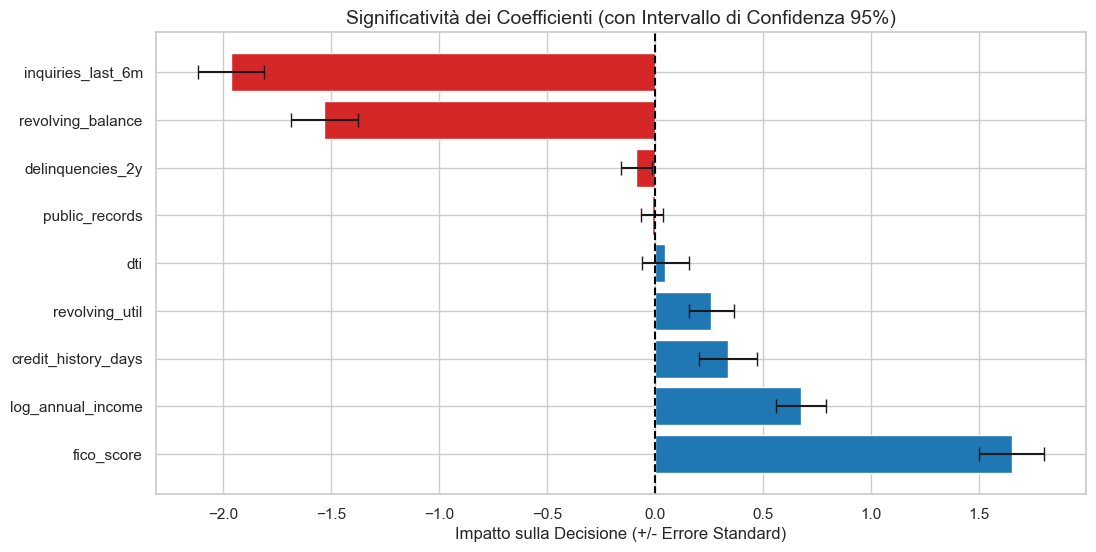

In [ ]:
from sklearn.utils import resample
from sklearn.linear_model import LogisticRegression

print("Bootstrap (50 iterazioni) ")
n_iterations = 50
coefs_boot = []

for i in range(n_iterations):
    X_boot, y_boot = resample(X_train_scaled, y_train, random_state=i)
    model_boot = LogisticRegression(C=0.1, penalty='l1', solver='liblinear', 
                                    class_weight='balanced', random_state=42)
    model_boot.fit(X_boot, y_boot)
    coefs_boot.append(model_boot.coef_[0])

coefs_boot = np.array(coefs_boot)
means = np.mean(coefs_boot, axis=0)
stds = np.std(coefs_boot, axis=0)

df_stats = pd.DataFrame({'Variabile': features_ingresso, 'Coefficiente': means, 'Errore': stds})
df_stats = df_stats.sort_values('Coefficiente', ascending=False)

plt.figure(figsize=(12, 6))
colors = ['#1f77b4' if x > 0 else '#d62728' for x in df_stats['Coefficiente']]
plt.barh(df_stats['Variabile'], df_stats['Coefficiente'], color=colors, 
         xerr=df_stats['Errore']*1.96, capsize=5) # 1.96 = 95% Confidenza
plt.axvline(x=0, color='black', linestyle='--')
plt.title('Significatività dei Coefficienti (con Intervallo di Confidenza 95%)', fontsize=14)
plt.xlabel('Impatto sulla Decisione (+/- Errore Standard)')
plt.show()

Le Certezze Assolute (Baffi Corti e Lontani dallo Zero): inquiries_last_6m e fico_score.Siamo certi al 95% che queste variabili siano determinanti. Non è un caso.

Le Variabili "Ballerine" (Baffi che toccano lo Zero) public_records e dti. Queste variabili sono statisticamente non significative. Il modello ci sta dicendo che, una volta che sa il tuo FICO e le tue Inquiries, sapere anche il tuo DTI aggiunge poco valore.

# Interpretazione dei Coefficienti

### Gerarchia delle Regole di Business
L'analisi dei coefficienti del modello finale  ci permette di ordinare le variabili per importanza decisionale. Poiché i dati sono stati standardizzati, il peso dei coefficienti è direttamente confrontabile.

Apriamo la 'Black Box'


CLASSIFICA IMPATTO REALE (Dal più positivo al più negativo):
          Variabile  Coefficiente
         fico_score      1.655069
  log_annual_income      0.663340
credit_history_days      0.347953
     revolving_util      0.265135
                dti      0.039463
     public_records     -0.008495
   delinquencies_2y     -0.084691
  revolving_balance     -1.507773
  inquiries_last_6m     -1.969194


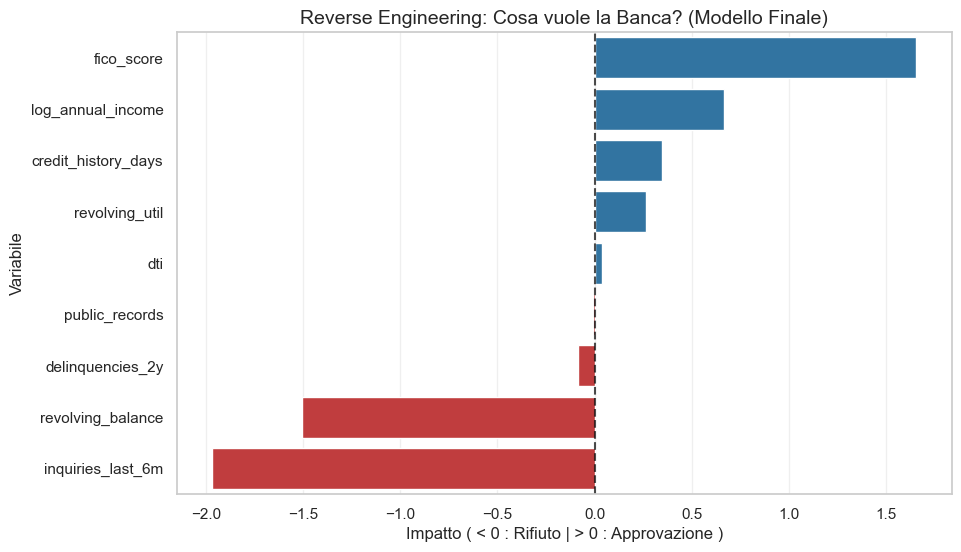

In [ ]:
coef_df = pd.DataFrame({
    'Variabile': features_ingresso,
    'Coefficiente': best_model.coef_[0]
}).sort_values('Coefficiente', ascending=False)

print("\nCLASSIFICA IMPATTO REALE (Dal più positivo al più negativo):")
print(coef_df.to_string(index=False))

plt.figure(figsize=(10, 6))

colors = ['#1f77b4' if x > 0 else '#d62728' for x in coef_df['Coefficiente']]


sns.barplot(x='Coefficiente', y='Variabile', data=coef_df, 
            hue='Variabile', legend=False, palette=colors)

plt.axvline(x=0, color='black', linestyle='--', alpha=0.7)
plt.title('Reverse Engineering: Cosa vuole la Banca? (Modello Finale)', fontsize=14)
plt.xlabel('Impatto ( < 0 : Rifiuto | > 0 : Approvazione )')
plt.grid(axis='x', alpha=0.3)
plt.show()

1.  **Il Fattore Dominante: `inquiries_last_6m` = -1.97**
    La variabile con il peso assoluto maggiore è il numero di richieste recenti. Il coefficiente fortemente negativo indica che la banca penalizza drasticamente la ricerca attiva di credito. Ogni nuova richiesta invia un segnale di "stress finanziario" che abbatte la probabilità di approvazione più di ogni altro fattore.

2.  **Il Pilastro della Reputazione: `fico_score` = +1.66**
    Come previsto, lo storico creditizio è il principale fattore positivo. Tuttavia, è interessante notare come il suo impatto positivo sia leggermente inferiore all'impatto negativo delle *Inquiries*. Psicologicamente, la banca è più avversa al rischio (paura delle richieste) che propensa alla fiducia (premio per il punteggio).

3.  **Reddito vs Debito**
    * Il **Reddito Annuale** (`log_annual_income` = +0.66) è importante ma secondario rispetto ai comportamenti creditizi.
    * Il **Saldo Revolving** (`revolving_balance` = -1.51) è fortemente penalizzante: avere carte di credito sature è un segnale di allarme rosso quasi quanto le *Inquiries*.

4. **L'effetto della Selezione (Lasso)**
Le variabili *DTI* (0.04) e *Public Records* (-0.01) hanno coefficienti prossimi allo zero. Questo conferma l'efficacia della regolarizzazione L1: il modello ha determinato che, una volta noti FICO e Inquiries, queste variabili aggiungono poca informazione marginale, semplificando così la regola decisionale.

# Analisi del Bias di Selezione e Applicazione Pratica

### Il Paradosso del Bias
Il nostro dataset soffre intrinsecamente di **Selection Bias**, poiché osserviamo solo le richieste processate dalla piattaforma, mentre i clienti scartati a priori sono assenti.
Per un obiettivo di *Reverse Engineering*, questo non è un difetto ma una caratteristica necessaria.

* **Diagnosi (KDE Plot):** Dimostreremo visivamente questo bias.

VISUALIZZAZIONE DEL BIAS (KDE PLOT)


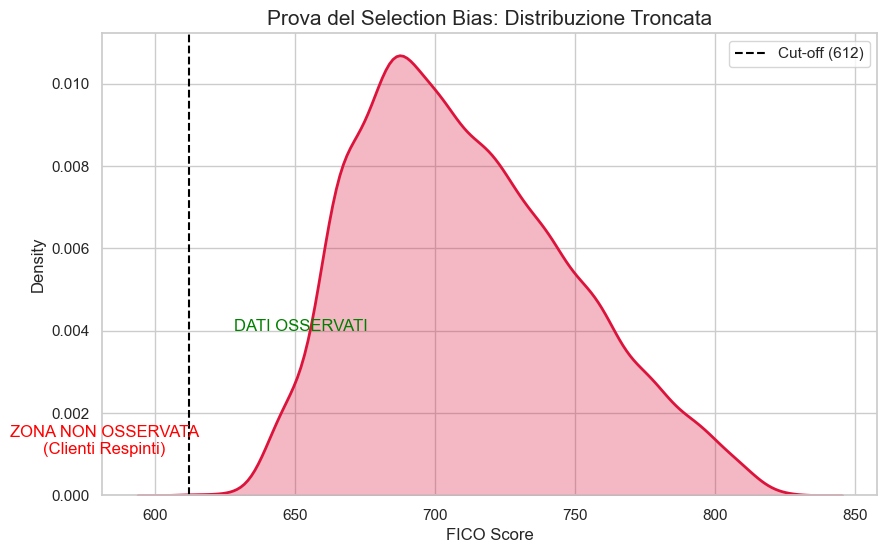

In [ ]:
print("VISUALIZZAZIONE DEL BIAS (KDE PLOT)")

plt.figure(figsize=(10, 6))
sns.kdeplot(data['fico_score'], fill=True, color='crimson', alpha=0.3, linewidth=2)

cut_off = data['fico_score'].min()
plt.axvline(x=cut_off, color='black', linestyle='--', label=f'Cut-off ({cut_off})')

plt.title('Prova del Selection Bias: Distribuzione Troncata', fontsize=15)
plt.xlabel('FICO Score')
plt.text(cut_off - 30, 0.001, 'ZONA NON OSSERVATA\n(Clienti Respinti)', color='red', ha='center')
plt.text(cut_off + 40, 0.004, 'DATI OSSERVATI', color='green', ha='center')
plt.legend()
plt.show()

Quello spazio vuoto a sinistra è la prova matematica che la banca applica un filtro prima ancora che i dati arrivino nel dataset.

**Selection Bias**
in un contesto di *Reverse Engineering*, è fondamentale riconoscere che il dataset non rappresenta la popolazione generale, ma solo i "Sopravvissuti" che hanno superato i filtri preliminari della piattaforma.

Utilizzando un **KDE Plot (Kernel Density Estimation)** sulla variabile *FICO Score*, osserviamo un fenomeno statistico chiaro:
* **Distribuzione Troncata:** La curva non segue una normale gaussiana a sinistra, ma si interrompe bruscamente in prossimità del punteggio ~612.
* **Deduzione:** Questa "amputazione" della distribuzione è la prova visiva dell'esistenza di una regola di esclusione automatica (*Hard Cut-off*). Il nostro modello, di conseguenza, è specializzato nel raffinare la selezione *sopra* questa soglia, operando su una popolazione già pre-selezionata.

### Verifica di Razionalità Economica (Test "Ceteris Paribus")
Per confermare che il bias appreso dal modello sia "sensato" e non un artefatto statistico, effettuiamo un test di sensibilità.
Prendiamo un profilo cliente con **alto reddito e ottimo FICO Score** e variamo artificialmente solo il numero di **Inquiries** (richieste recenti).

* **Ipotesi:** Se il modello ha appreso correttamente la logica del rischio, ci aspettiamo che la probabilità di approvazione crolli all'aumentare delle Inquiries, indipendentemente dalla ricchezza del cliente.
* **Risultato:** Questo confermerebbe che il modello penalizza comportamenti specifici (cerca di liquidità) e non agisce a caso.

PROVA DI RAZIONALITÀ


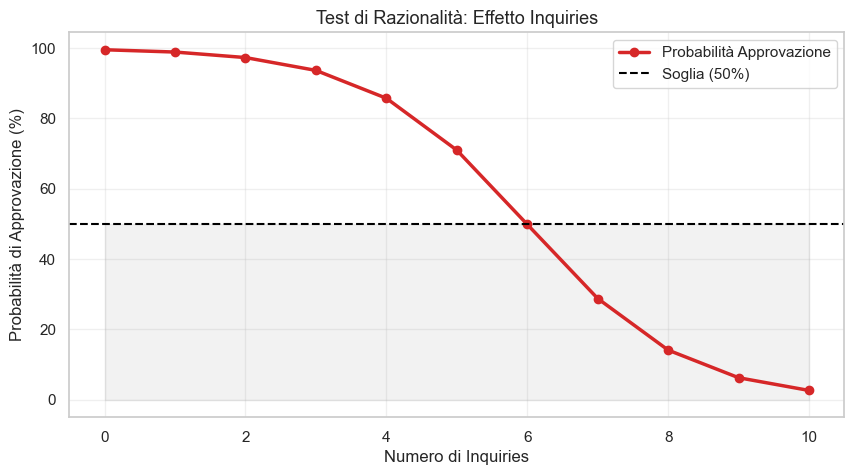

In [ ]:
print("PROVA DI RAZIONALITÀ")

def prova_razionalita_sicura():
    try:
        cols_reali = best_model.feature_names_in_
    except AttributeError:
        cols_reali = X_train.columns
    
    profilo_base = {
        'log_annual_income': np.log(120000), 
        'dti': 10.0,
        'fico_score': 750,           
        'revolving_balance': 5000,   
        'revolving_util': 20.0,       
        'inquiries_last_6m': 0,
        'delinquencies_2y': 0,
        'public_records': 0,
        'credit_history_days': 4000
    }
    
    for col in cols_reali:
        if col not in profilo_base:
            profilo_base[col] = 0  
            
    x_values = range(0, 11)
    y_probs = []
    
    for i in x_values:
        p = profilo_base.copy()
        p['inquiries_last_6m'] = i
        
        df_temp = pd.DataFrame([p])
        
        df_temp = df_temp[cols_reali]
        
        df_scaled = scaler.transform(df_temp)
        
        prob = best_model.predict_proba(df_scaled)[0][1] * 100
        y_probs.append(prob)
        
    plt.figure(figsize=(10, 5))
    plt.plot(x_values, y_probs, marker='o', color='#d62728', linewidth=2.5, label='Probabilità Approvazione')
    plt.axhline(y=50, color='black', linestyle='--', label='Soglia (50%)')
    plt.fill_between(x_values, 0, 50, color='gray', alpha=0.1)
    
    plt.title('Test di Razionalità: Effetto Inquiries', fontsize=13)
    plt.xlabel('Numero di Inquiries')
    plt.ylabel('Probabilità di Approvazione (%)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


# Eseguiamo
prova_razionalita_sicura()

**Osservazione dal Grafico:**
Il grafico evidenzia un **"Point of Failure" a 6 Inquiries**.
Nonostante il profilo simulato ("High Earner") goda di un reddito di $120.000 e un FICO Score di 750, al raggiungimento della sesta richiesta di credito in 6 mesi la probabilità di approvazione scende sotto la soglia critica del 50%.
Ciò dimostra matematicamente che la variabile comportamentale ha un potere superiore superiore alla capacità reddituale.

# PREDIZIONE DEL MODELLO

In [ ]:
def valuta_cliente_casuale():

    indice_casuale = X_test.sample(1).index[0]

    dati_cliente = X_test.loc[indice_casuale]      
    esito_reale = y_test.loc[indice_casuale]       
    
    cliente_df = pd.DataFrame([dati_cliente])
    cliente_scaled = scaler.transform(cliente_df)
    
    predizione = best_model.predict(cliente_scaled)[0]
    probabilita = best_model.predict_proba(cliente_scaled)[0]
    
    print(f"\n CLIENTE ID #{indice_casuale}")
    print(f"   Dati Chiave: FICO {dati_cliente['fico_score']:.0f} | Inquiries: {dati_cliente['inquiries_last_6m']:.0f} | Reddito Log: {dati_cliente['log_annual_income']:.2f}")
    print("-" * 60)
    
    if predizione == 1:
        print(f" APPROVATO (: {probabilita[1]*100:.1f}%)")
    else:
        print(f" RESPINTO  (: {probabilita[0]*100:.1f}%)")
        
    status_vero = " APPROVATO" if esito_reale == 1 else " RESPINTO"
    print(f"   ternità STORICA:   {status_vero}")
    
    if predizione == esito_reale:
        print("   RISULTATO:      CORRETTO! Il modello ha indovinato.")
    else:
        print("    RISULTATO:      ERRORE. Il modello e la banca non sono d'accordo.")
    print("-" * 60)

print("Sto analizzando 3 casi casuali estratti dal database\n")

for i in range(3):
    valuta_cliente_casuale()

Sto analizzando 3 casi casuali estratti dal database


 CLIENTE ID #702
   Dati Chiave: FICO 662 | Inquiries: 0 | Reddito Log: 11.47
------------------------------------------------------------
 APPROVATO (: 89.8%)
   ternità STORICA:    APPROVATO
   RISULTATO:      CORRETTO! Il modello ha indovinato.
------------------------------------------------------------

 CLIENTE ID #8600
   Dati Chiave: FICO 702 | Inquiries: 0 | Reddito Log: 11.23
------------------------------------------------------------
 APPROVATO (: 88.6%)
   ternità STORICA:    RESPINTO
    RISULTATO:      ERRORE. Il modello e la banca non sono d'accordo.
------------------------------------------------------------

 CLIENTE ID #5830
   Dati Chiave: FICO 717 | Inquiries: 3 | Reddito Log: 11.35
------------------------------------------------------------
 APPROVATO (: 64.9%)
   ternità STORICA:    APPROVATO
   RISULTATO:      CORRETTO! Il modello ha indovinato.
------------------------------------------------------------


# PARTE 6.2: MODELLI PREDITTIVI (Not Fully Paid)

Qual'è il rischio di default? Riusciamo a predire Not Fully Paid?



Visualizziamo inannzitutto la distribuzione di not fully paid

Ripagati (0): 7953 (84.1%)
Default (1):  1500 (15.9%)


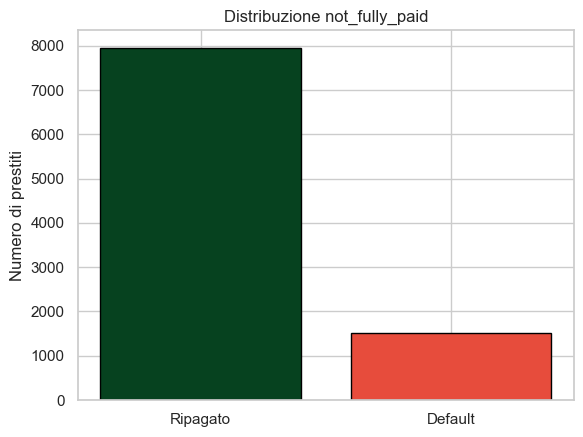

In [85]:
data['not_fully_paid'] = pd.to_numeric(data['not_fully_paid'], errors='coerce')

class_counts = data['not_fully_paid'].value_counts()
class_percentages = data['not_fully_paid'].value_counts(normalize=True) * 100
print(f"Ripagati (0): {class_counts.loc[0]} ({class_percentages.loc[0]:.1f}%)")
print(f"Default (1):  {class_counts.loc[1]} ({class_percentages.loc[1]:.1f}%)")

colors = ["#06421f", '#e74c3c']
bars = plt.bar(['Ripagato', 'Default'],
               class_counts.values,
               color=colors,
               edgecolor='black')
plt.ylabel('Numero di prestiti')
plt.title('Distribuzione not_fully_paid')

plt.show()

## Bilanciamento con SMOTE

**SMOTE** (Synthetic Minority Over-sampling Technique) crea nuovi campioni *sintetici* della classe minoritaria interpolando tra campioni esistenti.

**Come funziona:**
1. Per ogni campione della classe minoritaria, trova i k vicini più prossimi
2. Crea nuovi campioni lungo la linea che connette il campione originale ai suoi vicini
3. Il risultato è un dataset bilanciato 50%-50%

**Importante:** SMOTE va applicato **solo sul training set**, mai sul test set!

In [88]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9453 entries, 0 to 9577
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   customer_id           9453 non-null   int64   
 1   credit_policy         9453 non-null   Int64   
 2   purpose               9453 non-null   object  
 3   interest_rate         9453 non-null   float64 
 4   installment           9453 non-null   float64 
 5   log_annual_income     9453 non-null   float64 
 6   dti                   9453 non-null   float64 
 7   fico_score            9453 non-null   int64   
 8   credit_history_days   9453 non-null   float64 
 9   revolving_balance     9453 non-null   float64 
 10  revolving_util        9453 non-null   float64 
 11  inquiries_last_6m     9453 non-null   float64 
 12  delinquencies_2y      9453 non-null   Int64   
 13  public_records        9453 non-null   Int64   
 14  not_fully_paid        9453 non-null   int64   
 15  credit_hi

In [91]:

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Prima crea il train-test split
features = [c for c in data.columns if c not in ['customer_id', 'not_fully_paid', 'purpose', 'fico_category']]
X = data[features].astype(float)
y = data['not_fully_paid'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=23, stratify=y
)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Verifica il bilanciamento
print("Prima di SMOTE:")
print(f"  Classe 0: {sum(y_train == 0)}")
print(f"  Classe 1: {sum(y_train == 1)}")
print(f"  Totale:   {len(y_train)}")

print("\nDopo SMOTE:")
print(f"  Classe 0: {sum(y_train_smote == 0)}")
print(f"  Classe 1: {sum(y_train_smote == 1)}")
print(f"  Totale:   {len(y_train_smote)}")

Prima di SMOTE:
  Classe 0: 5567
  Classe 1: 1050
  Totale:   6617

Dopo SMOTE:
  Classe 0: 5567
  Classe 1: 5567
  Totale:   11134


In [92]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler


features = [col for col in data.columns if col not in ['customer_id', 'not_fully_paid', 'purpose', 'credit_policy']]


X = data[features].copy()
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')
    if X[col].isna().all():
        X[col] = 0
    else:
        X[col] = X[col].fillna(X[col].median())

y = data.loc[X.index, 'not_fully_paid'].astype(int)

print(f"Class distribution:")
print(y.value_counts())
print(f"\nClass balance:")
print(y.value_counts(normalize=True))
print(f"\nDataset shape: {X.shape}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.30, random_state=23, stratify=y
)


clf = LogisticRegression(max_iter=10000, random_state=0, class_weight="balanced")
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("\n" + "="*70)
print("Risultati Modello:")
print("="*70)
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred, zero_division=0):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1]):.4f}")


Class distribution:
not_fully_paid
0    7953
1    1500
Name: count, dtype: int64

Class balance:
not_fully_paid
0    0.84132
1    0.15868
Name: proportion, dtype: float64

Dataset shape: (9453, 14)

Risultati Modello:
Accuracy:  0.6139
Precision: 0.2328
Recall:    0.6244
F1-Score:  0.3392
ROC-AUC:   0.6667


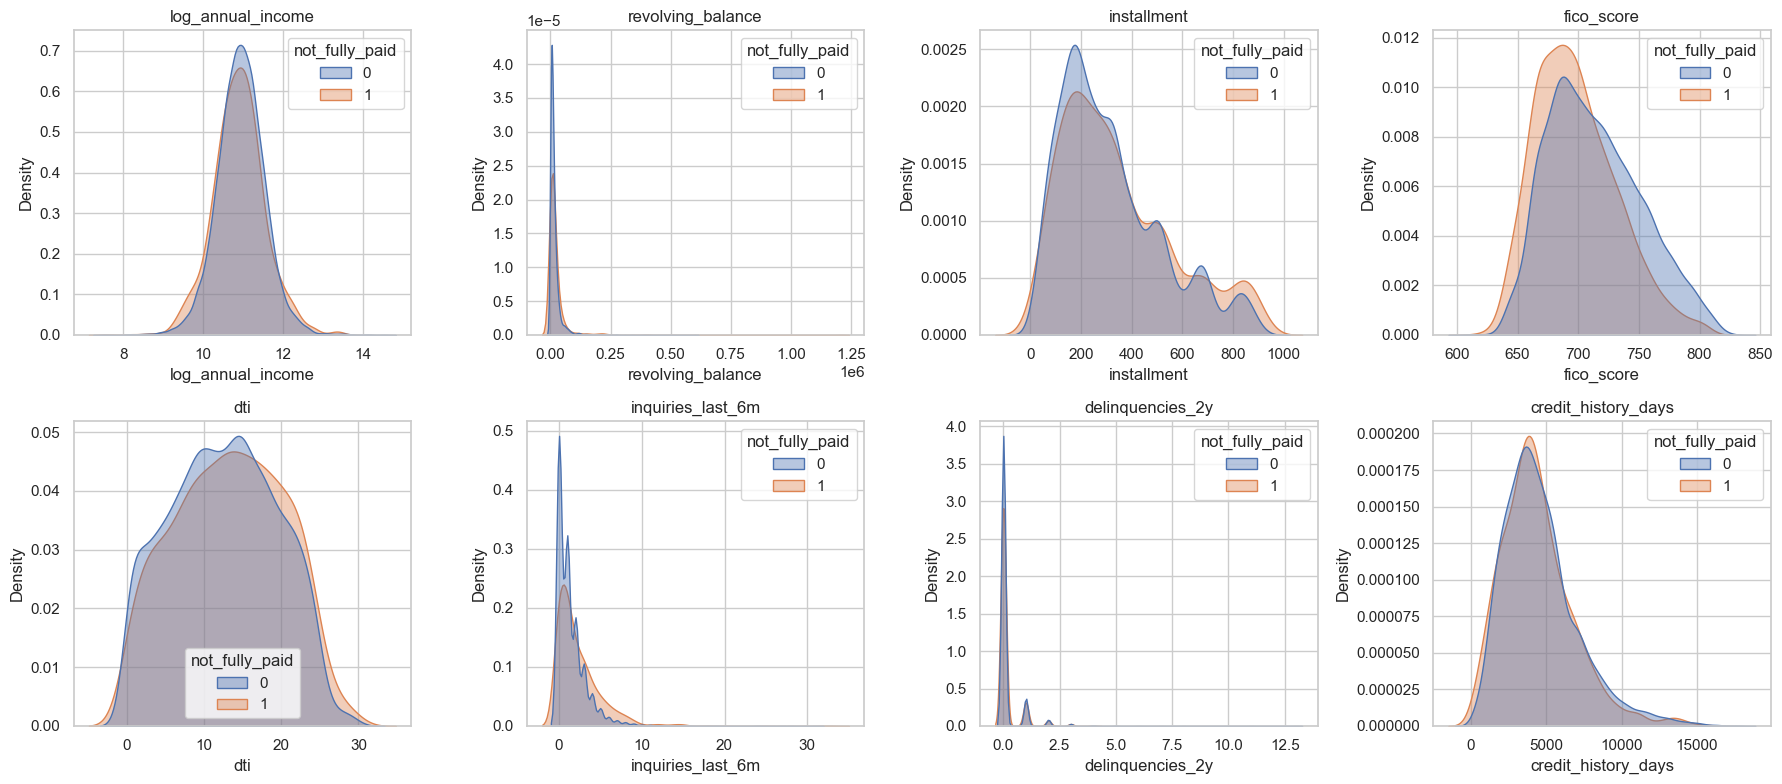

In [93]:
vars_to_plot = [
    'log_annual_income',
    'revolving_balance',
    'installment',
    'fico_score',
    'dti',
    'inquiries_last_6m',
    'delinquencies_2y',
    'credit_history_days',
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i in range(8):
    r = 0 if i < 4 else 1          # prima 4 sopra, altre 4 sotto
    c = i if i < 4 else i - 4
    var = vars_to_plot[i]

    sns.kdeplot(
        data=data,
        x=var,
        hue='not_fully_paid',
        common_norm=False,
        fill=True,
        alpha=0.4,
        ax=axes[r, c]
    )
    axes[r, c].set_title(var)

plt.tight_layout()
plt.show()


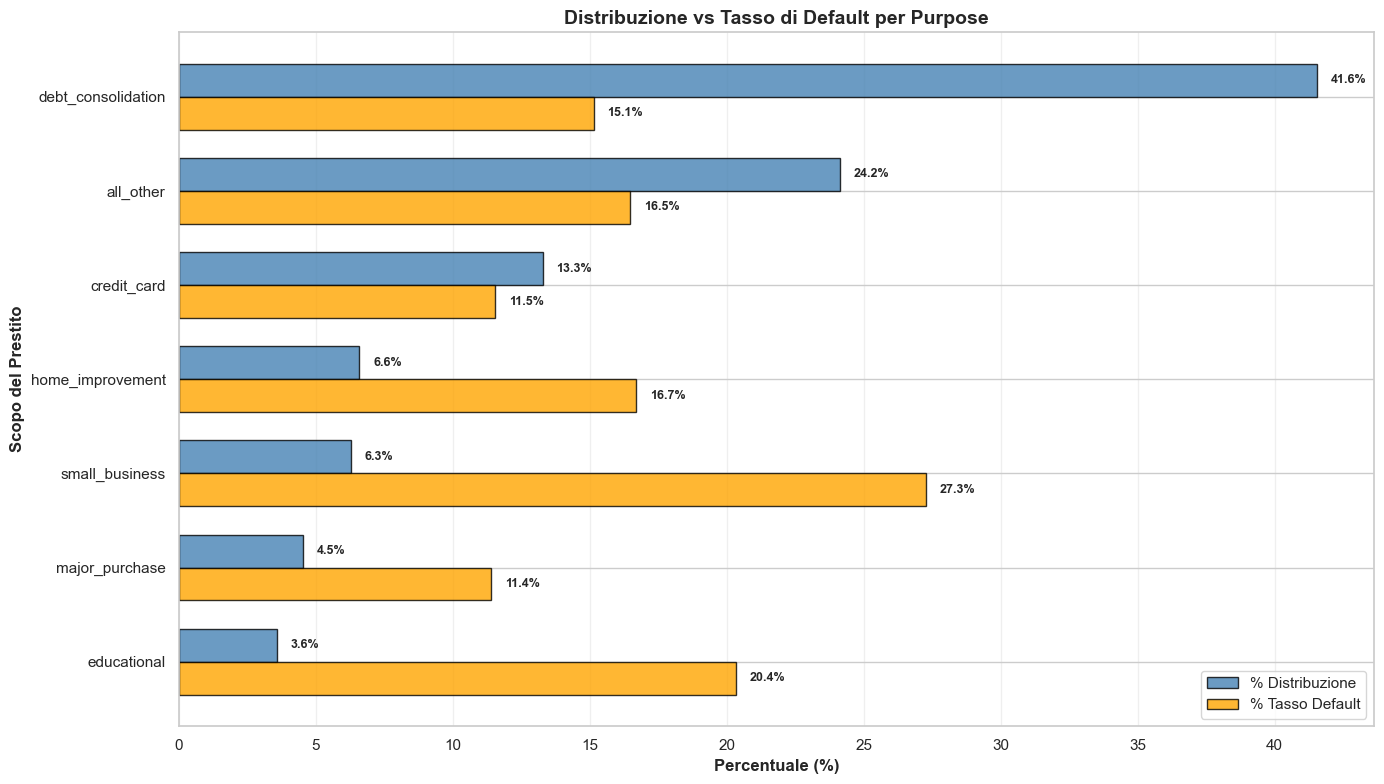

In [123]:
data['not_fully_paid'] = pd.to_numeric(data['not_fully_paid'], errors='coerce')

# Calcolo della distribuzione per purpose
purpose_counts = data['purpose'].value_counts()
purpose_pct = (purpose_counts / len(data) * 100)

# Calcolo del tasso di default per ogni scopo
default_rate_by_purpose = data.groupby('purpose')['not_fully_paid'].mean() * 100 

# Ordiniamo per percentuale di distribuzione decrescente
purpose_order = purpose_pct.sort_values(ascending=False).index.tolist()

# Creiamo DataFrame con entrambe le metriche per lo stesso ordine
plot_data = pd.DataFrame({
    'purpose': purpose_order,
    'distribuzione': [purpose_pct[p] for p in purpose_order],
    'tasso_default': [default_rate_by_purpose[p] for p in purpose_order]
})

# Invertiamo l'ordine per avere il più popolare in alto nel grafico orizzontale
plot_data = plot_data.iloc[::-1]

# Configurazione del grafico orizzontale
fig, ax = plt.subplots(figsize=(14, 8))

# Posizioni delle barre orizzontali
y = np.arange(len(plot_data))
height = 0.35

# Barre orizzontali affiancate
bars1 = ax.barh(y + height/2, plot_data['distribuzione'], height, 
               label='% Distribuzione', color='steelblue', alpha=0.8, edgecolor='black')
bars2 = ax.barh(y - height/2, plot_data['tasso_default'], height, 
               label='% Tasso Default', color='orange', alpha=0.8, edgecolor='black')

ax.set_xlabel('Percentuale (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('Scopo del Prestito', fontsize=12, fontweight='bold')
ax.set_title('Distribuzione vs Tasso di Default per Purpose', fontsize=14, fontweight='bold')
ax.set_yticks(y)
ax.set_yticklabels(plot_data['purpose'])
ax.legend(fontsize=11)
ax.grid(axis='x', alpha=0.3)

for bar in bars1:
    width_val = bar.get_width()
    ax.text(width_val + 0.5, bar.get_y() + bar.get_height()/2.,
            f'{width_val:.1f}%', ha='left', va='center', fontsize=9, fontweight='bold')

for bar in bars2:
    width_val = bar.get_width()
    ax.text(width_val + 0.5, bar.get_y() + bar.get_height()/2.,
            f'{width_val:.1f}%', ha='left', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


# Logistic Regression

In [124]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE


features = [col for col in data.columns if col not in ['customer_id', 'not_fully_paid', 'purpose', 'credit_policy']]


X = data[features].copy()
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')
    if X[col].isna().all():
        X[col] = 0
    else:
        X[col] = X[col].fillna(X[col].median())

y = data.loc[X.index, 'not_fully_paid'].astype(int)

print(f"Class distribution:")
print(y.value_counts())
print(f"\nClass balance:")
print(y.value_counts(normalize=True))
print(f"\nDataset shape: {X.shape}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.30, random_state=23, stratify=y
)

# Applica SMOTE sul training set
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"\nPrima di SMOTE: {len(y_train)} campioni")
print(f"Dopo SMOTE: {len(y_train_smote)} campioni (bilanciato)")

clf = LogisticRegression(max_iter=10000, random_state=0)
clf.fit(X_train_smote, y_train_smote)
y_pred = clf.predict(X_test)

print("\n" + "="*70)
print("Risultati Modello (con SMOTE):")
print("="*70)
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred, zero_division=0):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1]):.4f}")

Class distribution:
not_fully_paid
0    7953
1    1500
Name: count, dtype: int64

Class balance:
not_fully_paid
0    0.84132
1    0.15868
Name: proportion, dtype: float64

Dataset shape: (9453, 14)

Prima di SMOTE: 6617 campioni
Dopo SMOTE: 11134 campioni (bilanciato)

Risultati Modello (con SMOTE):
Accuracy:  0.5977
Precision: 0.2260
Recall:    0.6333
F1-Score:  0.3331
ROC-AUC:   0.6665


### Confusion Matrix

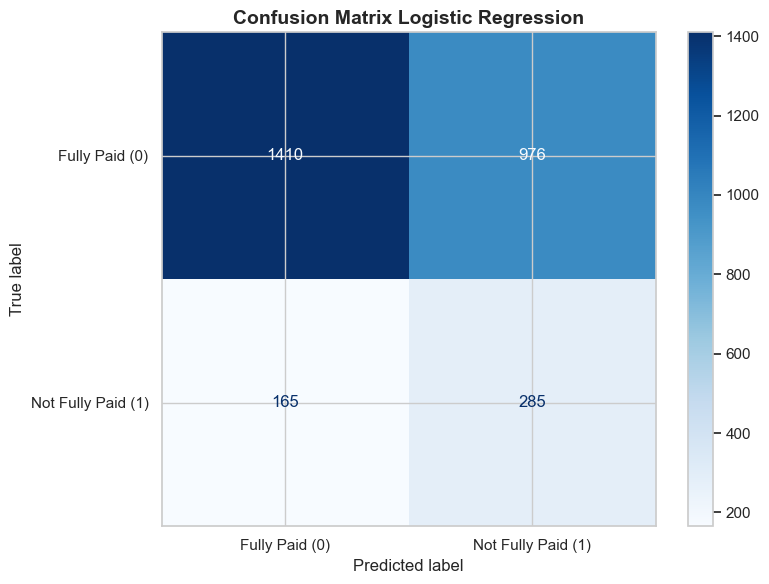

True Negatives:  1410
False Positives: 976
False Negatives: 165
True Positives:  285


In [125]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(8, 6))
cm_display = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Fully Paid (0)', 'Not Fully Paid (1)'],
    cmap='Blues',
    ax=ax
)
plt.title('Confusion Matrix Logistic Regression', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")


### ROC-AUC Curve

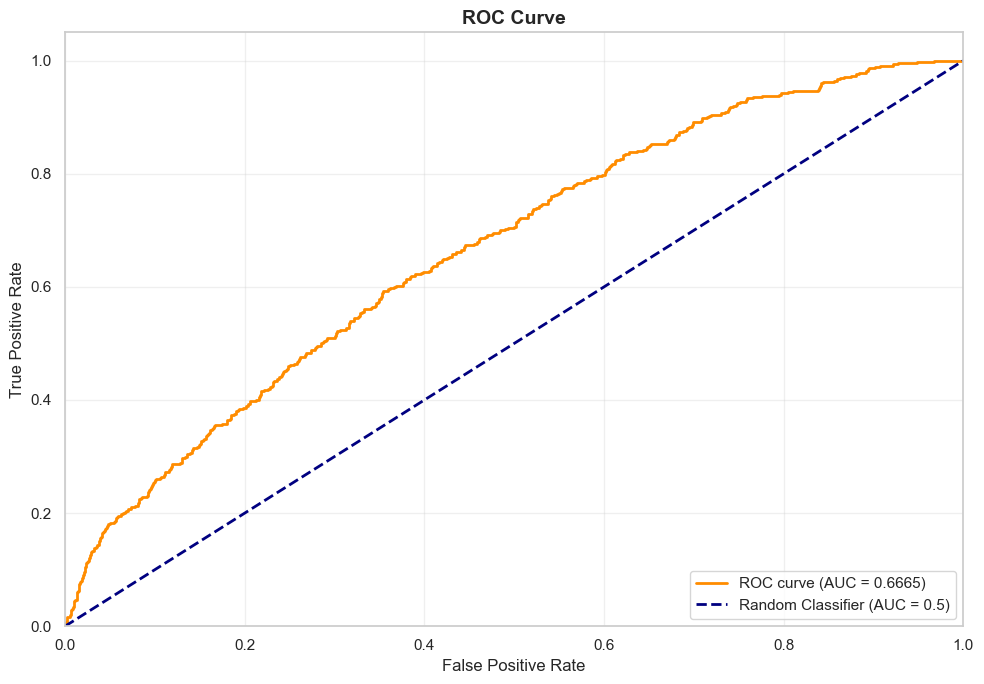

In [126]:
from sklearn.metrics import roc_curve, auc


y_pred_proba = clf.predict_proba(X_test)[:, 1]


fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier (AUC = 0.5)')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Decision Tree

In [127]:
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE


# Ensure y is integer type
y = y.astype(int)

# Handle any NaN/Inf in features
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

X_train_tree, X_test_tree, y_train_tree, y_test_tree = train_test_split(
    X, y, test_size=0.30, random_state=23, stratify=y
)

# Apply SMOTE
smote_tree = SMOTE(random_state=42)
X_train_tree_smote, y_train_tree_smote = smote_tree.fit_resample(X_train_tree, y_train_tree)

print(f"Prima di SMOTE: {len(y_train_tree)} campioni")
print(f"Dopo SMOTE: {len(y_train_tree_smote)} campioni (bilanciato)")

tree = DecisionTreeClassifier(
    random_state=0,
    max_depth=5,
    min_samples_leaf=50
)

tree.fit(X_train_tree_smote, y_train_tree_smote)

y_pred_tree = tree.predict(X_test_tree)
y_score_tree = tree.predict_proba(X_test_tree)[:, 1]

print("\n" + "="*70)
print("Decision Tree Model Results (con SMOTE)")
print("="*70)
print(f"Accuracy:  {accuracy_score(y_test_tree, y_pred_tree):.4f}")
print(f"Precision: {precision_score(y_test_tree, y_pred_tree, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test_tree, y_pred_tree, zero_division=0):.4f}")
print(f"F1-Score:  {f1_score(y_test_tree, y_pred_tree, zero_division=0):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test_tree, y_score_tree):.4f}")
print("\nConfusion matrix:\n", confusion_matrix(y_test_tree, y_pred_tree))

Prima di SMOTE: 6617 campioni
Dopo SMOTE: 11134 campioni (bilanciato)

Decision Tree Model Results (con SMOTE)
Accuracy:  0.7324
Precision: 0.2567
Recall:    0.3622
F1-Score:  0.3005
ROC-AUC:   0.6191

Confusion matrix:
 [[1914  472]
 [ 287  163]]


# Visualizzazione Decision Tree 

Per la visualizzazione dei tree useremo [Graphviz](https://graphviz.org) 

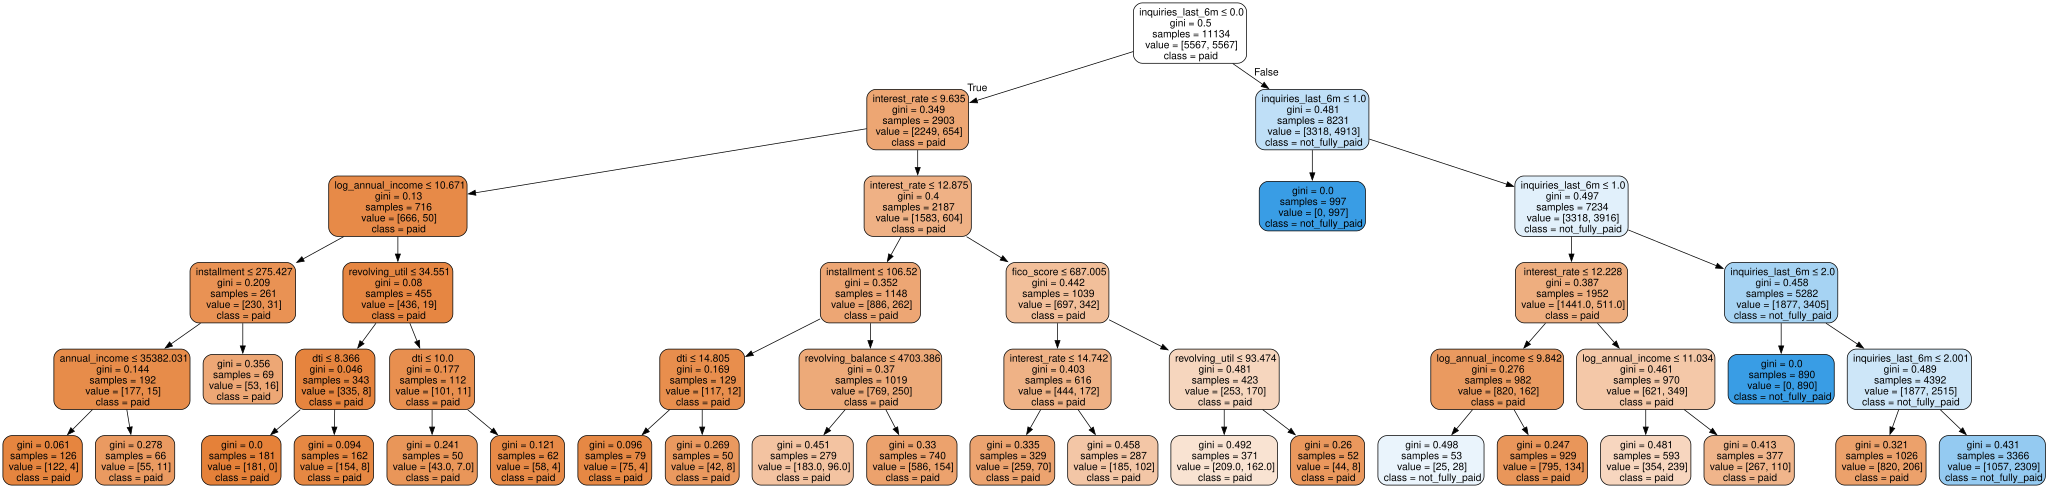

In [128]:
from sklearn.tree import export_graphviz
import graphviz
from IPython.display import display



dot = export_graphviz(
    tree,
    out_file=None,
    feature_names=features,
    class_names=["paid", "not_fully_paid"],
    filled=True,
    rounded=True,
    special_characters=True
)
graph = graphviz.Source(dot)
display(graph)

# Interpretazione
In questo albero vediamo molte foglie con valori Gini che si avvicinano a 0.5
Questo cosa significa ?
Sapendo che Gini è definito come: 
$$\text{Gini} = 1 - \sum_{k=1}^{K} p_k^2$$
Se abbiamo indici che si avvicinano a 0.5, ci troviamo nel caso in cui le due classi hanno entrambe probabilità 0.5:
$$
p_0 = P(\text{not\_fully\_paid} = 0) = 0.5, \quad
p_1 = P(\text{not\_fully\_paid} = 1) = 0.5 \quad

\text{Gini}
= 1 - (0.5^2 + 0.5^2)
= 1 - (0.25 + 0.25)
= 0.5
$$

Ciò dimostra che anche dopo tutti gli split disponibili il modello si trova con nodi in cui paid e not fully paid sono quasi bilanciati, ciò va a confermare i risultati ottenuti precedentementi che mostravano un F1-score basso, che sottolineava la capacità del modello per quanto riguarda il recall, ed il contrario per la precision 

# Random Forest Tree

In [129]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    bootstrap=True, 
    random_state=0,
    max_depth=25,
    min_samples_leaf=50
)

# Usa i dati bilanciati con SMOTE
rf.fit(X_train_tree_smote, y_train_tree_smote)

y_pred_rf = rf.predict(X_test_tree)
y_score_rf = rf.predict_proba(X_test_tree)[:, 1]

print("\n" + "="*70)
print("Random Forest Model Results")
print("="*70)
print(f"Accuracy:  {accuracy_score(y_test_tree, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test_tree, y_pred_rf, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test_tree, y_pred_rf, zero_division=0):.4f}")
print(f"F1-Score:  {f1_score(y_test_tree, y_pred_rf, zero_division=0):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test_tree, y_score_rf):.4f}")
print("\nConfusion matrix:\n", confusion_matrix(y_test_tree, y_pred_rf))


Random Forest Model Results
Accuracy:  0.7437
Precision: 0.2632
Recall:    0.3422
F1-Score:  0.2976
ROC-AUC:   0.6468

Confusion matrix:
 [[1955  431]
 [ 296  154]]


Il modella ha risultati discreti, ma riusciamo a renderlo ancora migliore?

In [102]:
from sklearn.model_selection import GridSearchCV

# Usa il modello base senza class_weight (SMOTE bilancia già i dati)
base_rf = RandomForestClassifier(random_state=0)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, 25, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Usa scoring='f1' per dataset sbilanciati, addestra sui dati SMOTE
grid_search = GridSearchCV(
    base_rf, 
    param_grid=param_grid, 
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train_tree_smote, y_train_tree_smote)

print("Best Parameters:", grid_search.best_params_)
print("Best F1 Score (CV):", grid_search.best_score_)

Best Parameters: {'bootstrap': False, 'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best F1 Score (CV): 0.8794955290657122


In [130]:
rf_best = grid_search.best_estimator_

y_pred_rf_best = rf_best.predict(X_test_tree)
y_score_rf_best = rf_best.predict_proba(X_test_tree)[:, 1]

print("\n" + "="*70)
print("Random Forest (Best GridSearch Params + SMOTE) Results")
print("="*70)
print(f"Accuracy:  {accuracy_score(y_test_tree, y_pred_rf_best):.4f}")
print(f"Precision: {precision_score(y_test_tree, y_pred_rf_best, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test_tree, y_pred_rf_best, zero_division=0):.4f}")
print(f"F1-Score:  {f1_score(y_test_tree, y_pred_rf_best, zero_division=0):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test_tree, y_score_rf_best):.4f}")
print("\nConfusion matrix:\n", confusion_matrix(y_test_tree, y_pred_rf_best))


Random Forest (Best GridSearch Params + SMOTE) Results
Accuracy:  0.8121
Precision: 0.2893
Recall:    0.1267
F1-Score:  0.1762
ROC-AUC:   0.6326

Confusion matrix:
 [[2246  140]
 [ 393   57]]


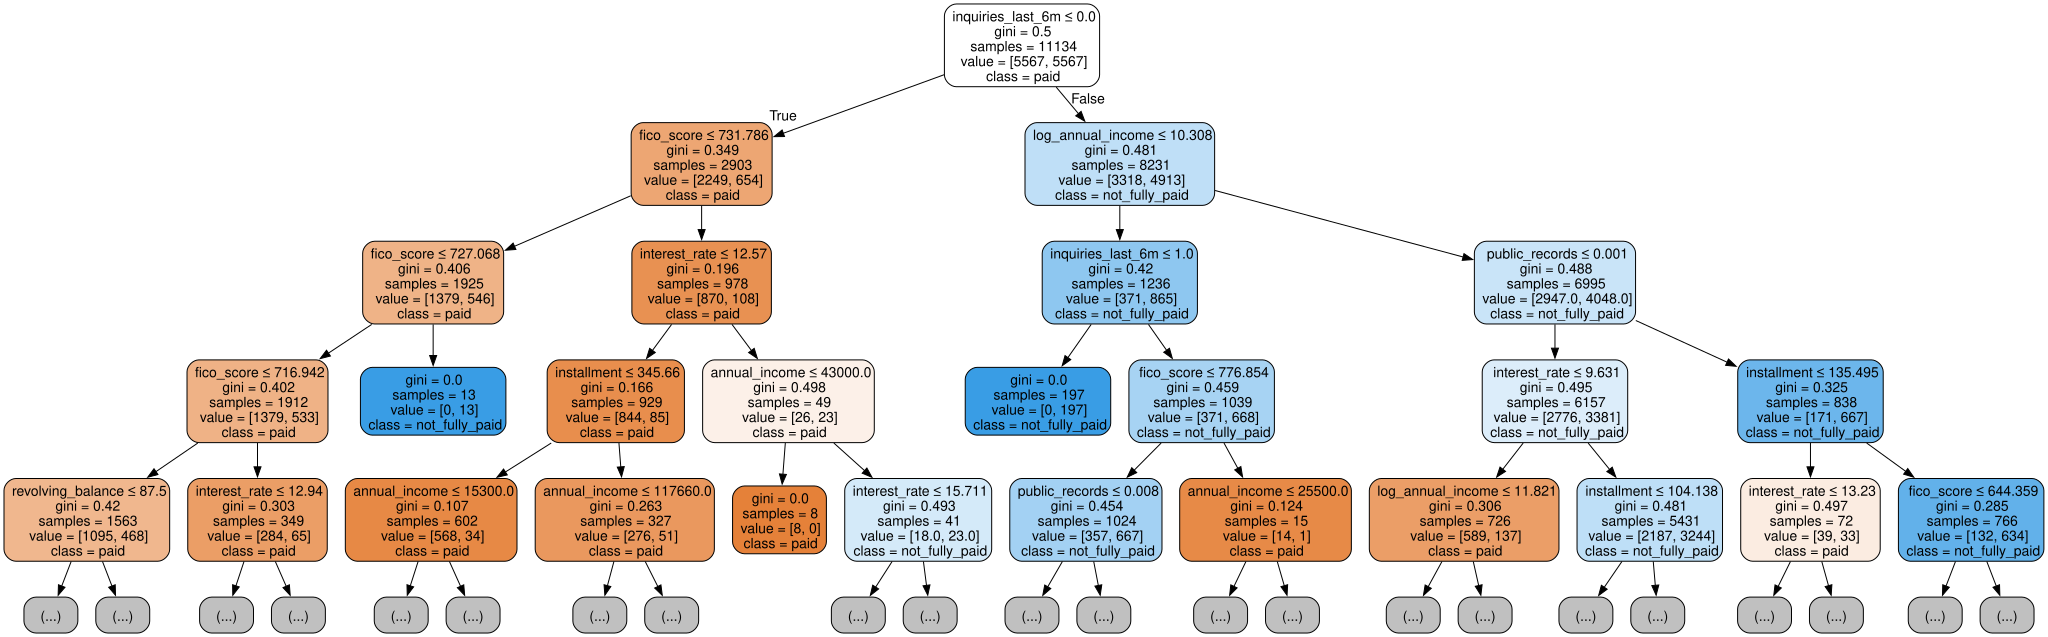

In [131]:
from sklearn.tree import export_graphviz
import graphviz

# Extract one tree from the Random Forest (use different variable name to avoid overwriting 'tree')
rf_tree = rf_best.estimators_[0]

# Export the tree to graphviz DOT format
dot_data = export_graphviz(
    rf_tree,
    out_file=None,
    feature_names=features,
    class_names=["paid", "not_fully_paid"],
    filled=True,
    rounded=True,
    special_characters=True,
    max_depth=4  # Limit depth for readability
)

# Create and display the graph
graph = graphviz.Source(dot_data)
display(graph)

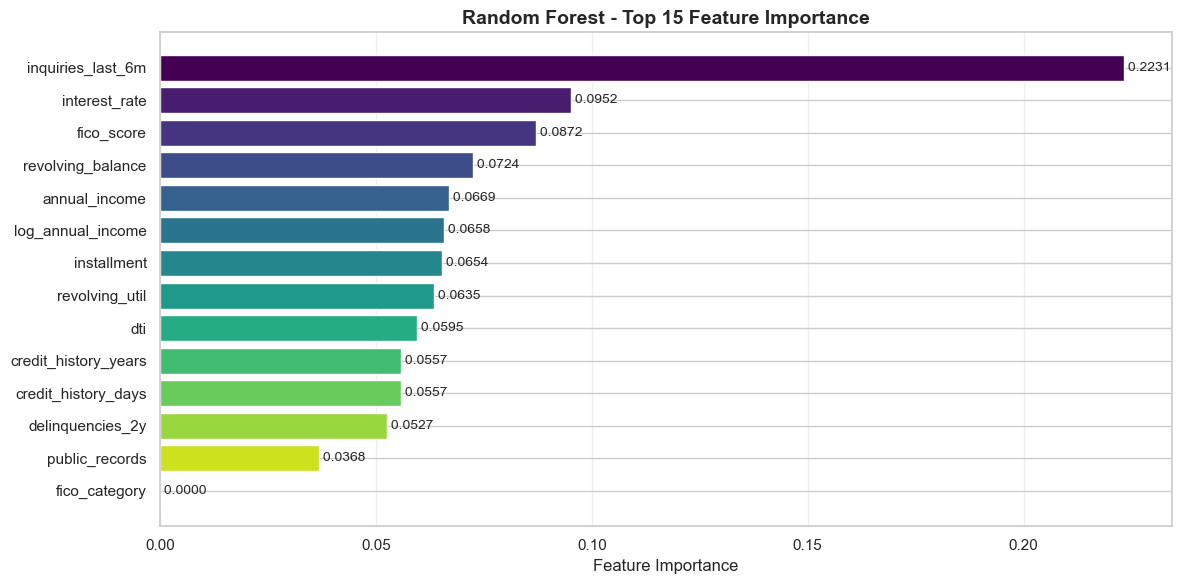


Top 15 Features by Importance:
 1. inquiries_last_6m         -> 0.223145
 2. interest_rate             -> 0.095199
 3. fico_score                -> 0.087172
 4. revolving_balance         -> 0.072434
 5. annual_income             -> 0.066904
 6. log_annual_income         -> 0.065784
 7. installment               -> 0.065420
 8. revolving_util            -> 0.063493
 9. dti                       -> 0.059483
10. credit_history_years      -> 0.055728
11. credit_history_days       -> 0.055725
12. delinquencies_2y          -> 0.052687
13. public_records            -> 0.036826
14. fico_category             -> 0.000000


In [132]:
fig, ax = plt.subplots(figsize=(12, 6))

feature_importance = rf_best.feature_importances_
indices = np.argsort(feature_importance)[::-1][:15]  # Top 15 

colors_importance = plt.cm.viridis(np.linspace(0, 1, len(indices)))
bars = ax.barh(range(len(indices)), feature_importance[indices], color=colors_importance)

ax.set_yticks(range(len(indices)))
ax.set_yticklabels([features[i] for i in indices])
ax.set_xlabel('Feature Importance', fontsize=12)
ax.set_title('Random Forest - Top 15 Feature Importance', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(alpha=0.3, axis='x')

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, feature_importance[indices])):
    ax.text(val, i, f' {val:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\nTop 15 Features by Importance:")
for rank, idx in enumerate(indices, 1):
    print(f"{rank:2d}. {features[idx]:25s} -> {feature_importance[idx]:.6f}")

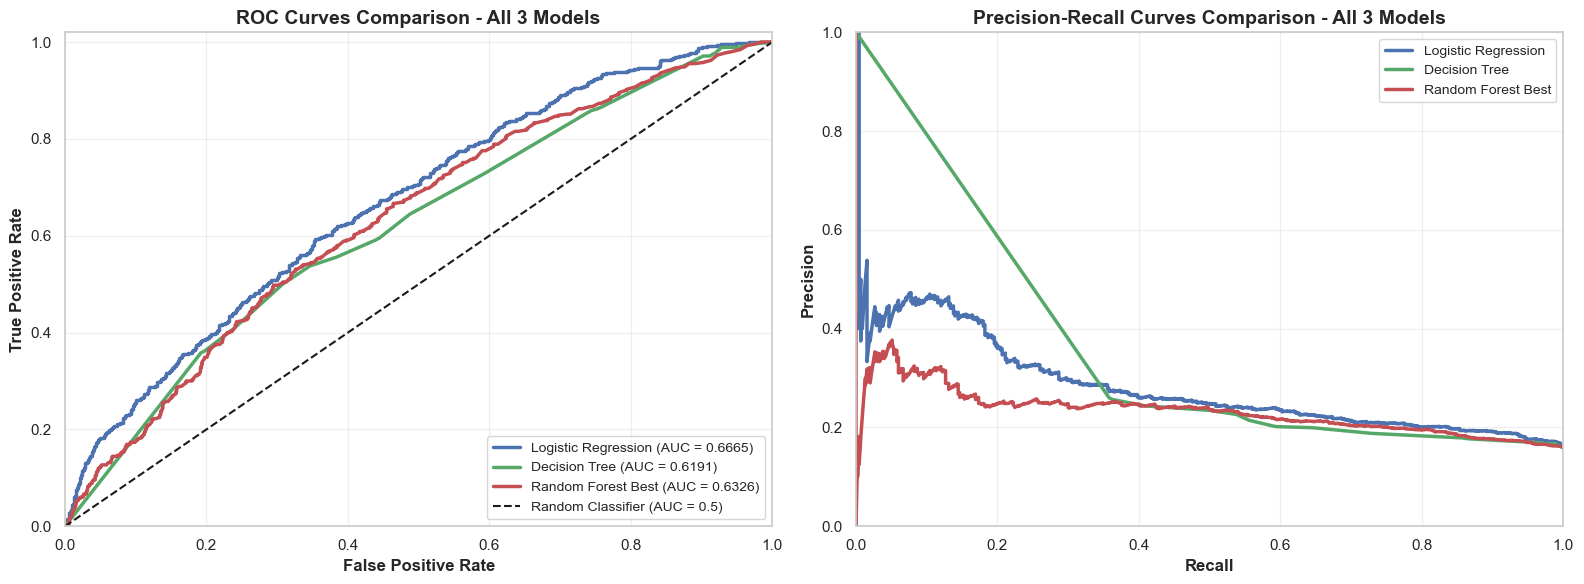


AUC Scores:
  Logistic Regression: 0.6665
  Decision Tree:       0.6191
  Random Forest:       0.6326


In [135]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import warnings
warnings.filterwarnings('ignore')

# USE THE ORIGINAL MODELS TRAINED EARLIER FOR FAIR COMPARISON
# Logistic Regression: clf (trained in cell 174 on X_train_smote with StandardScaler)
# Decision Tree: tree (trained in cell 181 on X_train_tree_smote)
# Random Forest Best: rf_best (trained via GridSearch)

# For Logistic Regression - use the original clf model and original test data
# Note: clf was trained on X_train_smote (scaled), so we need X_test (scaled)
y_pred_lr = clf.predict(X_test)
y_score_lr = clf.predict_proba(X_test)[:, 1]

# For Decision Tree - use the original tree model 
y_pred_dt = tree.predict(X_test_tree)
y_score_dt = tree.predict_proba(X_test_tree)[:, 1]

# For Random Forest Best - already have y_pred_rf_best and y_score_rf_best

# Confronto ROC Curves per i tre modelli
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Calcola ROC Curves per ciascun modello
# Logistic Regression (uses y_test from the LR split)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_score_lr)
auc_lr = auc(fpr_lr, tpr_lr)

# Decision Tree (uses y_test_tree from the tree split)
fpr_dt, tpr_dt, _ = roc_curve(y_test_tree, y_score_dt)
auc_dt = auc(fpr_dt, tpr_dt)

# Random Forest Best (uses y_test_tree from the tree split)
fpr_rf, tpr_rf, _ = roc_curve(y_test_tree, y_score_rf_best)
auc_rf = auc(fpr_rf, tpr_rf)

# Plot ROC Curves
axes[0].plot(fpr_lr, tpr_lr, 'b-', lw=2.5, label=f'Logistic Regression (AUC = {auc_lr:.4f})')
axes[0].plot(fpr_dt, tpr_dt, 'g-', lw=2.5, label=f'Decision Tree (AUC = {auc_dt:.4f})')
axes[0].plot(fpr_rf, tpr_rf, 'r-', lw=2.5, label=f'Random Forest Best (AUC = {auc_rf:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier (AUC = 0.5)')
axes[0].set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
axes[0].set_title('ROC Curves Comparison - All 3 Models', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(alpha=0.3)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.02])

# Precision-Recall Curves
pr_lr, rec_lr, _ = precision_recall_curve(y_test, y_score_lr)
pr_dt, rec_dt, _ = precision_recall_curve(y_test_tree, y_score_dt)
pr_rf, rec_rf, _ = precision_recall_curve(y_test_tree, y_score_rf_best)

axes[1].plot(rec_lr, pr_lr, 'b-', lw=2.5, label=f'Logistic Regression')
axes[1].plot(rec_dt, pr_dt, 'g-', lw=2.5, label=f'Decision Tree')
axes[1].plot(rec_rf, pr_rf, 'r-', lw=2.5, label=f'Random Forest Best')
axes[1].set_xlabel('Recall', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Precision', fontsize=12, fontweight='bold')
axes[1].set_title('Precision-Recall Curves Comparison - All 3 Models', fontsize=14, fontweight='bold')
axes[1].legend(loc='upper right', fontsize=10)
axes[1].grid(alpha=0.3)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

print(f"\nAUC Scores:")
print(f"  Logistic Regression: {auc_lr:.4f}")
print(f"  Decision Tree:       {auc_dt:.4f}")
print(f"  Random Forest:       {auc_rf:.4f}")

CONFRONTO METRICHE - TUTTI I 3 MODELLI
Metrica         Logistic Reg.      Decision Tree      Random Forest     
----------------------------------------------------------------------
Accuracy        0.5977             0.7324             0.8121            
Precision       0.2260             0.2567             0.2893            
Recall          0.6333             0.3622             0.1267            
F1-Score        0.3331             0.3005             0.1762            
ROC-AUC         0.6665             0.6191             0.6326            


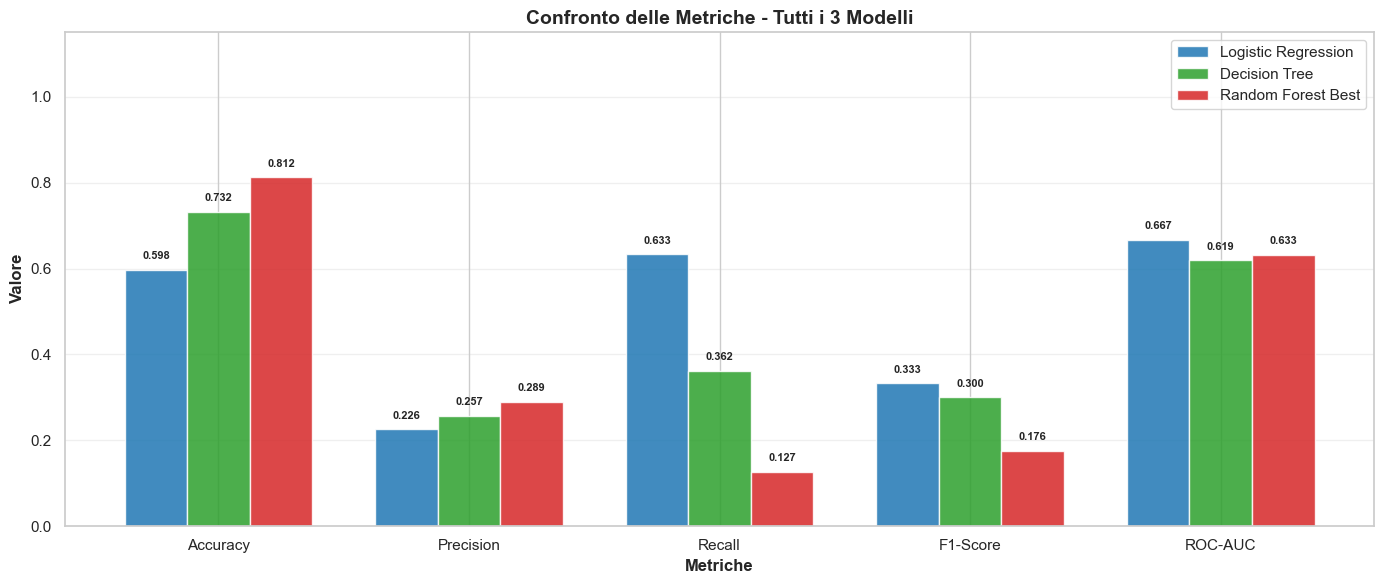

In [136]:
# Grafico a barre per confronto metriche tra i 3 modelli
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

metriche_da_confrontare = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

# Calcola metriche per Logistic Regression (using original clf model and y_test)
lr_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr, zero_division=0),
    'Recall': recall_score(y_test, y_pred_lr, zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_lr, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, y_score_lr)
}

# Calcola metriche per Decision Tree (using original tree model and y_test_tree)
dt_metrics = {
    'Accuracy': accuracy_score(y_test_tree, y_pred_dt),
    'Precision': precision_score(y_test_tree, y_pred_dt, zero_division=0),
    'Recall': recall_score(y_test_tree, y_pred_dt, zero_division=0),
    'F1-Score': f1_score(y_test_tree, y_pred_dt, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test_tree, y_score_dt)
}

# Calcola metriche per Random Forest Best (using rf_best and y_test_tree)
rf_best_metrics = {
    'Accuracy': accuracy_score(y_test_tree, y_pred_rf_best),
    'Precision': precision_score(y_test_tree, y_pred_rf_best, zero_division=0),
    'Recall': recall_score(y_test_tree, y_pred_rf_best, zero_division=0),
    'F1-Score': f1_score(y_test_tree, y_pred_rf_best, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test_tree, y_score_rf_best)
}

modelli = ['Logistic Regression', 'Decision Tree', 'Random Forest Best']
risultati_finali = {
    'Logistic Regression': lr_metrics,
    'Decision Tree': dt_metrics,
    'Random Forest Best': rf_best_metrics
}

# Print metrics table
print("=" * 70)
print("CONFRONTO METRICHE - TUTTI I 3 MODELLI")
print("=" * 70)
print(f"{'Metrica':<15} {'Logistic Reg.':<18} {'Decision Tree':<18} {'Random Forest':<18}")
print("-" * 70)
for m in metriche_da_confrontare:
    print(f"{m:<15} {lr_metrics[m]:<18.4f} {dt_metrics[m]:<18.4f} {rf_best_metrics[m]:<18.4f}")
print("=" * 70)

x = np.arange(len(metriche_da_confrontare))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))

colors = ['#1f77b4', '#2ca02c', '#d62728']

for i, modello in enumerate(modelli):
    valori = [risultati_finali[modello][m] for m in metriche_da_confrontare]
    offset = (i - 1) * width
    bars = ax.bar(x + offset, valori, width, label=modello, alpha=0.85, color=colors[i])
    
    # Aggiungi etichette sopra le barre
    for bar, val in zip(bars, valori):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel('Metriche', fontsize=12, fontweight='bold')
ax.set_ylabel('Valore', fontsize=12, fontweight='bold')
ax.set_title('Confronto delle Metriche - Tutti i 3 Modelli', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metriche_da_confrontare)
ax.legend(loc='upper right', fontsize=11)
ax.grid(alpha=0.3, axis='y')
ax.set_ylim([0, 1.15])

plt.tight_layout()
plt.show()